In [1]:
# ==============================================================================
# SHORTAGE AI V2.0 - HYBRID PREDICTION SYSTEM (GBM + DEEP LEARNING ATTENTION)
# ==============================================================================
# Author: Capstone Team
# Date: January 14, 2026 (Simulation)
# Version: 2.0.0
# Description:
#   Environment bootstrap for a hybrid drug shortage prediction system.
#   This section should only do:
#   1) imports
#   2) dependency flags
#   3) global config
#   4) logging + reproducibility setup
# ==============================================================================

# ------------------------------------------------------------------------------
# SECTION 0: LIBRARY IMPORTS AND DEPENDENCY MANAGEMENT
# ------------------------------------------------------------------------------

# 0.1 Standard Library
import os
import sys
import io
import re
import json
import time
import uuid
import zipfile
import shutil
import random
import logging
import warnings
from pathlib import Path
from datetime import datetime, timedelta
from typing import List, Dict, Tuple, Optional, Union, Any
from collections import Counter
from urllib.parse import quote_plus
from tqdm.auto import tqdm as tqdm_bar

# 0.2 Data / Networking
import pandas as pd
import numpy as np
import requests
import urllib3
from urllib3.util.retry import Retry

# 0.3 ML Core (with availability guards where useful)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    xgb = None
    XGBOOST_AVAILABLE = False

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    lgb = None
    LIGHTGBM_AVAILABLE = False

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    auc,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
from sklearn.inspection import permutation_importance

import optuna
from optuna.samplers import TPESampler

try:
    from catboost import CatBoostClassifier, Pool
    CATBOOST_AVAILABLE = True
except ImportError:
    CatBoostClassifier = None
    Pool = None
    CATBOOST_AVAILABLE = False

# Backward compatibility alias (if old sections still use CATBOOST_ACTIVE)
CATBOOST_ACTIVE = CATBOOST_AVAILABLE

# 0.4 Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# 0.5 Visualization / Explainability
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    shap = None
    SHAP_AVAILABLE = False

# 0.6 External Data Connectors
try:
    from selenium import webdriver
    from selenium.webdriver.common.by import By
    from selenium.webdriver.chrome.options import Options
    from selenium.webdriver.support.ui import WebDriverWait
    from selenium.webdriver.support import expected_conditions as EC
    SELENIUM_AVAILABLE = True
except ImportError:
    webdriver = None
    By = None
    Options = None
    WebDriverWait = None
    EC = None
    SELENIUM_AVAILABLE = False

try:
    from pytrends.request import TrendReq
    from pytrends.exceptions import TooManyRequestsError
    PYTRENDS_AVAILABLE = True
except ImportError:
    TrendReq = None
    TooManyRequestsError = Exception
    PYTRENDS_AVAILABLE = False

# 0.7 Database
from sqlalchemy import create_engine, text


# ==============================================================================
# SECTION 0: SYSTEM CONFIGURATION & ARCHITECTURE
# ==============================================================================

class Config:
    """
    Centralized configuration management for ShortageAI v2.0.
    """

    # Paths
    BASE_DIR = Path.cwd().resolve()                 # project root
    DATA_DIR = BASE_DIR / "Internal data"          # internal dataset folder
    OUTPUT_DIR = BASE_DIR / "Output_v2"            # output artifacts folder
    LOG_DIR = OUTPUT_DIR / "logs"                  # log files folder

    # Reproducibility
    SEED = 42                                       # global random seed

    # Feature/business windows
    WINDOWS = {
        "sales_history": 12,                        # sales lag window (weeks)
        "supply_gap": 4,                            # supply gap window (weeks)
        "rcv_trend": 8,                             # receiving trend window (weeks)
        "po_horizon": 4,                            # purchase order horizon (weeks)
        "forecast_horizon": 4                       # forecast horizon (weeks)
    }

    # Deep Learning params
    DL_PARAMS = {
        "batch_size": 32,                           # batch size for DL
        "learning_rate": 0.001,                     # learning rate for DL optimizer
        "epochs": 20,                               # number of epochs
        "hidden_dim": 64,                           # model hidden dimension
        "dropout": 0.2,                             # dropout rate
        "attention_heads": 1                        # attention heads
    }

    # ML params
    ML_PARAMS = {
        "rf_estimators": 200,                       # random forest trees
        "xgb_learning_rate": 0.05,                  # xgboost learning rate
        "cv_folds": 5                               # cross-validation folds
    }

    # Section 2 runtime
    SECTION2_PARAMS = {
        "year_filter": 2023,                        # only use this year in train_P2
        "p2_last_n_weeks": 26,                      # last N weeks inside year_filter
        "p2_start_yearweek": None,                  # explicit start YYYYWW (override)
        "p2_end_yearweek": None,                    # explicit end YYYYWW (override)

        "p2_chunksize": 300_000,                    # CSV chunk size for train_P2
        "p2_progress_every": 1,                     # progress print interval (chunks)
        "p2_max_chunks": None,                      # limit chunks for debug
        "p2_reduce_every": 10,                      # reduce partial panels every N chunks

        "weekly_sales_chunksize": 300_000,          # CSV chunk size for weekly sales
        "weekly_sales_reduce_every": 10             # reduce weekly sales every N chunks
    }
    # Section 3 / Product attributes
    PRODUCT_ATTRIBUTE_CONFIG = {
        "refrigerated_codes": ["R"],
        "injectable_codes": ["I"],
        "controlled_drug_codes": ["CON1", "CON2", "CON3", "CON4"],
        "controlled_drug_levels": {"CON1": 1, "CON2": 2, "CON3": 3, "CON4": 4},
        "special_handling_codes": ["C"],
        "transferable_codes": ["T"],
        "not_transferable_codes": ["P"],
    
        # Tracked Format
        "tracked_forms": ["TABLET", "CAPSULE", "SOLUTION", "LIQUID", "POWDER", "CREAM"],
    
        # Auto track format
        "auto_form_min_share": 0.05,   # threshold for percentage（>=5%）
        "auto_form_min_count": 20,    # mini sample size
        "auto_form_use_train_scope": True,  # Only use the item show up in train_P2 for percentage count
    }

    # External data params
    EXTERNAL_PARAMS = {
        "cpi_zip_url": "https://www150.statcan.gc.ca/n1/tbl/csv/18100004-eng.zip",  # CPI zip URL
        "cpi_uom": "2002=100",                       # CPI unit of measure
        "cpi_rx_label": "Prescribed medicines (excluding medicinal cannabis)",     # CPI RX label
        "cpi_otc_label": "Non-prescribed medicines",                               # CPI OTC label
        "cpi_weekly_file": "CPI_DRUG_WEEKLY.csv"     # output weekly CPI file
    }

    # API reliability
    API_RETRIES = 5                                 # retry times for APIs
    API_BACKOFF = 0.5                               # backoff (seconds)

    @classmethod
    def setup_environment(cls, reset_logging: bool = True) -> logging.Logger:
        """
        Initialize directories, logging, random seeds, and runtime defaults.
        """
        cls.DATA_DIR.mkdir(parents=True, exist_ok=True)
        cls.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        cls.LOG_DIR.mkdir(parents=True, exist_ok=True)

        # avoid duplicated handlers on notebook re-run
        root_logger = logging.getLogger()
        if reset_logging and root_logger.handlers:
            for h in list(root_logger.handlers):
                root_logger.removeHandler(h)

        log_file = cls.LOG_DIR / f"run_{datetime.now():%Y%m%d_%H%M%S}.log"
        logging.basicConfig(
            level=logging.INFO,
            format="%(asctime)s - [%(levelname)s] - %(message)s",
            handlers=[
                logging.FileHandler(log_file),
                logging.StreamHandler(sys.stdout)
            ]
        )
        logger = logging.getLogger(__name__)

        # seeds
        os.environ["PYTHONHASHSEED"] = str(cls.SEED)
        random.seed(cls.SEED)
        np.random.seed(cls.SEED)
        torch.manual_seed(cls.SEED)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(cls.SEED)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
            device_name = "GPU (CUDA)"
        else:
            device_name = "CPU"

        # display
        pd.set_option("display.max_columns", None)
        pd.set_option("display.width", 1200)
        pd.set_option("display.float_format", "{:.4f}".format)
        warnings.filterwarnings("ignore")

        logger.info("=" * 70)
        logger.info("SHORTAGE AI V2.0 - ENVIRONMENT INITIALIZED")
        logger.info("=" * 70)
        logger.info(f"System Time      : {datetime.now()}")
        logger.info(f"Base Directory   : {cls.BASE_DIR}")
        logger.info(f"Data Directory   : {cls.DATA_DIR}")
        logger.info(f"Output Directory : {cls.OUTPUT_DIR}")
        logger.info(f"Torch Version    : {torch.__version__}")
        logger.info(f"Compute Device   : {device_name}")
        logger.info(f"XGBoost          : {'Available' if XGBOOST_AVAILABLE else 'Not Installed'}")
        logger.info(f"LightGBM         : {'Available' if LIGHTGBM_AVAILABLE else 'Not Installed'}")
        logger.info(f"CatBoost         : {'Available' if CATBOOST_AVAILABLE else 'Not Installed'}")
        logger.info(f"SHAP             : {'Available' if SHAP_AVAILABLE else 'Not Installed'}")
        logger.info(f"Selenium         : {'Available' if SELENIUM_AVAILABLE else 'Not Installed'}")
        logger.info(f"PyTrends         : {'Available' if PYTRENDS_AVAILABLE else 'Not Installed'}")
        logger.info("-" * 70)

        return logger


# ==============================================================================
# EXECUTION ENTRY POINT (Initialization)
# ==============================================================================
logger = Config.setup_environment()

2026-02-19 22:07:27,440 - [INFO] - ======================================================================
2026-02-19 22:07:27,442 - [INFO] - SHORTAGE AI V2.0 - ENVIRONMENT INITIALIZED
2026-02-19 22:07:27,443 - [INFO] - ======================================================================
2026-02-19 22:07:27,444 - [INFO] - System Time      : 2026-02-19 22:07:27.444608
2026-02-19 22:07:27,445 - [INFO] - Base Directory   : /Users/yuyangchen
2026-02-19 22:07:27,447 - [INFO] - Data Directory   : /Users/yuyangchen/Internal data
2026-02-19 22:07:27,448 - [INFO] - Output Directory : /Users/yuyangchen/Output_v2
2026-02-19 22:07:27,449 - [INFO] - Torch Version    : 2.10.0
2026-02-19 22:07:27,449 - [INFO] - Compute Device   : CPU
2026-02-19 22:07:27,450 - [INFO] - XGBoost          : Available
2026-02-19 22:07:27,453 - [INFO] - LightGBM         : Available
2026-02-19 22:07:27,458 - [INFO] - CatBoost         : Available
2026-02-19 22:07:27,463 - [INFO] - SHAP             : Available
2026-02-19 22:

In [2]:
# ==============================================================================
# SECTION 1: EXTERNAL DATA ACQUISITION & INGESTION
# ==============================================================================
#
# PURPOSE:
#   Download and cache external data sources needed for drug shortage prediction.
#
# DATA SOURCES:
#   1. Health Canada Drug Product Database (DPD): product / ingredient / therapeutic mappings
#   2. Google Trends: ATC-level consumer search sentiment proxy
#   3. Statistics Canada CPI: RX / OTC / Pharma macro pricing signals
#   4. WHO FluNet (Canada): respiratory virus activity signals
#
# STRATEGY:
#   - DPD:
#       * Force refresh every run
#       * Selenium-driven browser download of official ZIP extracts
#   - Google Trends:
#       * First run      -> full 5-year historical pull
#       * Subsequent run -> incremental refresh from last_date+1 to today
#   - CPI:
#       * Download official CSV ZIP
#       * Extract RX/OTC + Pharma fallback series
#       * Convert monthly series to weekly lag features
#   - FluNet:
#       * Pull Canada-only records from WHO OData endpoint
#       * Build lagged weekly epidemiological features
#
# OUTPUT ARTIFACTS (written to Config.DATA_DIR):
#   - DPD txt files: drug*.txt, ingred*.txt, ther*.txt, status*.txt, comp*.txt
#   - ATC_COMPOSITE_TRENDS.csv (+ partial checkpoint file)
#   - CPI_DRUG_WEEKLY.csv
#   - FLUNET_CANADA_WEEKLY.csv
#
# ==============================================================================

logger = logging.getLogger(__name__)

print("\n" + "=" * 80)
print("SECTION 1: EXTERNAL DATA ACQUISITION")
print("=" * 80)


# ==============================================================================
# PART 1/4: HEALTH CANADA DPD DOWNLOAD
# ==============================================================================
print("\nPart 1/4: Health Canada Drug Product Database")
print("-" * 80)

DPD_PAGE_URL = "https://www.canada.ca/en/health-canada/services/drugs-health-products/drug-products/drug-product-database/what-data-extract-drug-product-database.html"

ZIP_TARGETS = {
    "allfiles.zip": ["drug.txt", "ingred.txt", "ther.txt", "status.txt", "comp.txt"],
    "allfiles_ia.zip": ["drug_ia.txt", "ingred_ia.txt", "ther_ia.txt", "comp_ia.txt", "status_ia.txt"],
}


def _wait_for_download(download_dir: Path, filename: str, timeout_s: int = 300) -> Path:
    """
    Wait until a browser download is fully completed.

    Notes:
    - Chrome writes *.crdownload while transfer is still in progress.
    - We additionally require file size to be stable for >= 2 cycles to avoid partial reads.
    """
    target = download_dir / filename
    temp_part = download_dir / (filename + ".crdownload")

    start = time.time()
    last_size = -1
    stable_count = 0

    while time.time() - start < timeout_s:
        if temp_part.exists():
            time.sleep(1)
            continue

        if target.exists():
            size = target.stat().st_size
            if size == last_size and size > 0:
                stable_count += 1
            else:
                stable_count = 0
                last_size = size

            if stable_count >= 2:
                return target

        time.sleep(1)

    raise TimeoutError(f"Download timeout for {filename}")


def _atomic_extract(zf: zipfile.ZipFile, member: str, out_path: Path) -> None:
    """
    Extract one file atomically to avoid corrupt partial output when interrupted.
    """
    out_path.parent.mkdir(parents=True, exist_ok=True)
    tmp = out_path.with_name(f".{out_path.name}.tmp")
    with zf.open(member) as src, open(tmp, "wb") as dst:
        shutil.copyfileobj(src, dst)
    tmp.replace(out_path)


def download_canada_dpd_selenium() -> None:
    """
    Download DPD ZIPs via Selenium and extract required text files.

    Behavior:
    - Always force download (no cache shortcut).
    - Writes all required files into Config.DATA_DIR.
    """
    logger.info("[DPD] Starting Health Canada DPD download...")
    print("Strategy: Download from Health Canada page via Selenium")
    print("Mode: Force download (ignore cache)\n")

    data_dir = Config.DATA_DIR
    data_dir.mkdir(parents=True, exist_ok=True)

    dl_dir = data_dir / "_dpd_downloads"
    if dl_dir.exists():
        shutil.rmtree(dl_dir, ignore_errors=True)
    dl_dir.mkdir(parents=True, exist_ok=True)

    chrome_opts = Options()
    chrome_opts.add_argument("--headless=new")
    chrome_opts.add_argument("--no-sandbox")
    chrome_opts.add_argument("--disable-dev-shm-usage")
    chrome_opts.add_argument("--window-size=1400,900")
    chrome_opts.add_experimental_option(
        "prefs",
        {
            "download.default_directory": str(dl_dir.resolve()),
            "download.prompt_for_download": False,
            "download.directory_upgrade": True,
            "safebrowsing.enabled": True,
        },
    )

    driver = webdriver.Chrome(options=chrome_opts)

    try:
        driver.get(DPD_PAGE_URL)
        WebDriverWait(driver, 20).until(
            EC.presence_of_all_elements_located((By.CSS_SELECTOR, "a[href]"))
        )

        links = [a.get_attribute("href") for a in driver.find_elements(By.CSS_SELECTOR, "a[href]")]

        def find_link(zip_name: str) -> str:
            for href in links:
                if href and href.lower().endswith(zip_name.lower()):
                    return href
            raise RuntimeError(f"{zip_name} link not found on DPD page")

        zip_links = {
            "allfiles.zip": find_link("allfiles.zip"),
            "allfiles_ia.zip": find_link("allfiles_ia.zip"),
        }

        for zip_name, zip_url in zip_links.items():
            print(f"\nDownloading: {zip_name}")
            logger.info(f"[DPD] Processing {zip_name}")

            driver.get(zip_url)
            zip_path = _wait_for_download(dl_dir, zip_name)
            size_mb = zip_path.stat().st_size / 1024 / 1024
            print(f"  ✓ Download successful ({size_mb:.1f} MB)")

            print("  Extracting files...")
            with zipfile.ZipFile(zip_path) as zf:
                names = zf.namelist()
                names_lower = [n.lower() for n in names]

                extracted = []
                for target_file in ZIP_TARGETS[zip_name]:
                    idx = next((i for i, n in enumerate(names_lower) if n.endswith(target_file.lower())), None)
                    if idx is None:
                        continue

                    _atomic_extract(zf, names[idx], data_dir / target_file)
                    out_mb = (data_dir / target_file).stat().st_size / 1024 / 1024
                    print(f"    ✓ {target_file} ({out_mb:.1f} MB)")
                    extracted.append(target_file)

                missing_in_zip = [f for f in ZIP_TARGETS[zip_name] if f not in extracted]
                if missing_in_zip:
                    logger.warning(f"[DPD] Missing expected members in {zip_name}: {missing_in_zip}")

    finally:
        driver.quit()

    expected_all = [f for files in ZIP_TARGETS.values() for f in files]
    missing_all = [f for f in expected_all if not (Config.DATA_DIR / f).exists()]

    if missing_all:
        print(f"\n⚠️ DPD missing files after extraction: {missing_all}")
        logger.warning(f"[DPD] Missing extracted files: {missing_all}")
    else:
        print("\n✓ DPD extraction complete (all expected files present)")


download_canada_dpd_selenium()


# ==============================================================================
# PART 2/4: GOOGLE TRENDS ACQUISITION
# ==============================================================================
print("\n" + "=" * 80)
print("Part 2/4: Google Trends Market Sentiment")
print("-" * 80)


def fetch_google_trends() -> None:
    """
    Build ATC-level Google Trends composite index.

    Update policy:
    - If output does not exist => full 5-year pull.
    - If output exists        => incremental pull from (max_date + 1 day) to today.

    Output:
    - ATC_COMPOSITE_TRENDS.csv
      columns: date, COMPOSITE_INDEX, ATC_LEVEL1, YEAR_WEEK
    """
    output_file = Config.DATA_DIR / "ATC_COMPOSITE_TRENDS.csv"
    now = pd.Timestamp.utcnow().tz_localize(None).normalize()

    existing = None
    full_refresh = True
    last_date = None

    if output_file.exists():
        try:
            existing = pd.read_csv(output_file)
            existing["date"] = pd.to_datetime(existing["date"], utc=True).dt.tz_localize(None)
            last_date = existing["date"].max()
            if pd.notna(last_date):
                full_refresh = False
        except Exception as e:
            print(f"⚠️ Existing trends file read failed: {str(e)[:100]}")
            existing = None
            full_refresh = True

    if full_refresh:
        timeframe = "today 5-y"
        mode = "FULL (5y)"
    else:
        start_date = (last_date + pd.Timedelta(days=1)).date()
        end_date = now.date()

        if start_date > end_date:
            print("✓ Trends already up-to-date. No refresh needed.")
            return

        timeframe = f"{start_date} {end_date}"
        mode = "INCREMENTAL"

    print(f"Trends mode: {mode}")
    if not full_refresh:
        print(f"Last date in file: {last_date.date()}")
        print(f"Incremental window: {start_date} to {end_date}")
    print(f"Output file: {output_file.name}")

    atc_keywords = {
        "A": ["Stomach pain", "Ozempic", "Antacid", "Digestive health"],
        "B": ["Blood thinner", "Eliquis", "Xarelto", "Warfarin"],
        "C": ["Blood pressure", "Hypertension", "Beta blocker", "Amlodipine"],
        "D": ["Eczema", "Skin rash", "Cortisone", "Hydrocortisone"],
        "G": ["Birth control", "Plan B", "Menopause", "Hormone replacement"],
        "H": ["Levothyroxine", "Synthroid", "Prednisone", "Steroid"],
        "J": ["Antibiotics", "Amoxicillin", "Azithromycin", "Penicillin"],
        "L": ["Chemotherapy", "Cancer treatment", "Immunotherapy", "Oncology"],
        "M": ["Arthritis", "Back pain", "Muscle pain", "Anti inflammatory"],
        "N": ["Tylenol", "Advil", "Ibuprofen", "Painkiller"],
        "P": ["Lice treatment", "Head lice", "Permethrin", "Worm medicine"],
        "R": ["Flu", "Cold medicine", "Cough", "Inhaler"],
        "S": ["Eye drops", "Pink eye", "Dry eyes", "Ear drops"],
        "V": ["First aid", "Bandage", "Medical supplies", "Syringe"],
    }

    pytrends = TrendReq(hl="en-CA", tz=-300, timeout=(10, 25), retries=0)

    rows = []
    success_count = 0
    fail_count = 0

    def cooldown(attempt: int) -> None:
        base = 90
        wait = min(600, base * (2 ** (attempt - 1)))
        wait += random.uniform(0, 30)
        print(f"  -> Cooling down for {int(wait)}s...")
        time.sleep(wait)

    for i, (atc, kws) in enumerate(atc_keywords.items(), 1):
        attempt = 0
        while attempt < 5:
            attempt += 1
            try:
                # Gentle pacing to reduce 429 risk
                time.sleep(random.uniform(12, 20))

                print(f"[{i}/{len(atc_keywords)}] ATC-{atc} (Attempt {attempt}/5)...", end=" ")
                pytrends.build_payload(kws, timeframe=timeframe, geo="CA")
                df = pytrends.interest_over_time()

                if df.empty:
                    print("✗ Empty")
                    fail_count += 1
                    break

                df = df.drop(columns=["isPartial"], errors="ignore")

                # Remove flat/no-signal keyword columns before z-score aggregation
                valid_cols = [c for c in df.columns if df[c].std() > 1e-6 and df[c].sum() > 0]
                if not valid_cols:
                    print("✗ No-signal")
                    fail_count += 1
                    break

                x = df[valid_cols].astype(float)
                z = (x - x.mean()) / x.std()
                comp = z.mean(axis=1)

                tmp = comp.reset_index()
                tmp.columns = ["date", "COMPOSITE_INDEX"]
                tmp["ATC_LEVEL1"] = atc
                tmp["YEAR_WEEK"] = tmp["date"].dt.strftime("%G%V").astype(int)
                rows.append(tmp)

                print(f"✓ rows={len(tmp):,}")
                success_count += 1
                break

            except TooManyRequestsError:
                print("✗ 429")
                cooldown(attempt)

            except Exception as e:
                print(f"✗ Error: {str(e)[:100]}")
                fail_count += 1
                break

        # Write partial checkpoint after each successful ATC block
        if rows:
            partial = pd.concat(rows, ignore_index=True)
            partial["date"] = pd.to_datetime(partial["date"], utc=True).dt.tz_localize(None)
            partial = partial.sort_values(["ATC_LEVEL1", "YEAR_WEEK"])
            partial.to_csv(output_file.with_name("ATC_COMPOSITE_TRENDS.partial.csv"), index=False)

    if not rows and (existing is None or existing.empty):
        print("\n✗ No data fetched from Google Trends")
        return

    final = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
        columns=["date", "COMPOSITE_INDEX", "ATC_LEVEL1", "YEAR_WEEK"]
    )

    if not final.empty:
        final["date"] = pd.to_datetime(final["date"], utc=True).dt.tz_localize(None)

    if existing is not None and not existing.empty and not full_refresh:
        existing["ATC_LEVEL1"] = existing["ATC_LEVEL1"].astype(str).str.upper().str.strip()
        final["ATC_LEVEL1"] = final["ATC_LEVEL1"].astype(str).str.upper().str.strip()

        combined = pd.concat([existing, final], ignore_index=True)
        combined = combined.drop_duplicates(subset=["ATC_LEVEL1", "YEAR_WEEK"], keep="last")
        combined = combined.sort_values(["ATC_LEVEL1", "YEAR_WEEK"])
        out = combined
    else:
        out = final.sort_values(["ATC_LEVEL1", "YEAR_WEEK"])

    out.to_csv(output_file, index=False)

    print("\n✓ Google Trends acquisition complete")
    if not out.empty:
        print(f"  Output rows: {len(out):,}")
        print(f"  Date range: {out['date'].min().date()} to {out['date'].max().date()}")
        print(f"  ATC classes: {out['ATC_LEVEL1'].nunique()}")
    else:
        print("  Output rows: 0")
        print("  Date range: N/A")
        print("  ATC classes: 0")
    print(f"  Success ATCs: {success_count}, Failed ATCs: {fail_count}")


fetch_google_trends()


# ==============================================================================
# PART 3/4: CPI (RX / OTC / PHARMA) ACQUISITION
# ==============================================================================
print("\n" + "=" * 80)
print("Part 3/4: CPI - RX / OTC / Pharma")
print("-" * 80)


def fetch_cpi_rx_otc_pharma() -> None:
    """
    Download CPI zip and create weekly lagged CPI features.

    Output:
    - CPI_DRUG_WEEKLY.csv
      columns:
        date_monday,
        CPI_RX_lag1, CPI_OTC_lag1, CPI_PHARMA_lag1,
        CPI_RX_mom_lag1, CPI_OTC_mom_lag1, CPI_PHARMA_mom_lag1
    """
    cpi_url = "https://www150.statcan.gc.ca/n1/tbl/csv/18100004-eng.zip"
    out_weekly = Config.DATA_DIR / "CPI_DRUG_WEEKLY.csv"

    zip_path = Config.DATA_DIR / "18100004-eng.zip"
    if not zip_path.exists():
        print(f"Downloading CPI ZIP: {cpi_url}")
        r = requests.get(cpi_url, timeout=60)
        r.raise_for_status()
        zip_path.write_bytes(r.content)

    with zipfile.ZipFile(zip_path) as zf:
        csv_name = [n for n in zf.namelist() if n.endswith(".csv")][0]
        df = pd.read_csv(zf.open(csv_name), low_memory=False)

    df = df[["REF_DATE", "GEO", "Products and product groups", "UOM", "VALUE"]].copy()
    df = df[df["GEO"].str.contains("Canada", case=False, na=False)]
    df = df[df["UOM"].astype(str).str.contains("2002=100", na=False)]

    rx_name = "Prescribed medicines (excluding medicinal cannabis)"
    otc_name = "Non-prescribed medicines"
    pharma_name = "Medicinal and pharmaceutical products"

    rx = df[df["Products and product groups"] == rx_name][["REF_DATE", "VALUE"]].rename(columns={"VALUE": "CPI_RX"})
    otc = df[df["Products and product groups"] == otc_name][["REF_DATE", "VALUE"]].rename(columns={"VALUE": "CPI_OTC"})
    ph = df[df["Products and product groups"] == pharma_name][["REF_DATE", "VALUE"]].rename(columns={"VALUE": "CPI_PHARMA"})

    rx["date_month"] = pd.to_datetime(rx["REF_DATE"], errors="coerce")
    otc["date_month"] = pd.to_datetime(otc["REF_DATE"], errors="coerce")
    ph["date_month"] = pd.to_datetime(ph["REF_DATE"], errors="coerce")

    m = rx.merge(otc, on="date_month", how="outer").merge(ph, on="date_month", how="outer")
    m = m.sort_values("date_month")

    m["CPI_RX_mom"] = m["CPI_RX"].pct_change()
    m["CPI_OTC_mom"] = m["CPI_OTC"].pct_change()
    m["CPI_PHARMA_mom"] = m["CPI_PHARMA"].pct_change()

    m["CPI_RX_lag1"] = m["CPI_RX"].shift(1)
    m["CPI_OTC_lag1"] = m["CPI_OTC"].shift(1)
    m["CPI_PHARMA_lag1"] = m["CPI_PHARMA"].shift(1)

    m["CPI_RX_mom_lag1"] = m["CPI_RX_mom"].shift(1)
    m["CPI_OTC_mom_lag1"] = m["CPI_OTC_mom"].shift(1)
    m["CPI_PHARMA_mom_lag1"] = m["CPI_PHARMA_mom"].shift(1)

    rows = []
    for _, r in m.iterrows():
        if pd.isna(r["date_month"]):
            continue

        month_start = pd.Timestamp(r["date_month"]).normalize()
        month_end = (month_start + pd.offsets.MonthEnd(1)).normalize()
        mondays = pd.date_range(month_start, month_end, freq="W-MON")
        if len(mondays) == 0:
            continue

        rows.append(
            pd.DataFrame(
                {
                    "date_monday": mondays,
                    "CPI_RX_lag1": r["CPI_RX_lag1"],
                    "CPI_OTC_lag1": r["CPI_OTC_lag1"],
                    "CPI_PHARMA_lag1": r["CPI_PHARMA_lag1"],
                    "CPI_RX_mom_lag1": r["CPI_RX_mom_lag1"],
                    "CPI_OTC_mom_lag1": r["CPI_OTC_mom_lag1"],
                    "CPI_PHARMA_mom_lag1": r["CPI_PHARMA_mom_lag1"],
                }
            )
        )

    weekly = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
        columns=[
            "date_monday",
            "CPI_RX_lag1", "CPI_OTC_lag1", "CPI_PHARMA_lag1",
            "CPI_RX_mom_lag1", "CPI_OTC_mom_lag1", "CPI_PHARMA_mom_lag1",
        ]
    )

    weekly.to_csv(out_weekly, index=False)
    print(f"✓ CPI weekly saved: {out_weekly.name}")
    if not weekly.empty:
        print(f"  Date range: {weekly['date_monday'].min().date()} to {weekly['date_monday'].max().date()}")
    else:
        print("  Date range: N/A (empty output)")


fetch_cpi_rx_otc_pharma()


# ==============================================================================
# PART 4/4: WHO FLUNET (CANADA) - WEEKLY VIRUS SIGNALS
# ==============================================================================
print("\n" + "=" * 80)
print("Part 4/4: WHO FluNet (Canada) - Weekly Virus Signals")
print("-" * 80)


def fetch_flunet_canada_weekly() -> None:
    """
    Download WHO FluNet data (Canada only) and build lagged weekly virus features.

    Output:
    - FLUNET_CANADA_WEEKLY.csv
      columns:
        date_monday,
        FLU_INF_ALL_POS_lag1,
        FLU_INF_A_SHARE_lag1,
        FLU_INF_B_SHARE_lag1,
        FLU_RSV_POS_lag1,
        FLU_OTHER_RESP_POS_lag1
    """
    output_file = Config.DATA_DIR / "FLUNET_CANADA_WEEKLY.csv"

    # WHO FluNet OData endpoint
    url = "https://xmart-api-public.who.int/FLUMART/VIW_FNT"
    params = {"$format": "csv", "$filter": "ISO2 eq 'CA'"}

    print("Downloading FluNet Canada data...")
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()

    df = pd.read_csv(io.StringIO(r.text), low_memory=False)
    print(f"  Raw rows: {len(df):,}")

    # Coerce all relevant count columns to numeric
    num_cols = [
        "SPEC_PROCESSED_NB", "SPEC_RECEIVED_NB", "INF_ALL", "INF_A", "INF_B", "RSV",
        "RSV_PROCESSED", "HUMAN_CORONA", "RHINO", "PARAINFLUENZA", "METAPNEUMO", "ADENO", "BOCA"
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

    # Parse ISO_WEEKSTARTDATE into model key date (Monday)
    df["date_monday"] = pd.to_datetime(df["ISO_WEEKSTARTDATE"], errors="coerce")
    df = df.dropna(subset=["date_monday"]).sort_values("date_monday")

    def safe_div(num, den):
        # Numerically safe ratio; outputs 0.0 when denominator <= 0
        return np.where((den is not None) & (den > 0), num / den, 0.0)

    # Core weekly signals
    df["FLU_INF_ALL_POS"] = safe_div(df.get("INF_ALL", 0), df.get("SPEC_PROCESSED_NB", 0))
    df["FLU_INF_A_SHARE"] = safe_div(df.get("INF_A", 0), df.get("INF_ALL", 0))
    df["FLU_INF_B_SHARE"] = safe_div(df.get("INF_B", 0), df.get("INF_ALL", 0))
    df["FLU_RSV_POS"] = safe_div(df.get("RSV", 0), df.get("RSV_PROCESSED", 0))

    # Bundle "other respiratory viruses" into one signal
    other_cols = [c for c in ["HUMAN_CORONA", "RHINO", "PARAINFLUENZA", "METAPNEUMO", "ADENO", "BOCA"] if c in df.columns]
    if other_cols:
        df["FLU_OTHER_RESP_SUM"] = df[other_cols].sum(axis=1, skipna=True)
        df["FLU_OTHER_RESP_POS"] = safe_div(df["FLU_OTHER_RESP_SUM"], df.get("SPEC_PROCESSED_NB", 0))
    else:
        df["FLU_OTHER_RESP_POS"] = 0.0

    # Lag-1 to avoid look-ahead leakage in downstream modeling
    for col in ["FLU_INF_ALL_POS", "FLU_INF_A_SHARE", "FLU_INF_B_SHARE", "FLU_RSV_POS", "FLU_OTHER_RESP_POS"]:
        df[f"{col}_lag1"] = df[col].shift(1)

    out = df[
        [
            "date_monday",
            "FLU_INF_ALL_POS_lag1",
            "FLU_INF_A_SHARE_lag1",
            "FLU_INF_B_SHARE_lag1",
            "FLU_RSV_POS_lag1",
            "FLU_OTHER_RESP_POS_lag1",
        ]
    ].copy()

    out = out.fillna(0.0)

    out.to_csv(output_file, index=False)
    print(f"  ✓ Saved: {output_file.name}")
    if not out.empty:
        print(f"  Date range: {out['date_monday'].min().date()} -> {out['date_monday'].max().date()}")
    else:
        print("  Date range: N/A (empty output)")


fetch_flunet_canada_weekly()

print("\n" + "=" * 80)
print("SECTION 1 COMPLETE")
print("=" * 80)


SECTION 1: EXTERNAL DATA ACQUISITION

Part 1/4: Health Canada Drug Product Database
--------------------------------------------------------------------------------
2026-02-19 22:07:27,631 - [INFO] - [DPD] Starting Health Canada DPD download...
Strategy: Download from Health Canada page via Selenium
Mode: Force download (ignore cache)


Downloading: allfiles.zip
2026-02-19 22:08:01,384 - [INFO] - [DPD] Processing allfiles.zip
  ✓ Download successful (1.4 MB)
  Extracting files...
    ✓ drug.txt (1.5 MB)
    ✓ ingred.txt (2.3 MB)
    ✓ ther.txt (0.5 MB)
    ✓ status.txt (2.7 MB)
    ✓ comp.txt (2.1 MB)

Downloading: allfiles_ia.zip
2026-02-19 22:08:09,023 - [INFO] - [DPD] Processing allfiles_ia.zip
  ✓ Download successful (5.1 MB)
  Extracting files...
    ✓ drug_ia.txt (4.5 MB)
    ✓ ingred_ia.txt (11.0 MB)
    ✓ ther_ia.txt (1.5 MB)
    ✓ comp_ia.txt (6.2 MB)
    ✓ status_ia.txt (7.3 MB)

✓ DPD extraction complete (all expected files present)

Part 2/4: Google Trends Market Sentiment

In [3]:
# ==============================================================================
# SECTION 2: DATA LOADING & HIERARCHICAL PRE-PROCESSING
# ==============================================================================
"""
Enterprise Drug Shortage Prediction System
Section 2: Internal Data Loading & Master Data Preparation

PRIMARY KEYS
  - Panel key: ITEM_NUM_CLEAN + date_monday
  - Master keys: ITEM_NUM_CLEAN, DIN_KEY

LOADED DATA
  - activeitems.csv
  - train_P2_inbound_allitems_3years.csv
  - promitto_purchase_orders (2).csv
  - promitto_receptions (2).csv
  - network lead times.csv
  - promitto active dcs.csv
  - ATC_COMPOSITE_TRENDS.csv
  - CPI_DRUG_WEEKLY.csv
  - FLUNET_CANADA_WEEKLY.csv
  - DPD files: drug.txt / drug_ia.txt, ther.txt / ther_ia.txt, ingred.txt / ingred_ia.txt

SUMMARY
  - Build item scope with molecule/ATC enrichment and hard quality gate
  - Build item-week panels from train_P2 and weekly_sales
  - Build vendor concentration maps
  - Compute common date range across internal + external sources

RULES
  - FINAL_MOLECULE priority:
      train_P2 unique main name -> activeitems MOLECULE_NM -> DPD molecule -> parsed molecule -> UNKNOWN
  - DIN priority:
      train_P2 ITEM->DIN map -> activeitems ITEM->DIN map -> drop if missing
  - Drop rows with invalid DIN_KEY or UNKNOWN FINAL_MOLECULE
  - Time window controlled by SECTION2_PARAMS (year_filter, p2_start_yearweek, p2_end_yearweek, p2_last_n_weeks)
  - Item-week aggregation: sums for quantity-like fields, means for ratio/duration fields
"""

logger = logging.getLogger(__name__)

# ------------------------------------------------------------------------------
# NLP availability
# ------------------------------------------------------------------------------
try:
    _ = TfidfVectorizer
    _ = cosine_similarity
    NLP_AVAILABLE = True
except Exception:
    NLP_AVAILABLE = False
    logger.warning("NLP utilities unavailable. TF-IDF matching disabled.")


# ==============================================================================
# COLUMN SPECIFICATIONS
# ==============================================================================
class ColumnSpec:
    """Centralized column specs for memory-safe CSV loading."""
    ACTIVE_ITEMS = [
        "DIN_NUM", "ITEM_NUM", "VENDOR_NUM", "MOLECULE_NM",
        "ITEM_EN_DESC", "SHORT_EN_DESC",
        "REFRG_IND", "DATED_ITEM_IND", "INJECTABLE_ITM_CD",
        "CNTRL_DRUG_CD", "SPEC_HNDL_CD", "BO_TRSF_CD",
        "EN_FORM", "THRP_CL_CD",
        "ITEM_CL_GRP_EN_SHORT_DESC"
    ]

    PURCHASE_ORDERS = [
        "PO_DT", "ITEM_NUM", "PO_NUM", "VENDOR_NUM", "DC_CD",
        "PO_QTY_ORD", "PO_QTY_RCV"
    ]

    RECEPTIONS = [
        "RCV_DT", "DC_CD", "RCV_NUM", "ITEM_NUM", "VENDOR_NUM", "PO_NUM", "RCV_QTY"
    ]

    LEAD_TIMES = [
        "DC", "U_Supplier_Number", "LoadTime", "TransLeadTime", "UnloadTime"
    ]

    WEEKLY_SALES = [
        "CAL_INVC_DT", "WEEK_ENDING_DT", "DC_CD", "VENDOR_NUM",
        "ITEM_NUM", "QTY_ORD", "QTY_DELV", "QTY_MCS", "QTY_MCK"
    ]

    TRAIN_P2_BASE = [
        "ITEM_NUM", "MOLECULE_NM_LOWER", "VENDOR_NUM", "DIN_NUM", "THRP_CL_CD",
        "YEAR_WEEK",
        "QTY_ORD", "SALES_DC_COUNT", "SALES_DATES_COUNT", "QTY_DELV", "QTY_MCS", "QTY_MCK",
        "QTY_NOT_DELV", "QTY_ISSUE_OTHER",
        "PO_QTY_ORD_sum", "PO_DT_nunique", "DC_CD_nunique", "PO_NUM_nunique",
        "RCV_NUM_nunique", "RCV_DT_ADJUSTED_nunique", "RCV_QTY_ADJUSTED_sum",
        "VENDOR_SHIP_DUE_DT_nunique",
        "VENDOR_SHIP_DUE_DT_minus_EXP_DUE_DT_FROM_LEAD_TIME",
        "DIF_RCV_DATE_ORD_DATE_MINUS_LEADTIME",
        "DIF_PO_ORD_DATE_VENDOR_SHIP_DUE_DATE",
        "DIF_RCV_DATE_VENDOR_SHIP_DUE_DATE",
        "DIF_RCV_DATE_ORD_DATE",
        "WEEKS_SINCE_LAST_RECEIVE_EXP",
        "SHORT_QTY_WEEKLY", "SHORT_2WEEKBUFFER_PERC", "SHORT_2WEEKBUFFER_BINARY",
        "QTY_DELV_DIVIDEDBY_QTY_ORD", "QTY_MCS_DIVIDEDBY_QTY_ORD", "QTY_MCK_DIVIDEDBY_QTY_ORD",
        "QTY_NOT_DELV_DIVIDEDBY_QTY_ORD", "QTY_ISSUE_OTHER_DIVIDEDBY_QTY_ORD",
        "RCV_QTY_ADJUSTED_sum_DIVIDEDBY_PO_QTY_ORD_sum",
        "SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum",
        "DIF_PO_ORD_DATE_VENDOR_SHIP_DUE_DATE_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE",
        "DIF_RCV_DATE_VENDOR_SHIP_DUE_DATE_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE",
        "VENDOR_SHIP_DUE_DT_minus_EXP_DUE_DT_FROM_LEAD_TIME_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE_MINUS_LEADTIME",
        "RCV_QTY_ADJUSTED_sum_DIVIDEDBY_QTY_ORD",
        "PO_QTY_ORD_sum_DIVIDEDBY_QTY_ORD",
        "QTY_MCS_DIVIDEDBY_QTY_NOT_DELV",
        "SHORT_2WEEKBUFFER_PERC_CLASS",
        "SHORT_2WEEKBUFFER_PERC_CLASS_in6_weeks",
        "SHORT_2WEEKBUFFER_BINARY_in6_weeks",
        "OMIT_BINARY_in6_weeks"
    ]


# ==============================================================================
# TEXT NORMALIZATION
# ==============================================================================
class TextNormalizer:
    """Utilities for parsing product descriptions into molecule-like tokens."""
    NOISE_WORDS = {
        "BAG", "VIAL", "KIT", "BOX", "BTL", "UNT", "IU", "PCT", "MEQ", "VOL",
        "ML", "MG", "G", "L", "MCG", "KG",
        "TAB", "CAP", "SOL", "SOLUTION", "INJ", "INJECTION", "CREAM", "OINTMENT",
        "SUSP", "SYRUP", "ELIXIR", "SUPP", "PATCH", "AEROSOL", "DROPS",
        "USP", "STERILE", "PRESERVATIVE-FREE", "CONCENTRATE", "IRRIGATION",
        "APO", "TEVA", "PMS", "SDZ", "MYLAN", "SANDOZ", "JAMP", "MINT", "RIVA", "MAR",
        "PHS", "REX", "OPTION", "ATOMA", "EQUATE", "TRULY", "MEME", "NOV",
        "DPLY", "XST", "CLD", "BLST", "STRP", "MGUD", "ASTD", "RRX", "DS", "RG", "SP"
    }

    ABBREVIATIONS = {
        "SOD": "SODIUM", "CHLOR": "CHLORIDE", "CALC": "CALCIUM",
        "POT": "POTASSIUM", "MAG": "MAGNESIUM", "DEXT": "DEXTROSE",
        "BICARB": "BICARBONATE", "ACET": "ACETAMINOPHEN", "IBUP": "IBUPROFEN",
        "SALB": "SALBUTAMOL", "VIT": "VITAMIN", "MULTI": "MULTIVITAMIN",
        "ISOP": "ISOPROPYL", "PEROX": "PEROXIDE", "ALC": "ALCOHOL",
        "DIPHEN": "DIPHENHYDRAMINE", "VACC": "VACCINE"
    }

    BRAND_MAP = {
        "TYLENOL": "ACETAMINOPHEN", "ADVIL": "IBUPROFEN", "MOTRIN": "IBUPROFEN",
        "VOLTAREN": "DICLOFENAC", "ASPIRIN": "ACETYLSALICYLIC ACID",
        "ANACIN": "ACETYLSALICYLIC ACID|CAFFEINE",
        "PAXLOVID": "NIRMATRELVIR|RITONAVIR"
    }

    SUPPLY_KEYWORDS = {
        "SYR", "SYRINGE", "NEEDLE", "LANCET", "STRIP", "TEST",
        "METER", "MONITOR", "WIPE", "SWAB", "GAUZE", "BANDAGE",
        "DEVICE", "SPACER", "AEROCHAMBER"
    }

    @staticmethod
    def parse(description: str) -> Tuple[Optional[str], Optional[str]]:
        if not isinstance(description, str) or not description:
            return np.nan, None

        desc = description.upper()

        for kw in TextNormalizer.SUPPLY_KEYWORDS:
            if kw in desc:
                return "SUPPLY", "V"

        for brand, generic in TextNormalizer.BRAND_MAP.items():
            if brand in desc:
                return generic, None

        desc = re.sub(r"\s(W/|WITH)\s", "|", desc)
        desc = re.sub(r"[+/&]", "|", desc)

        raw_tokens = desc.split("|")
        clean_tokens = []

        for token in raw_tokens:
            token = token.strip()
            if not token:
                continue

            words = []
            parts = token.split()
            i = 0
            while i < len(parts):
                w = parts[i].strip()

                if w in TextNormalizer.ABBREVIATIONS:
                    w = TextNormalizer.ABBREVIATIONS[w]

                if i + 1 < len(parts) and parts[i + 1].strip() == "%":
                    num = w.replace(".", "", 1)
                    if num.isdigit():
                        w = f"{w}%"
                        i += 2
                    else:
                        i += 1
                else:
                    i += 1

                if w in TextNormalizer.NOISE_WORDS:
                    continue
                if w.replace(".", "", 1).isdigit():
                    continue

                words.append(w)

            if words:
                clean_tokens.append(" ".join(words))

        if not clean_tokens:
            return np.nan, None

        return "|".join(sorted(set(clean_tokens))), None


# ==============================================================================
# SMART MATCHER
# ==============================================================================
class SmartMatcher:
    """TF-IDF matcher for fallback molecule normalization."""
    def __init__(self, known_molecules: List[str], similarity_threshold: float = 0.55):
        self.threshold = similarity_threshold
        self.known_molecules = [m for m in known_molecules if isinstance(m, str) and len(m) > 0]
        self.vectorizer = None
        self.molecule_vectors = None

        if NLP_AVAILABLE and self.known_molecules:
            self.vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
            self.molecule_vectors = self.vectorizer.fit_transform(self.known_molecules)

    def match_batch(self, series: pd.Series, batch_size: int = 5000) -> pd.Series:
        if self.vectorizer is None or series is None or len(series) == 0:
            return pd.Series([np.nan] * (0 if series is None else len(series)),
                             index=None if series is None else series.index)

        results = []
        n_batches = (len(series) + batch_size - 1) // batch_size

        for i in range(n_batches):
            s = i * batch_size
            e = min((i + 1) * batch_size, len(series))
            batch = series.iloc[s:e]
            X = self.vectorizer.transform(batch.fillna("").astype(str))
            sim = cosine_similarity(X, self.molecule_vectors)

            out = []
            for row in sim:
                idx = int(row.argmax())
                out.append(self.known_molecules[idx] if row[idx] >= self.threshold else np.nan)
            results.extend(out)

            if (i + 1) % 5 == 0 or (i + 1) == n_batches:
                logger.info(f"    TF-IDF progress: {e:,}/{len(series):,} ({e/len(series)*100:.1f}%)")

        return pd.Series(results, index=series.index)


# ==============================================================================
# MAIN DATA PREPROCESSOR
# ==============================================================================
class DataPreProcessor:
    """Main ETL pipeline orchestrator."""
    def __init__(self):
        self.data_dir = Config.DATA_DIR
        self.params = dict(Config.SECTION2_PARAMS)

        self._param_adjustments = []
        p2_cs = int(self.params.get("p2_chunksize", 300_000))
        ws_cs = int(self.params.get("weekly_sales_chunksize", 300_000))

        if p2_cs > 300_000:
            self._param_adjustments.append(f"p2_chunksize capped {p2_cs} -> 300000")
            p2_cs = 300_000
        if ws_cs > 300_000:
            self._param_adjustments.append(f"weekly_sales_chunksize capped {ws_cs} -> 300000")
            ws_cs = 300_000

        self.params["p2_chunksize"] = p2_cs
        self.params["weekly_sales_chunksize"] = ws_cs

        self._window = self._resolve_yearweek_window()

    # --------------------------------------------------------------------------
    # Basic normalization helpers
    # --------------------------------------------------------------------------
    @staticmethod
    def normalize_din(series: pd.Series, width: int = 8) -> pd.Series:
        x = pd.to_numeric(series, errors="coerce").astype("Int64")
        return x.astype("string").str.zfill(width)

    @staticmethod
    def normalize_item_num(series: pd.Series) -> pd.Series:
        return pd.to_numeric(
            series.astype(str).str.replace(r"^I", "", regex=True).str.strip(),
            errors="coerce"
        ).astype("Int64")

    @staticmethod
    def normalize_molecule(series: pd.Series) -> pd.Series:
        s = series.astype("string").str.strip().str.upper()
        s = s.replace({"": pd.NA, "NAN": pd.NA, "<NA>": pd.NA, "NONE": pd.NA})
        return s

    @staticmethod
    def yearweek_to_monday(year_week: pd.Series) -> pd.Series:
        yw = pd.to_numeric(year_week, errors="coerce").astype("Int64")
        year = (yw // 100).astype("Int64")
        week = (yw % 100).astype("Int64")

        def _iso_monday(y, w):
            if pd.isna(y) or pd.isna(w):
                return pd.NaT
            try:
                return datetime.fromisocalendar(int(y), int(w), 1).date()
            except Exception:
                return pd.NaT

        return pd.to_datetime([_iso_monday(y, w) for y, w in zip(year, week)])

    @staticmethod
    def yearweek_to_monday_scalar(yearweek: Optional[int]) -> pd.Timestamp:
        if yearweek is None:
            return pd.NaT
        try:
            y = int(yearweek) // 100
            w = int(yearweek) % 100
            return pd.to_datetime(datetime.fromisocalendar(int(y), int(w), 1).date())
        except Exception:
            return pd.NaT

    @staticmethod
    def to_monday(dt: pd.Series) -> pd.Series:
        dt = pd.to_datetime(dt, errors="coerce")
        return dt - pd.to_timedelta(dt.dt.weekday, unit="D")

    @staticmethod
    def iso_last_week_of_year(year: int) -> int:
        return datetime(year, 12, 28).isocalendar().week

    @staticmethod
    def safe_usecols(path: Path, desired_cols: List[str]) -> List[str]:
        try:
            cols = pd.read_csv(path, nrows=0).columns.tolist()
            return [c for c in desired_cols if c in cols]
        except Exception:
            return desired_cols

    @staticmethod
    def mode_or_nan(s: pd.Series):
        s = s.dropna()
        if len(s) == 0:
            return np.nan
        m = s.mode()
        return m.iloc[0] if len(m) > 0 else s.iloc[0]

    @staticmethod
    def collapse_molecule_string(mol_str: str) -> str:
        if not isinstance(mol_str, str) or mol_str.strip() == "":
            return pd.NA
        tokens = [t.strip() for t in mol_str.split("|") if t.strip()]
        if len(tokens) <= 1:
            return tokens[0] if tokens else pd.NA
        joined = " ".join(tokens).upper()
        if any(x in joined for x in ["VITAMIN", "BIOTIN", "FOLIC", "FOLATE"]):
            if any(x in joined for x in ["IRON", "CALCIUM", "ZINC", "MAGNESIUM", "MINERAL"]):
                return "MULTIVIT_MINERALS"
            return "MULTIVITAMIN"
        if any(x in joined for x in ["SODIUM", "POTASSIUM", "CHLORIDE"]):
            return "ELECTROLYTE_COMBINATION"
        return "COMBINATION_PRODUCT"

    # --------------------------------------------------------------------------
    # Internal: resolve year-week window for train_P2 + weekly_sales
    # --------------------------------------------------------------------------
    def _resolve_yearweek_window(self) -> Dict[str, Any]:
        p = self.params
        year_filter = p.get("year_filter", None)
        start_yw = p.get("p2_start_yearweek", None)
        end_yw = p.get("p2_end_yearweek", None)
        last_n = p.get("p2_last_n_weeks", None)

        years = None
        if year_filter is not None:
            if isinstance(year_filter, (list, tuple, set)):
                years = sorted(set(int(x) for x in year_filter))
            else:
                years = [int(year_filter)]

        if start_yw is not None or end_yw is not None:
            eff_start = start_yw
            eff_end = end_yw
            source = "explicit_yearweek"
        else:
            if last_n is not None and years is not None and len(years) == 1:
                y = years[0]
                last_week = self.iso_last_week_of_year(y)
                eff_end = int(f"{y}{last_week:02d}")
                end_monday = self.yearweek_to_monday_scalar(eff_end)
                start_monday = end_monday - pd.Timedelta(weeks=int(last_n) - 1)
                start_y, start_w, _ = start_monday.isocalendar()
                eff_start = int(f"{start_y}{int(start_w):02d}")
                source = "last_n_weeks"

                p["p2_start_yearweek"] = eff_start
                p["p2_end_yearweek"] = eff_end
            else:
                eff_start, eff_end, source = None, None, "none"

        start_date = self.yearweek_to_monday_scalar(eff_start) if eff_start else pd.NaT
        end_date = self.yearweek_to_monday_scalar(eff_end) if eff_end else pd.NaT

        return {
            "years": years,
            "source": source,
            "start_yw": eff_start,
            "end_yw": eff_end,
            "start_date": start_date,
            "end_date": end_date,
        }

    def _print_effective_params(self):
        p = self.params
        w = self._window

        print("\n" + "=" * 80)
        print("SECTION 2 - EFFECTIVE RUNTIME SETTINGS")
        print("=" * 80)
        print(f"  year_filter:               {p.get('year_filter')}")
        print(f"  p2_last_n_weeks:           {p.get('p2_last_n_weeks')}")
        print(f"  p2_start_yearweek:         {p.get('p2_start_yearweek')}")
        print(f"  p2_end_yearweek:           {p.get('p2_end_yearweek')}")
        print(f"  p2_chunksize:              {p.get('p2_chunksize')}")
        print(f"  p2_reduce_every:           {p.get('p2_reduce_every')}")
        print(f"  weekly_sales_chunksize:    {p.get('weekly_sales_chunksize')}")
        print(f"  weekly_sales_reduce_every: {p.get('weekly_sales_reduce_every')}")

        if self._param_adjustments:
            print(f"  param_adjustments:         {', '.join(self._param_adjustments)}")
        else:
            print("  param_adjustments:         None")

        if w["source"] == "last_n_weeks":
            print("\n  WINDOW SOURCE: last_n_weeks")
        elif w["source"] == "explicit_yearweek":
            print("\n  WINDOW SOURCE: explicit_yearweek")
        else:
            print("\n  WINDOW SOURCE: none")

        print(f"  Effective yearweek window: {w['start_yw']} -> {w['end_yw']}")
        if pd.notna(w["start_date"]) and pd.notna(w["end_date"]):
            print(f"  Effective date window:     {w['start_date'].date()} -> {w['end_date'].date()}")
        else:
            print("  Effective date window:     None")
        print("=" * 80)

    # --------------------------------------------------------------------------
    # Dataset loaders
    # --------------------------------------------------------------------------
    def load_active_items_raw(self) -> pd.DataFrame:
        path = self.data_dir / "activeitems.csv"
        if not path.exists():
            logger.error("activeitems.csv not found")
            return pd.DataFrame()

        usecols = self.safe_usecols(path, ColumnSpec.ACTIVE_ITEMS)
        df = pd.read_csv(path, usecols=usecols, low_memory=False)
        df["ITEM_NUM_CLEAN"] = self.normalize_item_num(df["ITEM_NUM"])
        df["DIN_KEY"] = self.normalize_din(df["DIN_NUM"])
        df["VENDOR_NUM"] = pd.to_numeric(df["VENDOR_NUM"], errors="coerce").astype("Int64")

        if "MOLECULE_NM" in df.columns:
            df["MOLECULE_NM"] = self.normalize_molecule(df["MOLECULE_NM"])

        if "ITEM_CL_GRP_EN_SHORT_DESC" in df.columns:
            df["ITEM_CL_GRP_EN_SHORT_DESC"] = (
                df["ITEM_CL_GRP_EN_SHORT_DESC"].astype("string").str.strip().str.upper()
            )
        return df

    def load_purchase_orders(self) -> pd.DataFrame:
        path = self.data_dir / "promitto_purchase_orders (2).csv"
        if not path.exists():
            logger.warning("Purchase orders file not found")
            return pd.DataFrame()

        usecols = self.safe_usecols(path, ColumnSpec.PURCHASE_ORDERS)
        df = pd.read_csv(path, usecols=usecols, low_memory=False)
        df["PO_DT"] = pd.to_datetime(df["PO_DT"], errors="coerce")
        df["date_monday"] = self.to_monday(df["PO_DT"])
        df["ITEM_NUM_CLEAN"] = self.normalize_item_num(df["ITEM_NUM"])
        df["VENDOR_NUM"] = pd.to_numeric(df["VENDOR_NUM"], errors="coerce").astype("Int64")
        df["PO_QTY_ORD"] = pd.to_numeric(df["PO_QTY_ORD"], errors="coerce").fillna(0)
        df["PO_QTY_RCV"] = pd.to_numeric(df["PO_QTY_RCV"], errors="coerce").fillna(0)
        return df

    def load_receptions(self) -> pd.DataFrame:
        path = self.data_dir / "promitto_receptions (2).csv"
        if not path.exists():
            logger.warning("Receptions file not found")
            return pd.DataFrame()

        usecols = self.safe_usecols(path, ColumnSpec.RECEPTIONS)
        df = pd.read_csv(path, usecols=usecols, low_memory=False)

        if "RCV_DT" in df.columns and "RCV_DT_ADJUSTED" not in df.columns:
            df = df.rename(columns={"RCV_DT": "RCV_DT_ADJUSTED"})
        if "RCV_QTY" in df.columns and "RCV_QTY_ADJUSTED" not in df.columns:
            df = df.rename(columns={"RCV_QTY": "RCV_QTY_ADJUSTED"})

        if "RCV_DT_ADJUSTED" not in df.columns:
            logger.warning("Receptions missing RCV_DT column")
            return pd.DataFrame()

        df["RCV_DT_ADJUSTED"] = pd.to_datetime(df["RCV_DT_ADJUSTED"], errors="coerce")
        df["date_monday"] = self.to_monday(df["RCV_DT_ADJUSTED"])
        df["ITEM_NUM_CLEAN"] = self.normalize_item_num(df["ITEM_NUM"])
        df["VENDOR_NUM"] = pd.to_numeric(df["VENDOR_NUM"], errors="coerce").astype("Int64")
        if "RCV_QTY_ADJUSTED" in df.columns:
            df["RCV_QTY_ADJUSTED"] = pd.to_numeric(df["RCV_QTY_ADJUSTED"], errors="coerce").fillna(0)
        return df

    def load_lead_times(self) -> pd.DataFrame:
        path = self.data_dir / "network lead times.csv"
        if not path.exists():
            logger.warning("Lead times file not found")
            return pd.DataFrame()

        usecols = self.safe_usecols(path, ColumnSpec.LEAD_TIMES)
        df = pd.read_csv(path, usecols=usecols, low_memory=False)
        df["VENDOR_NUM"] = pd.to_numeric(df["U_Supplier_Number"], errors="coerce").astype("Int64")
        df["LoadTime"] = pd.to_numeric(df["LoadTime"], errors="coerce").fillna(0)
        df["TransLeadTime"] = pd.to_numeric(df["TransLeadTime"], errors="coerce").fillna(0)
        df["UnloadTime"] = pd.to_numeric(df["UnloadTime"], errors="coerce").fillna(0)
        df["TotalLeadTime"] = df["LoadTime"] + df["TransLeadTime"] + df["UnloadTime"]
        return df

    def load_dc_info(self) -> pd.DataFrame:
        path = self.data_dir / "promitto active dcs.csv"
        if not path.exists():
            logger.warning("DC info file not found")
            return pd.DataFrame()
        return pd.read_csv(path, low_memory=False)

    def load_trends(self) -> pd.DataFrame:
        path = self.data_dir / "ATC_COMPOSITE_TRENDS.csv"
        if not path.exists():
            logger.warning("Trends file not found")
            return pd.DataFrame()

        df = pd.read_csv(path, low_memory=False)
        if "ATC_LEVEL1" not in df.columns:
            return pd.DataFrame()

        if "YEAR_WEEK" in df.columns:
            df["date_monday"] = self.yearweek_to_monday(df["YEAR_WEEK"])
        elif "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df["date_monday"] = self.to_monday(df["date"])
        else:
            return pd.DataFrame()

        df["ATC_LEVEL1"] = df["ATC_LEVEL1"].astype(str).str.strip().str.upper()
        df["COMPOSITE_INDEX"] = pd.to_numeric(df["COMPOSITE_INDEX"], errors="coerce")
        return df

    def load_cpi_weekly(self) -> pd.DataFrame:
        path = self.data_dir / "CPI_DRUG_WEEKLY.csv"
        if not path.exists():
            logger.warning("CPI weekly file not found")
            return pd.DataFrame()
        df = pd.read_csv(path, low_memory=False)
        if "date_monday" in df.columns:
            df["date_monday"] = pd.to_datetime(df["date_monday"], errors="coerce")
        return df

    def load_flunet_weekly(self) -> pd.DataFrame:
        path = self.data_dir / "FLUNET_CANADA_WEEKLY.csv"
        if not path.exists():
            logger.warning("FluNet weekly file not found")
            return pd.DataFrame()
        df = pd.read_csv(path, low_memory=False)
        if "date_monday" in df.columns:
            df["date_monday"] = pd.to_datetime(df["date_monday"], errors="coerce")
        return df

    # --------------------------------------------------------------------------
    # train_P2 derived maps
    # --------------------------------------------------------------------------
    def build_item_maps_from_train_p2(
        self, chunksize: int = 1_000_000
    ) -> Tuple[Dict[int, int], set, pd.DataFrame]:
        path = self.data_dir / "train_P2_inbound_allitems_3years.csv"
        if not path.exists():
            logger.warning("train_P2 file not found")
            empty = pd.DataFrame(columns=["ITEM_NUM_CLEAN", "MOLECULE_MAIN_NAME", "MAIN_NAME_ITEM_COUNT"])
            return {}, set(), empty

        usecols = self.safe_usecols(path, ["ITEM_NUM", "DIN_NUM", "MOLECULE_NM_LOWER"])
        item_din_map: Dict[int, int] = {}
        conflicts = set()
        main_name_counter_by_item: Dict[int, Counter] = {}

        for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize, low_memory=False):
            item = self.normalize_item_num(chunk["ITEM_NUM"])
            din = pd.to_numeric(chunk["DIN_NUM"], errors="coerce")
            main = self.normalize_molecule(chunk["MOLECULE_NM_LOWER"]) if "MOLECULE_NM_LOWER" in chunk.columns else pd.Series([pd.NA] * len(chunk))

            for it, di, mn in zip(item, din, main):
                if pd.isna(it):
                    continue
                it = int(it)

                if not pd.isna(di):
                    di = int(di)
                    if it not in item_din_map:
                        item_din_map[it] = di
                    elif item_din_map[it] != di:
                        conflicts.add(it)

                if isinstance(mn, str) and mn.strip():
                    if it not in main_name_counter_by_item:
                        main_name_counter_by_item[it] = Counter()
                    main_name_counter_by_item[it][mn] += 1

        for it in conflicts:
            item_din_map.pop(it, None)

        rows = []
        for it, cnt in main_name_counter_by_item.items():
            best_name, best_freq = cnt.most_common(1)[0]
            rows.append({
                "ITEM_NUM_CLEAN": it,
                "MOLECULE_MAIN_NAME": best_name,
                "MAIN_NAME_FREQ": best_freq
            })

        df_item_main = pd.DataFrame(rows)
        if not df_item_main.empty:
            main_item_count = (
                df_item_main.groupby("MOLECULE_MAIN_NAME")["ITEM_NUM_CLEAN"]
                .nunique()
                .reset_index(name="MAIN_NAME_ITEM_COUNT")
            )
            df_item_main = df_item_main.merge(main_item_count, on="MOLECULE_MAIN_NAME", how="left")
        else:
            df_item_main = pd.DataFrame(columns=["ITEM_NUM_CLEAN", "MOLECULE_MAIN_NAME", "MAIN_NAME_ITEM_COUNT"])

        return item_din_map, conflicts, df_item_main

    def build_item_din_map_from_activeitems(self, df_raw: pd.DataFrame) -> Tuple[Dict[int, int], set]:
        item_map, conflicts = {}, set()
        tmp = df_raw[["ITEM_NUM_CLEAN", "DIN_NUM"]].copy()
        tmp["ITEM_NUM_CLEAN"] = pd.to_numeric(tmp["ITEM_NUM_CLEAN"], errors="coerce")
        tmp["DIN_NUM"] = pd.to_numeric(tmp["DIN_NUM"], errors="coerce")
        tmp = tmp.dropna(subset=["ITEM_NUM_CLEAN", "DIN_NUM"])

        for it, di in zip(tmp["ITEM_NUM_CLEAN"], tmp["DIN_NUM"]):
            it, di = int(it), int(di)
            if it not in item_map:
                item_map[it] = di
            elif item_map[it] != di:
                conflicts.add(it)

        for it in conflicts:
            item_map.pop(it, None)

        return item_map, conflicts

    def combine_item_maps(self, item_map_train: Dict[int, int], item_map_active: Dict[int, int]) -> Dict[int, int]:
        combined = dict(item_map_train)
        for k, v in item_map_active.items():
            if k not in combined:
                combined[k] = v
        return combined

    # --------------------------------------------------------------------------
    # DPD enrichment
    # --------------------------------------------------------------------------
    def process_dpd_data(self) -> Tuple[pd.DataFrame, Dict, List]:
        cols_drug = [
            "DRUG_CODE", "PROD_CATEG", "CLASS", "DIN", "BRAND_NAME", "DESCRIPTOR",
            "PEDIATRIC_FLAG", "ACCESSION_NUMBER", "NUMBER_OF_AIS", "LAST_UPDATE_DATE",
            "AI_GROUP_NO", "CLASS_F", "BRAND_NAME_F", "DESCRIPTOR_F"
        ]
        cols_ther = [
            "DRUG_CODE", "TC_ATC_NUMBER", "TC_ATC", "TC_ATC_F",
            "TC_AHFS_NUMBER", "TC_AHFS", "TC_AHFS_F"
        ]
        cols_ingred = [
            "DRUG_CODE", "ACTIVE_INGREDIENT_CODE", "INGREDIENT", "INGREDIENT_SUPPLIED_IND",
            "STRENGTH", "STRENGTH_UNIT", "STRENGTH_TYPE", "DOSAGE_VALUE", "BASE", "YESNO",
            "NOTES", "INGREDIENT_F", "STRENGTH_UNIT_F", "STRENGTH_TYPE_F", "DOSAGE_VALUE_F"
        ]

        def ingest(f1, f2, cols):
            dfs = []
            for f in [f1, f2]:
                p = self.data_dir / f
                if p.exists():
                    dfs.append(pd.read_csv(p, names=cols, header=None, quotechar='"', encoding="latin1"))
            return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

        df_drug = ingest("drug.txt", "drug_ia.txt", cols_drug)
        df_ther = ingest("ther.txt", "ther_ia.txt", cols_ther)
        df_ingred = ingest("ingred.txt", "ingred_ia.txt", cols_ingred)

        if df_drug.empty:
            logger.warning("DPD files not found - enrichment limited.")
            return pd.DataFrame(), {}, []

        for d in [df_drug, df_ther, df_ingred]:
            if not d.empty and "DRUG_CODE" in d.columns:
                d["DRUG_CODE"] = pd.to_numeric(d["DRUG_CODE"], errors="coerce").fillna(0).astype(int)

        df_drug["DIN_KEY"] = self.normalize_din(df_drug["DIN"])
        base = df_drug[["DRUG_CODE", "DIN_KEY"]].copy()

        if not df_ingred.empty and "INGREDIENT" in df_ingred.columns:
            df_ingred["INGREDIENT"] = self.normalize_molecule(df_ingred["INGREDIENT"])
            mol_map = (
                df_ingred.dropna(subset=["INGREDIENT"])
                .groupby("DRUG_CODE")["INGREDIENT"]
                .apply(lambda x: "|".join(sorted(set(x.astype(str)))))
                .reset_index(name="DPD_MOLECULE")
            )
            base = base.merge(mol_map, on="DRUG_CODE", how="left")
        else:
            base["DPD_MOLECULE"] = pd.NA

        if not df_ther.empty and "TC_ATC_NUMBER" in df_ther.columns:
            df_ther["TC_ATC_NUMBER"] = df_ther["TC_ATC_NUMBER"].astype(str).str.strip().str.upper()
            tmap = df_ther.groupby("DRUG_CODE", as_index=False)[["TC_ATC_NUMBER"]].first()
            tmap["DPD_ATC_L1"] = tmap["TC_ATC_NUMBER"].str[:1]
            tmap["ATC_LEVEL3"] = tmap["TC_ATC_NUMBER"].str[:4]
            base = base.merge(tmap[["DRUG_CODE", "DPD_ATC_L1", "ATC_LEVEL3"]], on="DRUG_CODE", how="left")
        else:
            base["DPD_ATC_L1"] = pd.NA
            base["ATC_LEVEL3"] = pd.NA

        df_dpd_din = (
            base.groupby("DIN_KEY", as_index=False)
            .agg({
                "DPD_MOLECULE": self.mode_or_nan,
                "DPD_ATC_L1": self.mode_or_nan,
                "ATC_LEVEL3": self.mode_or_nan
            })
        )

        tmp = df_dpd_din.copy()
        tmp["DPD_MOLECULE_COLLAPSED"] = tmp["DPD_MOLECULE"].apply(self.collapse_molecule_string)
        kb_df = tmp.dropna(subset=["DPD_MOLECULE_COLLAPSED", "DPD_ATC_L1"]).copy()

        knowledge_base = (
            kb_df.groupby("DPD_MOLECULE_COLLAPSED")["DPD_ATC_L1"]
            .agg(lambda x: x.mode().iat[0] if len(x.mode()) > 0 else x.dropna().iat[0])
            .to_dict()
        )

        known_molecules = sorted(
            [m for m in kb_df["DPD_MOLECULE_COLLAPSED"].dropna().unique().tolist()
             if isinstance(m, str) and len(m) > 0]
        )

        return df_dpd_din, knowledge_base, known_molecules

    # --------------------------------------------------------------------------
    # Item scope build + hard quality gate
    # --------------------------------------------------------------------------
    def build_item_scope(
        self,
        df_raw: pd.DataFrame,
        df_item_main: pd.DataFrame,
        df_dpd_din: pd.DataFrame,
        knowledge_base: Dict,
        known_molecules: List,
        item_map_train: Dict[int, int],
        item_map_active: Dict[int, int]
    ) -> Tuple[pd.DataFrame, Dict[str, int]]:
        if df_raw.empty:
            return pd.DataFrame(), {}

        base_cols = [
            "ITEM_NUM_CLEAN", "DIN_KEY", "MOLECULE_NM", "ITEM_EN_DESC", "SHORT_EN_DESC",
            "THRP_CL_CD", "ITEM_CL_GRP_EN_SHORT_DESC",
            "REFRG_IND", "DATED_ITEM_IND", "INJECTABLE_ITM_CD",
            "CNTRL_DRUG_CD", "SPEC_HNDL_CD", "BO_TRSF_CD", "EN_FORM"
        ]
        base_cols = [c for c in base_cols if c in df_raw.columns]

        df_item = df_raw[base_cols].copy()
        df_item = df_item.dropna(subset=["ITEM_NUM_CLEAN"])
        df_item = df_item.sort_values("ITEM_NUM_CLEAN").drop_duplicates("ITEM_NUM_CLEAN", keep="first")

        # DIN priority: train_P2 -> activeitems -> drop
        train_din = df_item["ITEM_NUM_CLEAN"].map(item_map_train)
        active_din = df_item["ITEM_NUM_CLEAN"].map(item_map_active)
        din_pref = train_din.fillna(active_din)
        df_item["DIN_KEY"] = self.normalize_din(din_pref)

        if "VENDOR_NUM" in df_raw.columns:
            v = (
                df_raw.dropna(subset=["ITEM_NUM_CLEAN"])
                .groupby("ITEM_NUM_CLEAN")["VENDOR_NUM"]
                .nunique()
                .reset_index(name="n_vendors")
            )
            df_item = df_item.merge(v, on="ITEM_NUM_CLEAN", how="left")
        else:
            df_item["n_vendors"] = 0
        df_item["n_vendors"] = pd.to_numeric(df_item["n_vendors"], errors="coerce").fillna(0).astype("Int64")

        if not df_item_main.empty:
            df_item = df_item.merge(
                df_item_main[["ITEM_NUM_CLEAN", "MOLECULE_MAIN_NAME", "MAIN_NAME_ITEM_COUNT"]],
                on="ITEM_NUM_CLEAN", how="left"
            )
        else:
            df_item["MOLECULE_MAIN_NAME"] = pd.NA
            df_item["MAIN_NAME_ITEM_COUNT"] = pd.NA

        if not df_dpd_din.empty:
            df_item = df_item.merge(
                df_dpd_din[["DIN_KEY", "DPD_MOLECULE", "DPD_ATC_L1", "ATC_LEVEL3"]],
                on="DIN_KEY", how="left"
            )
        else:
            df_item["DPD_MOLECULE"] = pd.NA
            df_item["DPD_ATC_L1"] = pd.NA
            df_item["ATC_LEVEL3"] = pd.NA

        desc_col = "ITEM_EN_DESC" if "ITEM_EN_DESC" in df_item.columns else ("SHORT_EN_DESC" if "SHORT_EN_DESC" in df_item.columns else None)
        if desc_col is not None:
            parsed = df_item[desc_col].apply(TextNormalizer.parse)
            df_item["PARSED_MOLECULE"] = parsed.apply(lambda x: x[0])
        else:
            df_item["PARSED_MOLECULE"] = pd.NA

        df_item["MOLECULE_NM"] = self.normalize_molecule(df_item.get("MOLECULE_NM", pd.Series([pd.NA] * len(df_item))))
        df_item["MOLECULE_MAIN_NAME"] = self.normalize_molecule(df_item.get("MOLECULE_MAIN_NAME", pd.Series([pd.NA] * len(df_item))))
        df_item["PARSED_MOLECULE"] = self.normalize_molecule(df_item["PARSED_MOLECULE"])
        df_item["DPD_MOLECULE_COLLAPSED"] = self.normalize_molecule(df_item["DPD_MOLECULE"].apply(self.collapse_molecule_string))

        unique_main_mask = pd.to_numeric(df_item["MAIN_NAME_ITEM_COUNT"], errors="coerce").fillna(0).eq(1)
        df_item["TRAIN_MAIN_UNIQUE"] = np.where(unique_main_mask, df_item["MOLECULE_MAIN_NAME"], pd.NA)

        df_item["FINAL_MOLECULE"] = (
            df_item["TRAIN_MAIN_UNIQUE"]
            .fillna(df_item["MOLECULE_NM"])
            .fillna(df_item["DPD_MOLECULE_COLLAPSED"])
            .fillna(df_item["PARSED_MOLECULE"])
            .fillna("UNKNOWN")
            .astype(str).str.upper()
        )

        df_item["MOLECULE_SOURCE"] = np.select(
            [
                df_item["TRAIN_MAIN_UNIQUE"].notna(),
                df_item["TRAIN_MAIN_UNIQUE"].isna() & df_item["MOLECULE_NM"].notna(),
                df_item["TRAIN_MAIN_UNIQUE"].isna() & df_item["MOLECULE_NM"].isna() & df_item["DPD_MOLECULE_COLLAPSED"].notna(),
                df_item["TRAIN_MAIN_UNIQUE"].isna() & df_item["MOLECULE_NM"].isna() & df_item["DPD_MOLECULE_COLLAPSED"].isna() & df_item["PARSED_MOLECULE"].notna(),
            ],
            ["TRAIN_MAIN_UNIQUE", "ACTIVEITEMS", "DPD", "PARSED"],
            default="UNKNOWN"
        )

        df_item["MOLECULE_MAIN_NAME"] = (
            df_item["MOLECULE_MAIN_NAME"]
            .fillna(df_item["FINAL_MOLECULE"])
            .astype("string")
        )

        df_item["ATC_LEVEL1"] = df_item["DPD_ATC_L1"]
        df_item["ATC_SOURCE"] = np.where(df_item["ATC_LEVEL1"].notna(), "DPD_OFFICIAL", "UNMAPPED")

        mask_kb = df_item["ATC_LEVEL1"].isna() & (df_item["FINAL_MOLECULE"] != "UNKNOWN")
        if mask_kb.any():
            inferred = df_item.loc[mask_kb, "FINAL_MOLECULE"].map(knowledge_base)
            upd = mask_kb & inferred.notna()
            df_item.loc[upd, "ATC_LEVEL1"] = inferred
            df_item.loc[upd, "ATC_SOURCE"] = "KNOWLEDGE_BASE"

        if NLP_AVAILABLE and len(known_molecules) > 0:
            mask_nlp = df_item["ATC_LEVEL1"].isna() & (df_item["FINAL_MOLECULE"] != "UNKNOWN")
            if mask_nlp.any():
                matcher = SmartMatcher(known_molecules, similarity_threshold=0.55)
                best = matcher.match_batch(df_item.loc[mask_nlp, "FINAL_MOLECULE"])
                inferred2 = best.map(knowledge_base)
                upd2 = mask_nlp & inferred2.notna()
                df_item.loc[upd2, "ATC_LEVEL1"] = inferred2
                df_item.loc[upd2, "ATC_SOURCE"] = "TFIDF_MATCH"

        df_item["ATC_LEVEL1"] = df_item["ATC_LEVEL1"].fillna("X")
        df_item["ATC_LEVEL3"] = df_item["ATC_LEVEL3"].fillna(df_item["ATC_LEVEL1"])

        cls = df_item.get("ITEM_CL_GRP_EN_SHORT_DESC", pd.Series(["OTHER"] * len(df_item))).astype("string").str.upper().fillna("OTHER")
        df_item["item_class_group"] = np.where(cls.eq("RX"), "RX", np.where(cls.eq("OTC"), "OTC", "OTHER"))
        df_item["is_rx"] = (df_item["item_class_group"] == "RX").astype(int)
        df_item["is_otc"] = (df_item["item_class_group"] == "OTC").astype(int)
        df_item["is_other"] = (df_item["item_class_group"] == "OTHER").astype(int)

        before_n = len(df_item)

        bad_din = ~df_item["DIN_KEY"].astype("string").str.match(r"^\d{8}$", na=False)
        bad_mol = (
            df_item["FINAL_MOLECULE"].isna()
            | (df_item["FINAL_MOLECULE"].astype(str).str.strip() == "")
            | (df_item["FINAL_MOLECULE"].astype(str).str.upper() == "UNKNOWN")
        )

        drop_din_n = int(bad_din.sum())
        drop_mol_n = int(bad_mol.sum())

        df_item = df_item[~bad_din].copy()
        df_item = df_item[~bad_mol].copy()

        item_to_mol_viol = int((df_item.groupby("ITEM_NUM_CLEAN")["FINAL_MOLECULE"].nunique() > 1).sum())
        mol_to_item = df_item.groupby("FINAL_MOLECULE")["ITEM_NUM_CLEAN"].nunique()
        mol_with_multi_item = int((mol_to_item > 1).sum())

        audit = {
            "n_items_before_drop": int(before_n),
            "n_items_after_drop": int(len(df_item)),
            "drop_din_invalid": drop_din_n,
            "drop_molecule_missing_or_unknown": drop_mol_n,
            "mol_source_train_unique": int((df_item["MOLECULE_SOURCE"] == "TRAIN_MAIN_UNIQUE").sum()),
            "mol_source_activeitems": int((df_item["MOLECULE_SOURCE"] == "ACTIVEITEMS").sum()),
            "mol_source_dpd": int((df_item["MOLECULE_SOURCE"] == "DPD").sum()),
            "mol_source_parsed": int((df_item["MOLECULE_SOURCE"] == "PARSED").sum()),
            "atc_unmapped_x": int((df_item["ATC_LEVEL1"] == "X").sum()),
            "item_to_molecule_violations": item_to_mol_viol,
            "molecule_to_multi_item_count": mol_with_multi_item
        }

        return df_item, audit

    # --------------------------------------------------------------------------
    # Helper: reduce partial panels to cap memory
    # --------------------------------------------------------------------------
    @staticmethod
    def _reduce_item_panel(parts: List[pd.DataFrame],
                           label_cols: List[str],
                           sum_cols: List[str],
                           mean_cols: List[str]) -> pd.DataFrame:
        if not parts:
            return pd.DataFrame()
        df = pd.concat(parts, ignore_index=True)

        agg = {}
        for c in label_cols:
            if c in df.columns:
                agg[c] = "max"
        for c in sum_cols:
            if c in df.columns:
                agg[c] = "sum"
        for c in mean_cols:
            s = f"{c}__sum"
            n = f"{c}__count"
            if s in df.columns:
                agg[s] = "sum"
            if n in df.columns:
                agg[n] = "sum"

        df = df.groupby(["ITEM_NUM_CLEAN", "date_monday"], as_index=False).agg(agg)
        return df

    # --------------------------------------------------------------------------
    # train_P2 -> item-week (use item for all joins)
    # --------------------------------------------------------------------------
    def load_train_p2_item_panel(
        self,
        valid_items: set,
        year_filter: Optional[Union[int, List[int]]] = None,
        chunksize: int = 200_000,
        progress_every: int = 3,
        max_chunks: Optional[int] = None,
        reduce_every: int = 10
    ) -> Tuple[pd.DataFrame, Dict[str, int]]:
        path = self.data_dir / "train_P2_inbound_allitems_3years.csv"
        if not path.exists():
            logger.warning("train_P2 file not found")
            return pd.DataFrame(), {"rows": 0, "kept_rows": 0, "dropped_no_item": 0}

        usecols = self.safe_usecols(path, ColumnSpec.TRAIN_P2_BASE)

        label_cols = [c for c in ["SHORT_2WEEKBUFFER_BINARY", "SHORT_2WEEKBUFFER_BINARY_in6_weeks"] if c in usecols]
        id_cols = [c for c in ["ITEM_NUM", "VENDOR_NUM", "DIN_NUM", "MOLECULE_NM_LOWER", "THRP_CL_CD", "YEAR_WEEK"] if c in usecols]
        numeric_cols = [c for c in usecols if c not in id_cols and c not in label_cols]

        sum_markers = ["QTY", "COUNT", "_sum", "_nunique"]
        sum_cols = [c for c in numeric_cols if any(m in c for m in sum_markers)]
        mean_cols = [c for c in numeric_cols if c not in sum_cols]

        agg_spec = {}
        for c in label_cols:
            agg_spec[c] = (c, "max")
        for c in sum_cols:
            agg_spec[c] = (c, "sum")
        for c in mean_cols:
            agg_spec[f"{c}__sum"] = (c, "sum")
            agg_spec[f"{c}__count"] = (c, "count")

        years = None
        if year_filter is not None:
            if isinstance(year_filter, (list, tuple, set)):
                years = set(int(x) for x in year_filter)
            else:
                years = {int(year_filter)}

        w = self._window
        start_yw = w["start_yw"]
        end_yw = w["end_yw"]

        print("\n  [P2] Filters")
        print(f"    year_filter:     {sorted(list(years)) if years else None}")
        print(f"    yearweek window: {start_yw} -> {end_yw}")
        if pd.notna(w["start_date"]) and pd.notna(w["end_date"]):
            print(f"    date window:     {w['start_date'].date()} -> {w['end_date'].date()}")

        parts: List[pd.DataFrame] = []
        audit = {
            "rows": 0,
            "rows_after_year_filter": 0,
            "rows_after_yearweek_filter": 0,
            "kept_rows": 0,
            "dropped_no_item": 0,
            "dropped_no_date": 0
        }
        t0 = time.time()
        chunk_id = 0

        for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize, low_memory=False):
            chunk_id += 1
            if max_chunks is not None and chunk_id > max_chunks:
                print(f"  [P2] Max chunks reached ({max_chunks}), stopping early.")
                break

            audit["rows"] += len(chunk)

            if years is not None:
                yw = pd.to_numeric(chunk["YEAR_WEEK"], errors="coerce")
                chunk = chunk[(yw // 100).isin(years)]
                audit["rows_after_year_filter"] += len(chunk)
            else:
                audit["rows_after_year_filter"] += len(chunk)

            if start_yw is not None:
                yw = pd.to_numeric(chunk["YEAR_WEEK"], errors="coerce")
                chunk = chunk[yw >= start_yw]
            if end_yw is not None:
                yw = pd.to_numeric(chunk["YEAR_WEEK"], errors="coerce")
                chunk = chunk[yw <= end_yw]
            audit["rows_after_yearweek_filter"] += len(chunk)

            if chunk.empty:
                if chunk_id % progress_every == 0:
                    elapsed = time.time() - t0
                    rate = audit["rows"] / max(elapsed, 1)
                    print(f"  [P2] chunks={chunk_id}, rows_read={audit['rows']:,}, kept={audit['kept_rows']:,}, elapsed={elapsed:.1f}s, rate={rate:,.0f} rows/s")
                continue

            chunk["ITEM_NUM_CLEAN"] = self.normalize_item_num(chunk["ITEM_NUM"])
            drop_n = int(chunk["ITEM_NUM_CLEAN"].isna().sum())
            chunk = chunk.dropna(subset=["ITEM_NUM_CLEAN"])
            audit["dropped_no_item"] += drop_n

            chunk = chunk[chunk["ITEM_NUM_CLEAN"].isin(valid_items)]

            chunk["date_monday"] = self.yearweek_to_monday(chunk["YEAR_WEEK"])
            drop_date_n = int(chunk["date_monday"].isna().sum())
            chunk = chunk.dropna(subset=["date_monday"])
            audit["dropped_no_date"] += drop_date_n

            audit["kept_rows"] += len(chunk)

            for c in numeric_cols + label_cols:
                if c in chunk.columns:
                    chunk[c] = pd.to_numeric(chunk[c], errors="coerce")

            g = chunk.groupby(["ITEM_NUM_CLEAN", "date_monday"]).agg(**agg_spec).reset_index()
            parts.append(g)

            if reduce_every is not None and len(parts) >= reduce_every:
                reduced = self._reduce_item_panel(parts, label_cols, sum_cols, mean_cols)
                parts = [reduced]

            if chunk_id % progress_every == 0:
                elapsed = time.time() - t0
                rate = audit["rows"] / max(elapsed, 1)
                print(f"  [P2] chunks={chunk_id}, rows_read={audit['rows']:,}, kept={audit['kept_rows']:,}, elapsed={elapsed:.1f}s, rate={rate:,.0f} rows/s")

        if not parts:
            return pd.DataFrame(), audit

        df = self._reduce_item_panel(parts, label_cols, sum_cols, mean_cols)

        for c in mean_cols:
            s = f"{c}__sum"
            n = f"{c}__count"
            if s in df.columns and n in df.columns:
                df[c] = df[s] / df[n].replace(0, np.nan)
                df = df.drop(columns=[s, n])

        df = df.sort_values(["ITEM_NUM_CLEAN", "date_monday"]).reset_index(drop=True)
        return df, audit

    # --------------------------------------------------------------------------
    # weekly_sales -> item-week
    # --------------------------------------------------------------------------
    def load_weekly_sales_item_panel(
        self,
        valid_items: set,
        chunksize: int = 300_000,
        reduce_every: int = 10
    ) -> Tuple[pd.DataFrame, Dict[str, int]]:
        path = self.data_dir / "promitto_weekly_sales.csv"
        if not path.exists():
            logger.warning("Weekly sales file not found")
            return pd.DataFrame(), {"rows": 0, "kept_rows": 0, "dropped_no_item": 0}

        usecols = self.safe_usecols(path, ColumnSpec.WEEKLY_SALES)
        qty_cols = [c for c in ["QTY_ORD", "QTY_DELV", "QTY_MCS", "QTY_MCK"] if c in usecols]

        w = self._window
        ws_start = w["start_date"] if pd.notna(w["start_date"]) else None
        ws_end = w["end_date"] if pd.notna(w["end_date"]) else None

        print("\n  [Weekly Sales] Filters")
        if ws_start is not None and ws_end is not None:
            print(f"    date window: {ws_start.date()} -> {ws_end.date()}")
        else:
            print("    date window: None")

        parts: List[pd.DataFrame] = []
        audit = {"rows": 0, "kept_rows": 0, "dropped_no_item": 0, "dropped_no_date": 0}

        for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize, low_memory=False):
            audit["rows"] += len(chunk)

            chunk["ITEM_NUM_CLEAN"] = self.normalize_item_num(chunk["ITEM_NUM"])
            drop_n = int(chunk["ITEM_NUM_CLEAN"].isna().sum())
            chunk = chunk.dropna(subset=["ITEM_NUM_CLEAN"])

            chunk = chunk[chunk["ITEM_NUM_CLEAN"].isin(valid_items)]
            audit["dropped_no_item"] += drop_n

            if "WEEK_ENDING_DT" in chunk.columns:
                dt = pd.to_datetime(chunk["WEEK_ENDING_DT"], errors="coerce")
            else:
                dt = pd.to_datetime(chunk["CAL_INVC_DT"], errors="coerce")

            chunk["date_monday"] = self.to_monday(dt)
            drop_date_n = int(chunk["date_monday"].isna().sum())
            chunk = chunk.dropna(subset=["date_monday"])
            audit["dropped_no_date"] += drop_date_n

            if ws_start is not None:
                chunk = chunk[chunk["date_monday"] >= ws_start]
            if ws_end is not None:
                chunk = chunk[chunk["date_monday"] <= ws_end]

            for c in qty_cols:
                chunk[c] = pd.to_numeric(chunk[c], errors="coerce").fillna(0)

            audit["kept_rows"] += len(chunk)

            g = chunk.groupby(["ITEM_NUM_CLEAN", "date_monday"], as_index=False)[qty_cols].sum()
            parts.append(g)

            if reduce_every is not None and len(parts) >= reduce_every:
                df_tmp = pd.concat(parts, ignore_index=True)
                df_tmp = df_tmp.groupby(["ITEM_NUM_CLEAN", "date_monday"], as_index=False)[qty_cols].sum()
                parts = [df_tmp]

        if not parts:
            return pd.DataFrame(), audit

        df = pd.concat(parts, ignore_index=True)
        df = df.groupby(["ITEM_NUM_CLEAN", "date_monday"], as_index=False)[qty_cols].sum()
        df = df.sort_values(["ITEM_NUM_CLEAN", "date_monday"]).reset_index(drop=True)

        return df, audit

    # --------------------------------------------------------------------------
    # Vendor maps
    # --------------------------------------------------------------------------
    def build_vendor_maps(
        self,
        df_purchase_orders: pd.DataFrame,
        df_item_scope: pd.DataFrame
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        df_vendor_item_map = pd.DataFrame()
        df_vendor_din_map = pd.DataFrame()

        if df_purchase_orders.empty or df_item_scope.empty:
            return df_vendor_item_map, df_vendor_din_map

        po = df_purchase_orders.dropna(subset=["ITEM_NUM_CLEAN", "VENDOR_NUM"]).copy()
        po["PO_QTY_ORD"] = pd.to_numeric(po["PO_QTY_ORD"], errors="coerce").fillna(0)

        v_item = (
            po.groupby(["ITEM_NUM_CLEAN", "VENDOR_NUM"], as_index=False)["PO_QTY_ORD"]
            .sum().rename(columns={"PO_QTY_ORD": "po_volume"})
        )
        t_item = (
            v_item.groupby("ITEM_NUM_CLEAN", as_index=False)["po_volume"]
            .sum().rename(columns={"po_volume": "item_total_volume"})
        )
        df_vendor_item_map = v_item.merge(t_item, on="ITEM_NUM_CLEAN", how="left")
        df_vendor_item_map["vendor_weight"] = (
            df_vendor_item_map["po_volume"] / df_vendor_item_map["item_total_volume"].replace(0, np.nan)
        ).fillna(0.0)

        tmp_d = df_vendor_item_map.merge(
            df_item_scope[["ITEM_NUM_CLEAN", "DIN_KEY"]].drop_duplicates("ITEM_NUM_CLEAN"),
            on="ITEM_NUM_CLEAN",
            how="inner"
        )
        v_din = tmp_d.groupby(["DIN_KEY", "VENDOR_NUM"], as_index=False)["po_volume"].sum()
        t_din = (
            v_din.groupby("DIN_KEY", as_index=False)["po_volume"]
            .sum().rename(columns={"po_volume": "din_total_volume"})
        )
        df_vendor_din_map = v_din.merge(t_din, on="DIN_KEY", how="left")
        df_vendor_din_map["vendor_weight"] = (
            df_vendor_din_map["po_volume"] / df_vendor_din_map["din_total_volume"].replace(0, np.nan)
        ).fillna(0.0)

        return df_vendor_item_map, df_vendor_din_map

    # --------------------------------------------------------------------------
    # Common date range
    # --------------------------------------------------------------------------
    def calculate_common_date_range(
        self,
        df_train_p2: pd.DataFrame,
        df_weekly_sales: pd.DataFrame,
        df_trends: pd.DataFrame,
        df_cpi: pd.DataFrame,
        df_flu: pd.DataFrame
    ) -> Tuple[pd.Timestamp, pd.Timestamp]:
        print("\n" + "=" * 60)
        print("CALCULATING COMMON DATE RANGE")
        print("=" * 60)

        date_ranges = []

        if not df_train_p2.empty and "date_monday" in df_train_p2.columns:
            d = pd.to_datetime(df_train_p2["date_monday"], errors="coerce").dropna()
            date_ranges.append(("Train_P2", d.min(), d.max()))
            print(f"  Train_P2:     {d.min().date()} to {d.max().date()}")

        if not df_weekly_sales.empty and "date_monday" in df_weekly_sales.columns:
            d = pd.to_datetime(df_weekly_sales["date_monday"], errors="coerce").dropna()
            date_ranges.append(("Weekly Sales", d.min(), d.max()))
            print(f"  Weekly Sales: {d.min().date()} to {d.max().date()}")

        if not df_trends.empty and "date_monday" in df_trends.columns:
            d = pd.to_datetime(df_trends["date_monday"], errors="coerce").dropna()
            date_ranges.append(("Trends", d.min(), d.max()))
            print(f"  Trends:       {d.min().date()} to {d.max().date()}")

        if not df_cpi.empty and "date_monday" in df_cpi.columns:
            d = pd.to_datetime(df_cpi["date_monday"], errors="coerce").dropna()
            date_ranges.append(("CPI", d.min(), d.max()))
            print(f"  CPI:          {d.min().date()} to {d.max().date()}")

        if not df_flu.empty and "date_monday" in df_flu.columns:
            d = pd.to_datetime(df_flu["date_monday"], errors="coerce").dropna()
            date_ranges.append(("FluNet", d.min(), d.max()))
            print(f"  FluNet:       {d.min().date()} to {d.max().date()}")

        if not date_ranges:
            raise RuntimeError("No valid date range found in Section 2.")

        common_start = max(x[1] for x in date_ranges)
        common_end = min(x[2] for x in date_ranges)

        print(f"\n  COMMON RANGE: {common_start.date()} to {common_end.date()}")
        print("=" * 60)

        return common_start, common_end

    # --------------------------------------------------------------------------
    # Pipeline
    # --------------------------------------------------------------------------
    def run_pipeline(self) -> Dict:
        print("\n" + "═" * 80)
        print("║" + " " * 16 + "SECTION 2: DATA LOADING & PRE-PROCESSING (ITEM)" + " " * 13 + "║")
        print("═" * 80)

        self._print_effective_params()

        print("\nSTEP 1: Loading base internal datasets")
        df_raw = self.load_active_items_raw()
        df_purchase_orders = self.load_purchase_orders()
        df_receptions = self.load_receptions()
        df_lead_times = self.load_lead_times()
        df_dc_info = self.load_dc_info()
        df_trends = self.load_trends()
        df_cpi = self.load_cpi_weekly()
        df_flu = self.load_flunet_weekly()

        print("\nSTEP 2: Build ITEM maps from train_P2 + activeitems")
        item_map_train, conflicts_train, df_item_main = self.build_item_maps_from_train_p2()
        item_map_active, conflicts_active = self.build_item_din_map_from_activeitems(df_raw)
        item_map_combined = self.combine_item_maps(item_map_train, item_map_active)

        print(f"  Train_P2 ITEM->DIN map:        {len(item_map_train):,}")
        print(f"  Train_P2 DIN conflicts:        {len(conflicts_train):,}")
        print(f"  Train_P2 ITEM->MAIN_NAME map:  {len(df_item_main):,}")
        print(f"  Activeitems ITEM->DIN map:     {len(item_map_active):,}")
        print(f"  Activeitems DIN conflicts:     {len(conflicts_active):,}")
        print(f"  Combined ITEM->DIN map:        {len(item_map_combined):,}")

        print("\nSTEP 3: Process DPD enrichment")
        df_dpd_din, knowledge_base, known_molecules = self.process_dpd_data()

        print("\nSTEP 4: Build ITEM scope + strict quality gate")
        df_item_scope, item_scope_audit = self.build_item_scope(
            df_raw=df_raw,
            df_item_main=df_item_main,
            df_dpd_din=df_dpd_din,
            knowledge_base=knowledge_base,
            known_molecules=known_molecules,
            item_map_train=item_map_train,
            item_map_active=item_map_active
        )

        valid_items = set(df_item_scope["ITEM_NUM_CLEAN"].dropna().astype(int).tolist())
        print(f"  Valid items after scope gate:  {len(valid_items):,}")

        print("\nSTEP 5: Build train_P2 ITEM-week panel (streaming)")
        p = self.params
        df_train_p2_panel, p2_audit = self.load_train_p2_item_panel(
            valid_items=valid_items,
            year_filter=p["year_filter"],
            chunksize=p["p2_chunksize"],
            progress_every=p["p2_progress_every"],
            max_chunks=p["p2_max_chunks"],
            reduce_every=p["p2_reduce_every"]
        )

        print("\nSTEP 6: Build weekly sales ITEM-week panel (streaming)")
        df_weekly_sales, ws_audit = self.load_weekly_sales_item_panel(
            valid_items=valid_items,
            chunksize=p["weekly_sales_chunksize"],
            reduce_every=p["weekly_sales_reduce_every"]
        )

        print("\nSTEP 7: Build vendor concentration maps")
        df_vendor_item_map, df_vendor_din_map = self.build_vendor_maps(
            df_purchase_orders=df_purchase_orders,
            df_item_scope=df_item_scope
        )

        print("\nSTEP 8: Common date range")
        common_start, common_end = self.calculate_common_date_range(
            df_train_p2=df_train_p2_panel,
            df_weekly_sales=df_weekly_sales,
            df_trends=df_trends,
            df_cpi=df_cpi,
            df_flu=df_flu
        )

        df_item_din_map = (
            df_item_scope[["ITEM_NUM_CLEAN", "DIN_KEY"]]
            .drop_duplicates("ITEM_NUM_CLEAN")
            .copy()
        )

        print("\n" + "═" * 80)
        print("SECTION 2 SUMMARY")
        print("═" * 80)
        print(f"  train_P2 rows read:                         {p2_audit['rows']:,}")
        print(f"  train_P2 rows kept (item-week):             {p2_audit['kept_rows']:,}")
        print(f"  train_P2 rows after year filter:            {p2_audit['rows_after_year_filter']:,}")
        print(f"  train_P2 rows after yearweek filter:        {p2_audit['rows_after_yearweek_filter']:,}")
        print(f"  train_P2 dropped (no valid item):           {p2_audit['dropped_no_item']:,}")
        print(f"  train_P2 dropped (no date_monday):          {p2_audit['dropped_no_date']:,}")
        print(f"  weekly_sales rows read:                     {ws_audit['rows']:,}")
        print(f"  weekly_sales rows kept (item-week):         {ws_audit['kept_rows']:,}")
        print(f"  weekly_sales dropped (no valid item):       {ws_audit['dropped_no_item']:,}")
        print(f"  weekly_sales dropped (no date_monday):      {ws_audit['dropped_no_date']:,}")
        print(f"  item scope before drop:                     {item_scope_audit.get('n_items_before_drop', 0):,}")
        print(f"  item scope after drop:                      {item_scope_audit.get('n_items_after_drop', 0):,}")
        print(f"  dropped due invalid DIN:                    {item_scope_audit.get('drop_din_invalid', 0):,}")
        print(f"  dropped due missing/UNKNOWN molecule:       {item_scope_audit.get('drop_molecule_missing_or_unknown', 0):,}")
        print(f"  item->molecule violations:                  {item_scope_audit.get('item_to_molecule_violations', 0):,}")
        print(f"  molecules with >1 item:                     {item_scope_audit.get('molecule_to_multi_item_count', 0):,}")
        print(f"  train_P2 ITEM-week rows:                    {len(df_train_p2_panel):,}")
        print(f"  weekly_sales ITEM-week rows:                {len(df_weekly_sales):,}")
        print(f"  unique items in scope:                      {df_item_scope['ITEM_NUM_CLEAN'].nunique() if not df_item_scope.empty else 0:,}")
        print(f"  date range:                                 {common_start.date()} to {common_end.date()}")
        print("═" * 80)

        return {
            "df_item_scope": df_item_scope,
            "df_item_din_map": df_item_din_map,
            "df_train_p2_panel": df_train_p2_panel,
            "df_weekly_sales": df_weekly_sales,
            "df_vendor_item_map": df_vendor_item_map,
            "df_vendor_din_map": df_vendor_din_map,
            "df_purchase_orders": df_purchase_orders,
            "df_receptions": df_receptions,
            "df_lead_times": df_lead_times,
            "df_dc_info": df_dc_info,
            "df_trends": df_trends,
            "df_cpi": df_cpi,
            "df_flu": df_flu,
            "common_start": common_start,
            "common_end": common_end
        }


# ==============================================================================
# EXECUTION
# ==============================================================================
processor = DataPreProcessor()
section2_output = processor.run_pipeline()

df_item_scope = section2_output["df_item_scope"]
df_item_din_map = section2_output["df_item_din_map"]
df_train_p2_panel = section2_output["df_train_p2_panel"]
df_weekly_sales = section2_output["df_weekly_sales"]
df_vendor_item_map = section2_output["df_vendor_item_map"]
df_vendor_din_map = section2_output["df_vendor_din_map"]
df_purchase_orders = section2_output["df_purchase_orders"]
df_receptions = section2_output["df_receptions"]
df_lead_times = section2_output["df_lead_times"]
df_dc_info = section2_output["df_dc_info"]
df_trends = section2_output["df_trends"]
df_cpi = section2_output["df_cpi"]
df_flu = section2_output["df_flu"]
common_start = section2_output["common_start"]
common_end = section2_output["common_end"]

print("\n" + "═" * 80)
print("║" + " " * 18 + "SECTION 2 PIPELINE COMPLETE (ITEM)" + " " * 18 + "║")
print("═" * 80)
print("║  Status:  SUCCESS")
print(f"║  Primary Key: ITEM_NUM_CLEAN ({df_item_scope['ITEM_NUM_CLEAN'].nunique() if not df_item_scope.empty else 0:,} items)")
print(f"║  Train_P2 Panel Rows (Item-week): {len(df_train_p2_panel):,}")
print("║  Next:    Section 3 (Feature Engineering)")
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
║                SECTION 2: DATA LOADING & PRE-PROCESSING (ITEM)             ║
════════════════════════════════════════════════════════════════════════════════

SECTION 2 - EFFECTIVE RUNTIME SETTINGS
  year_filter:               2023
  p2_last_n_weeks:           26
  p2_start_yearweek:         202327
  p2_end_yearweek:           202352
  p2_chunksize:              300000
  p2_reduce_every:           10
  weekly_sales_chunksize:    300000
  weekly_sales_reduce_every: 10
  param_adjustments:         None

  WINDOW SOURCE: last_n_weeks
  Effective yearweek window: 202327 -> 202352
  Effective date window:     2023-07-03 -> 2023-12-25

STEP 1: Loading base internal datasets

STEP 2: Build ITEM maps from train_P2 + activeitems
  Train_P2 ITEM->DIN map:        9,325
  Train_P2 DIN conflicts:        0
  Train_P2 ITEM->MAIN_NAME map:  13,802
  Activeitems ITEM->DIN map:     60,133
  Activeitems DIN conflicts:    


════════════════════════════════════════════════════════════════════════════════
║                    SECTION 2.5: EDA (ITEM)                    ║
════════════════════════════════════════════════════════════════════════════════

[EDA 1/12] Coverage trend: active items & DINs per week
[EDA 2/12] ATC x Week heatmap (log counts)
[EDA 3/12] Lorenz curve + Gini (sales concentration)
[EDA 4/12] Vendor concentration (HHI) by DIN
[EDA 5/12] Fulfillment ratio by ATC Level1
[EDA 6/12] Shortage pressure over time
[EDA 7/12] Procurement vs Sales (hexbin)
[EDA 8/12] Demand distribution (log KDE)
[EDA 9/12] Item-level weekly average demand distribution
[EDA 10/12] Vendor top-share distribution (item-level)
[EDA 11/12] Lead time distribution (weighted item-level)
[EDA 12/12] Shortage label distribution
2026-02-19 23:18:35,914 - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate da

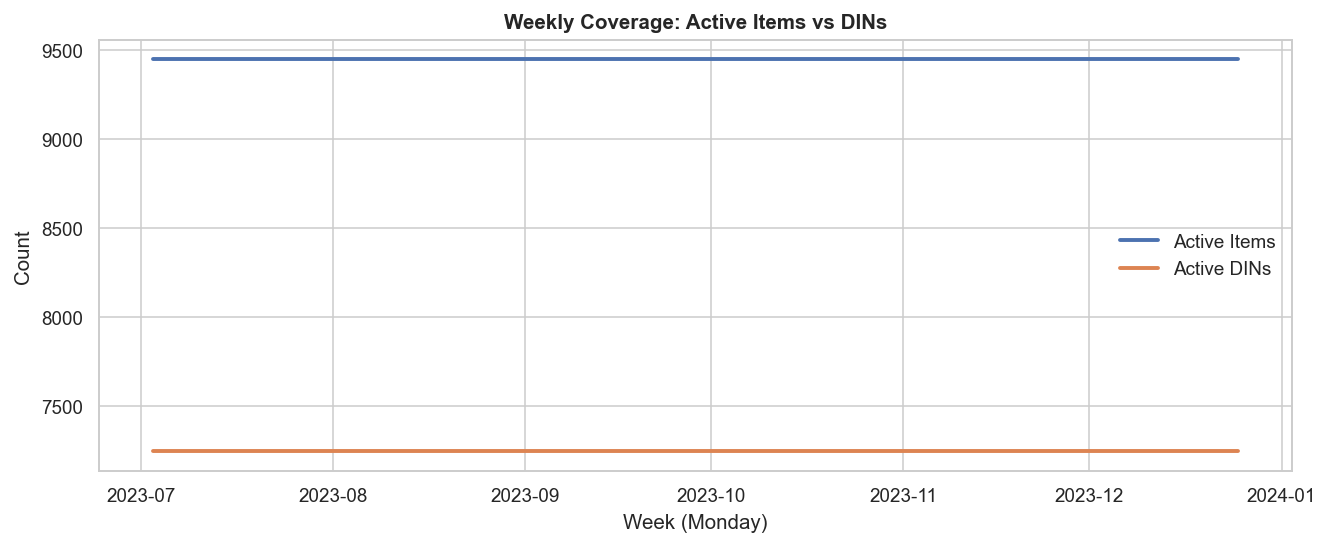

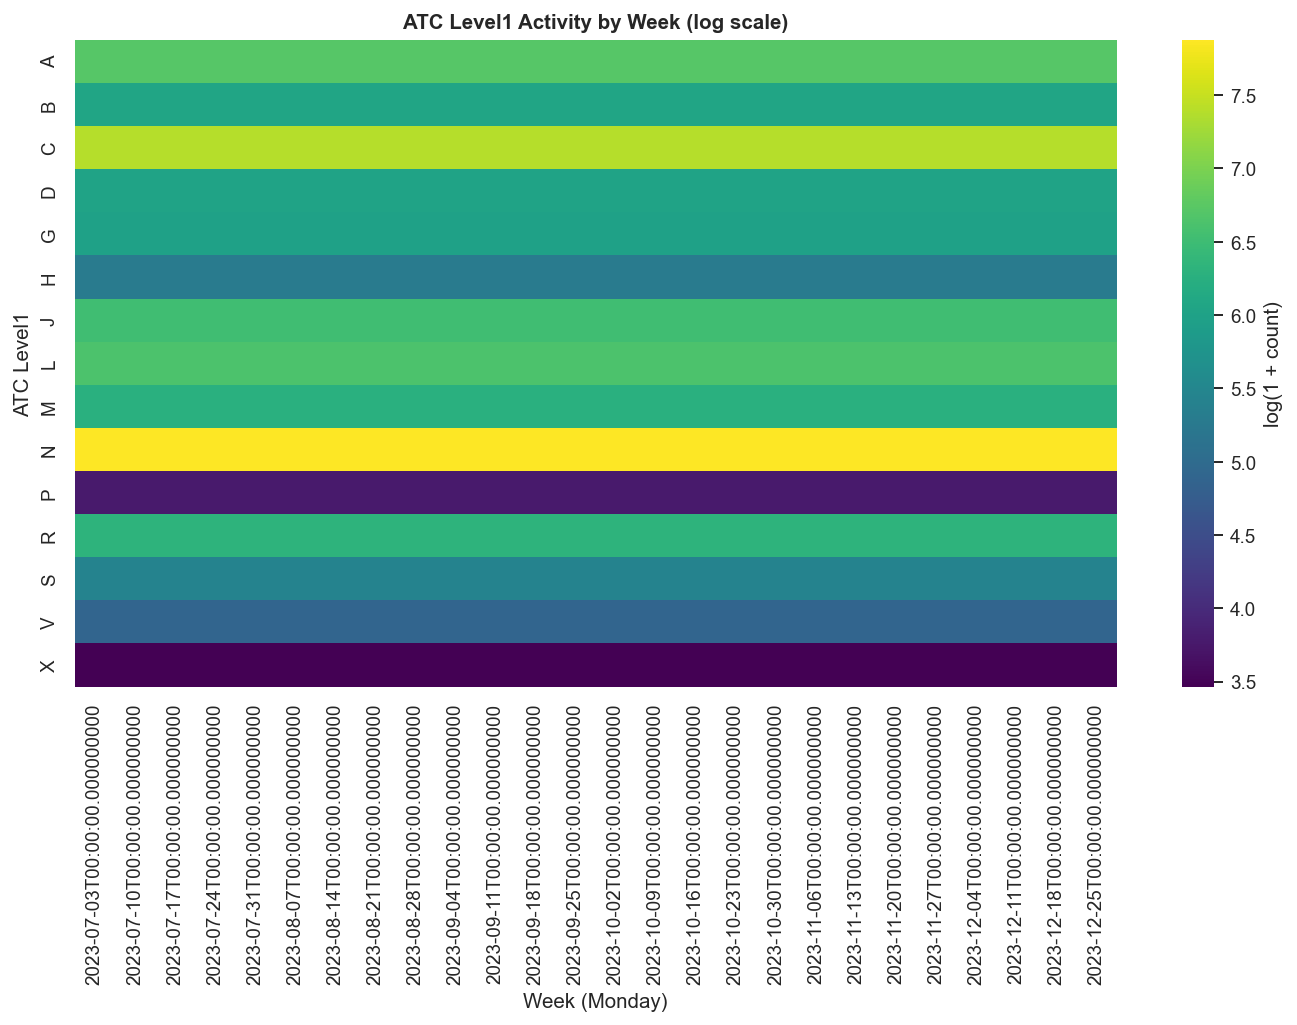

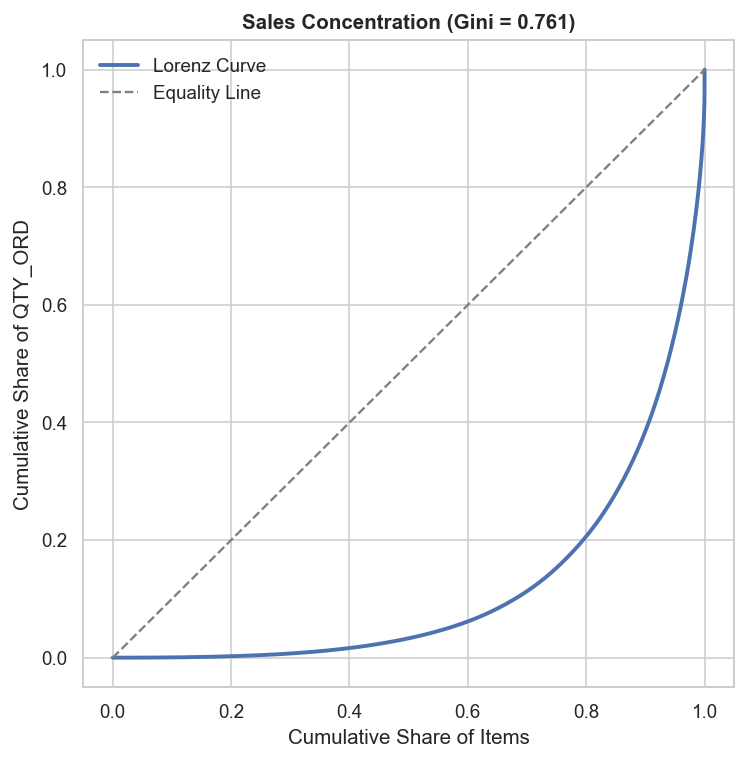

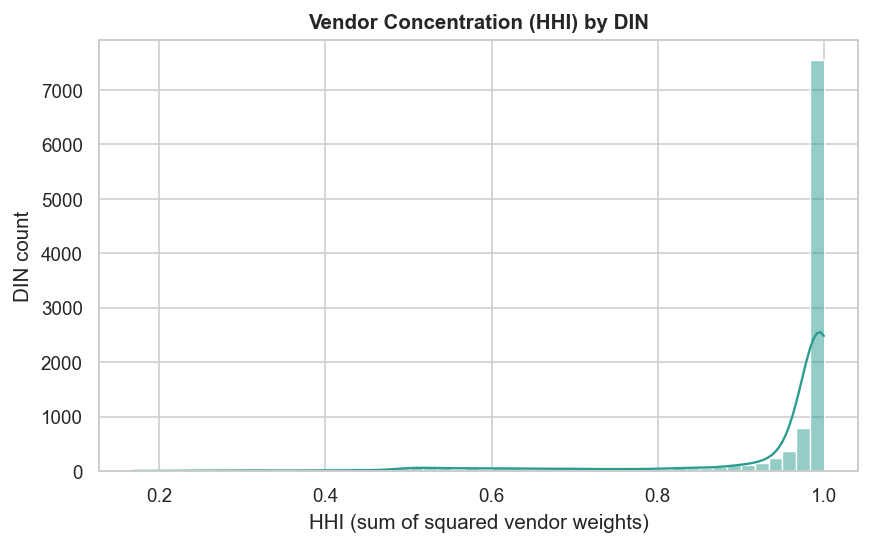

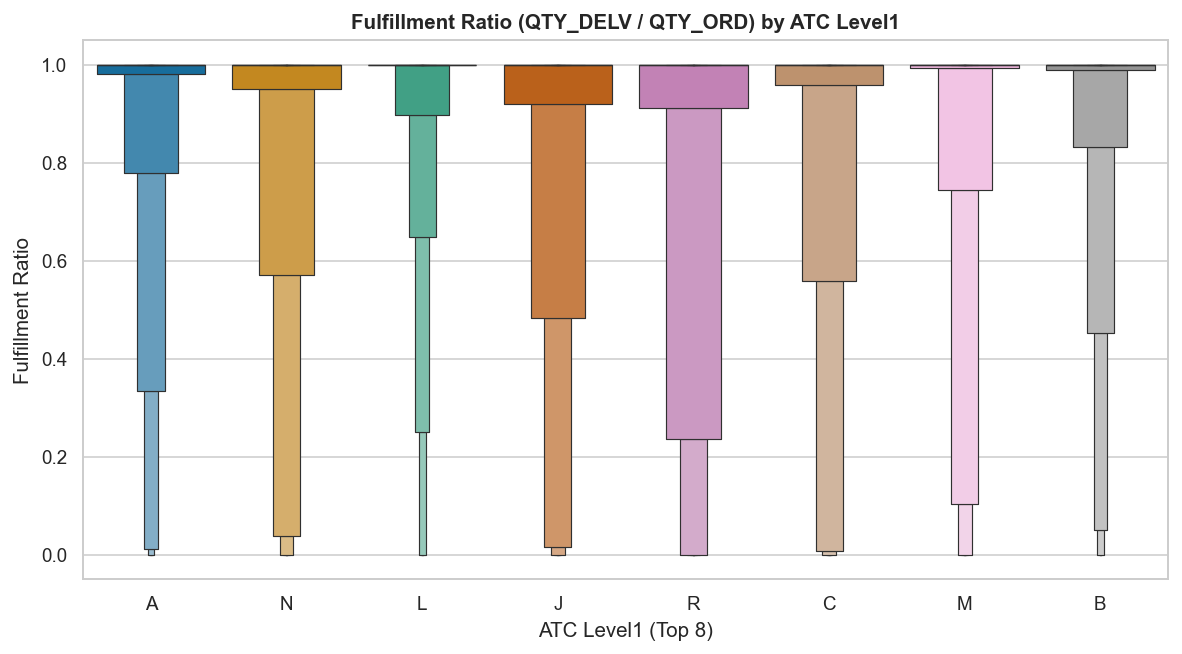

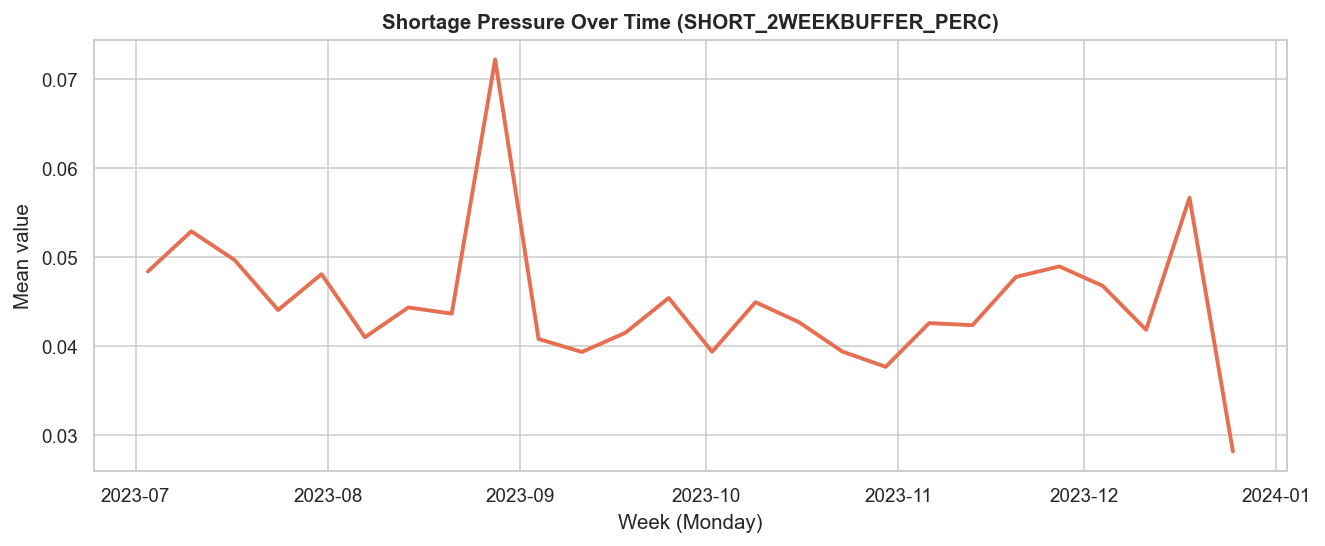

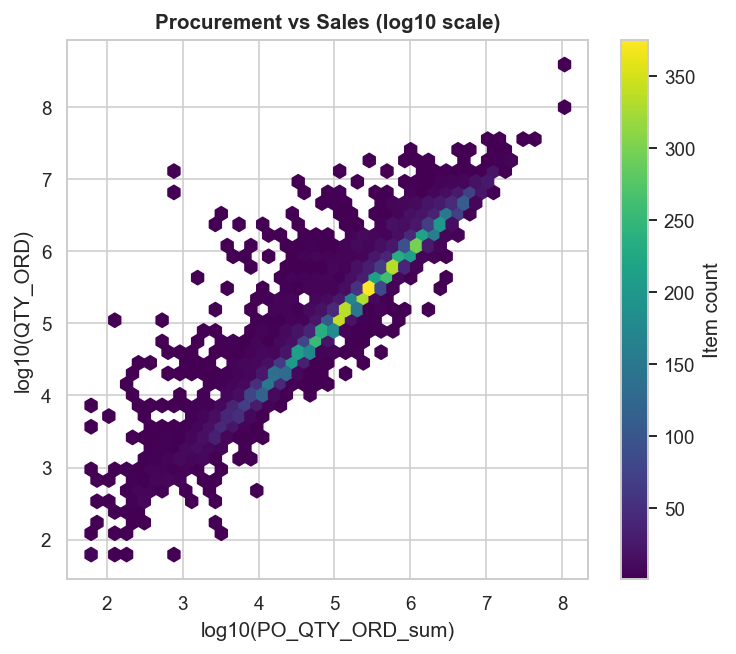

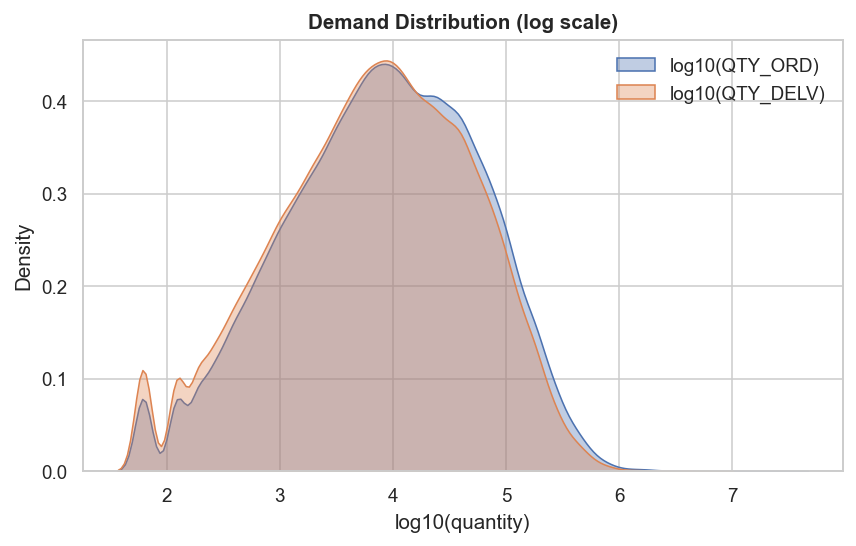

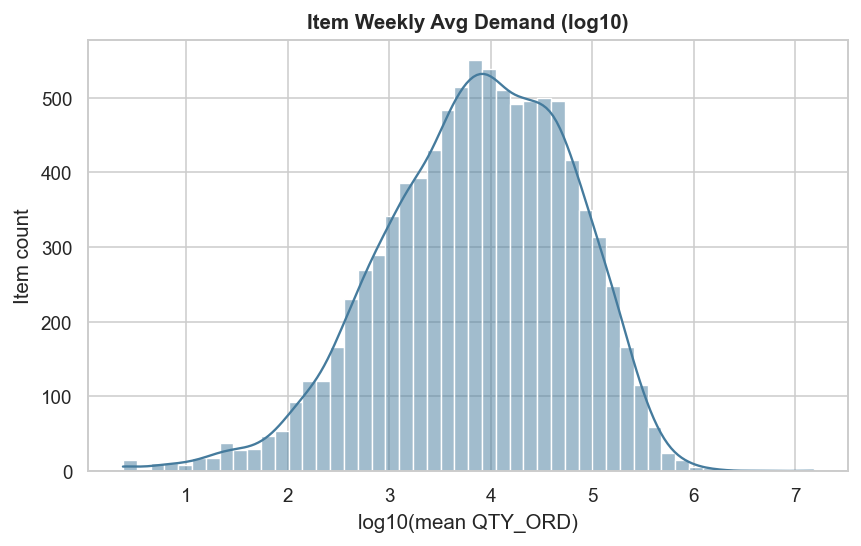

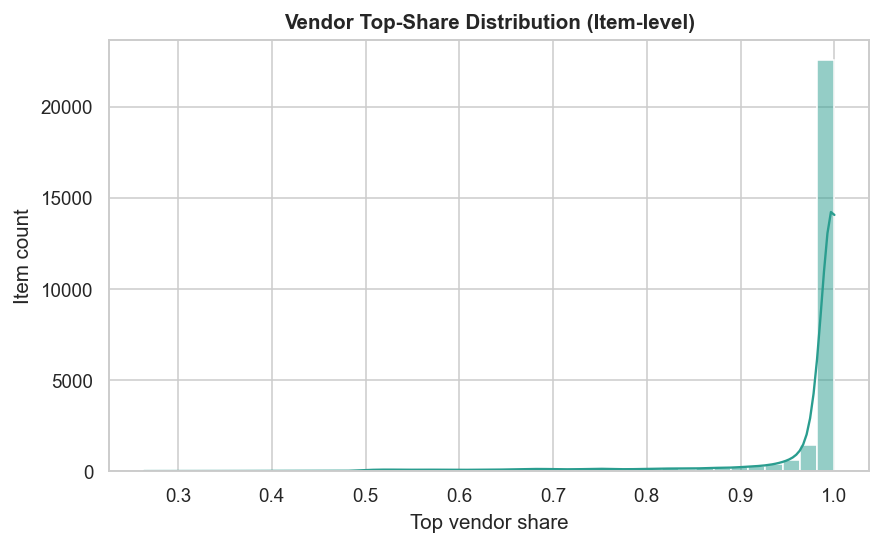

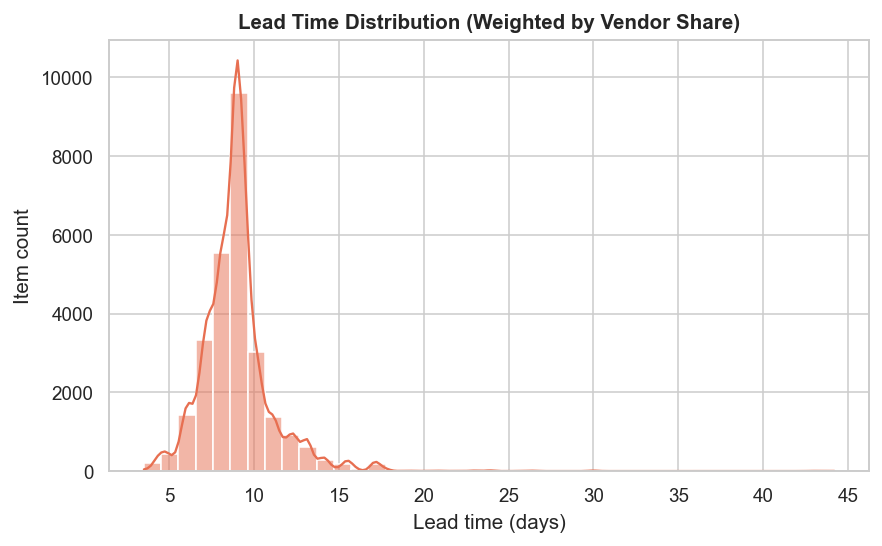

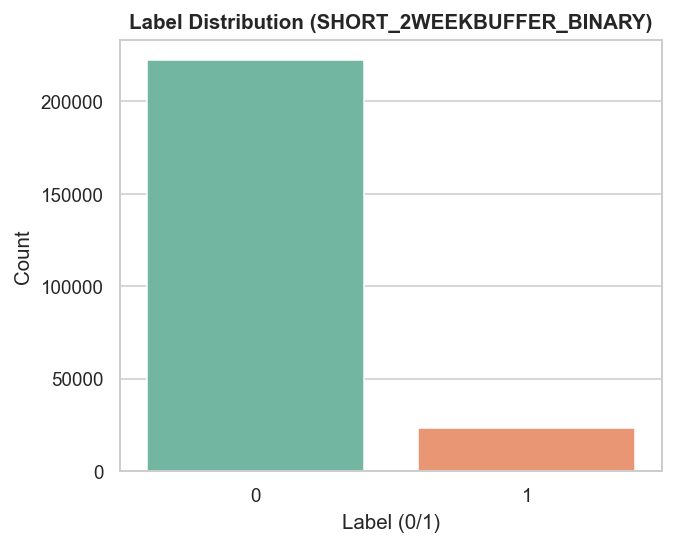

In [4]:
# ==============================================================================
# SECTION 2.5: EXPLORATORY DATA ANALYSIS (ITEM)
# ==============================================================================
# Assumes Section 2 has been executed and the following objects exist:
#   df_item_scope, df_train_p2_panel, df_weekly_sales,
#   df_vendor_din_map, df_vendor_item_map, df_lead_times, df_trends, df_cpi, df_flu
#
# Output: saved plots under Output_v2/eda_section2_5 (and shown inline)
# ==============================================================================

def run_section2_5_eda(
    df_item_scope: pd.DataFrame,
    df_train_p2_panel: pd.DataFrame,
    df_weekly_sales: pd.DataFrame,
    df_vendor_din_map: pd.DataFrame,
    df_vendor_item_map: pd.DataFrame,
    df_lead_times: pd.DataFrame,
    df_trends: pd.DataFrame,
    df_cpi: pd.DataFrame,
    df_flu: pd.DataFrame,
    output_dir: Path = None,
    sample_n: int = 200_000,
    seed: int = 42,
    save_fig: bool = True,
    show_fig: bool = True
):
    print("\n" + "═" * 80)
    print("║" + " " * 20 + "SECTION 2.5: EDA (ITEM)" + " " * 20 + "║")
    print("═" * 80)

    if df_train_p2_panel is None or df_train_p2_panel.empty:
        print("No train_P2 panel found. EDA skipped.")
        return

    if output_dir is None:
        output_dir = Config.OUTPUT_DIR / "eda_section2_5"
    output_dir.mkdir(parents=True, exist_ok=True)

    # global plotting style (SCI-like, clean, high readability)
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    plt.rcParams["figure.dpi"] = 140
    plt.rcParams["savefig.dpi"] = 300
    plt.rcParams["axes.titleweight"] = "bold"

    # helper utilities
    def _has_col(df, col):
        return df is not None and (col in df.columns)

    def _maybe_sample(df, n=sample_n):
        if df is None or df.empty:
            return df
        if len(df) <= n:
            return df
        return df.sample(n=n, random_state=seed)

    def _save(fig, name):
        if save_fig:
            fig.savefig(output_dir / f"{name}.png", bbox_inches="tight")
        if not show_fig:
            plt.close(fig)

    def _safe_num(s):
        return pd.to_numeric(s, errors="coerce")

    # join scope info
    scope_cols = ["ITEM_NUM_CLEAN", "DIN_KEY", "ATC_LEVEL1", "FINAL_MOLECULE"]
    scope_cols = [c for c in scope_cols if c in df_item_scope.columns]
    df_scope = df_item_scope[scope_cols].drop_duplicates("ITEM_NUM_CLEAN")

    df_panel = df_train_p2_panel.merge(df_scope, on="ITEM_NUM_CLEAN", how="left")

    # -------------------------------------------------------------------------
    # 1) Coverage trend: active items & DINs per week
    # -------------------------------------------------------------------------
    print("\n[EDA 1/12] Coverage trend: active items & DINs per week")
    panel_unique = df_panel[["ITEM_NUM_CLEAN", "DIN_KEY", "date_monday"]].drop_duplicates()
    cov = panel_unique.groupby("date_monday").agg(
        n_items=("ITEM_NUM_CLEAN", "nunique"),
        n_dins=("DIN_KEY", "nunique")
    ).reset_index()

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(cov["date_monday"], cov["n_items"], label="Active Items", linewidth=2)
    ax.plot(cov["date_monday"], cov["n_dins"], label="Active DINs", linewidth=2)
    ax.set_title("Weekly Coverage: Active Items vs DINs")
    ax.set_xlabel("Week (Monday)")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)
    _save(fig, "eda_01_coverage_trend")

    # -------------------------------------------------------------------------
    # 2) ATC x Week heatmap (log count)
    # -------------------------------------------------------------------------
    print("[EDA 2/12] ATC x Week heatmap (log counts)")
    if _has_col(df_panel, "ATC_LEVEL1"):
        atc_week = (
            df_panel.groupby(["ATC_LEVEL1", "date_monday"])["ITEM_NUM_CLEAN"]
            .nunique()
            .reset_index(name="n_items")
        )
        pivot = atc_week.pivot(index="ATC_LEVEL1", columns="date_monday", values="n_items").fillna(0)
        heat = np.log1p(pivot)

        fig, ax = plt.subplots(figsize=(12, 6))
        sns.heatmap(heat, cmap="viridis", ax=ax, cbar_kws={"label": "log(1 + count)"})
        ax.set_title("ATC Level1 Activity by Week (log scale)")
        ax.set_xlabel("Week (Monday)")
        ax.set_ylabel("ATC Level1")
        _save(fig, "eda_02_atc_week_heatmap")
    else:
        print("  Skipped: ATC_LEVEL1 not found.")

    # -------------------------------------------------------------------------
    # 3) Lorenz curve + Gini (sales concentration)
    # -------------------------------------------------------------------------
    print("[EDA 3/12] Lorenz curve + Gini (sales concentration)")
    if _has_col(df_panel, "QTY_ORD"):
        item_sales = df_panel.groupby("ITEM_NUM_CLEAN")["QTY_ORD"].sum().sort_values()
        x = np.linspace(0, 1, len(item_sales), endpoint=True)
        y = item_sales.cumsum() / item_sales.sum()
        gini = 1 - 2 * np.trapz(y, x)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot(x, y, label="Lorenz Curve", linewidth=2)
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Equality Line")
        ax.set_title(f"Sales Concentration (Gini = {gini:.3f})")
        ax.set_xlabel("Cumulative Share of Items")
        ax.set_ylabel("Cumulative Share of QTY_ORD")
        ax.legend(frameon=False)
        _save(fig, "eda_03_lorenz_gini")
    else:
        print("  Skipped: QTY_ORD not found.")

    # -------------------------------------------------------------------------
    # 4) Vendor concentration (HHI distribution by DIN)
    # -------------------------------------------------------------------------
    print("[EDA 4/12] Vendor concentration (HHI) by DIN")
    if df_vendor_din_map is not None and not df_vendor_din_map.empty:
        hhi = (
            df_vendor_din_map.groupby("DIN_KEY")["vendor_weight"]
            .apply(lambda w: float((w ** 2).sum()))
            .reset_index(name="HHI")
        )
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.histplot(hhi["HHI"], bins=50, kde=True, ax=ax, color="#2a9d8f")
        ax.set_title("Vendor Concentration (HHI) by DIN")
        ax.set_xlabel("HHI (sum of squared vendor weights)")
        ax.set_ylabel("DIN count")
        _save(fig, "eda_04_vendor_hhi")
    else:
        print("  Skipped: df_vendor_din_map not found.")

    # -------------------------------------------------------------------------
    # 5) Fulfillment ratio distribution by ATC Level1
    # -------------------------------------------------------------------------
    print("[EDA 5/12] Fulfillment ratio by ATC Level1")
    if _has_col(df_panel, "QTY_DELV") and _has_col(df_panel, "QTY_ORD") and _has_col(df_panel, "ATC_LEVEL1"):
        tmp = df_panel.copy()
        tmp = tmp[tmp["QTY_ORD"] > 0]
        tmp["fill_rate"] = (tmp["QTY_DELV"] / tmp["QTY_ORD"]).clip(0, 2)

        top_atc = (
            tmp.groupby("ATC_LEVEL1")["ITEM_NUM_CLEAN"]
            .nunique()
            .sort_values(ascending=False)
            .head(8)
            .index
        )
        tmp = tmp[tmp["ATC_LEVEL1"].isin(top_atc)]
        tmp = _maybe_sample(tmp)

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxenplot(data=tmp, x="ATC_LEVEL1", y="fill_rate", ax=ax, palette="colorblind")
        ax.set_title("Fulfillment Ratio (QTY_DELV / QTY_ORD) by ATC Level1")
        ax.set_xlabel("ATC Level1 (Top 8)")
        ax.set_ylabel("Fulfillment Ratio")
        _save(fig, "eda_05_fill_rate_by_atc")
    else:
        print("  Skipped: required columns missing (QTY_DELV/QTY_ORD/ATC_LEVEL1).")

    # -------------------------------------------------------------------------
    # 6) Shortage pressure over time
    # -------------------------------------------------------------------------
    print("[EDA 6/12] Shortage pressure over time")
    shortage_col = None
    if _has_col(df_panel, "SHORT_2WEEKBUFFER_PERC"):
        shortage_col = "SHORT_2WEEKBUFFER_PERC"
    elif _has_col(df_panel, "SHORT_QTY_WEEKLY"):
        shortage_col = "SHORT_QTY_WEEKLY"

    if shortage_col is not None:
        series = (
            df_panel.groupby("date_monday")[shortage_col]
            .mean()
            .reset_index()
        )
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(series["date_monday"], series[shortage_col], linewidth=2, color="#e76f51")
        ax.set_title(f"Shortage Pressure Over Time ({shortage_col})")
        ax.set_xlabel("Week (Monday)")
        ax.set_ylabel("Mean value")
        _save(fig, "eda_06_shortage_over_time")
    else:
        print("  Skipped: shortage columns not found.")

    # -------------------------------------------------------------------------
    # 7) Procurement vs Sales density (hexbin)
    # -------------------------------------------------------------------------
    print("[EDA 7/12] Procurement vs Sales (hexbin)")
    if _has_col(df_panel, "PO_QTY_ORD_sum") and _has_col(df_panel, "QTY_ORD"):
        item_agg = df_panel.groupby("ITEM_NUM_CLEAN")[["PO_QTY_ORD_sum", "QTY_ORD"]].sum().reset_index()
        item_agg = item_agg[(item_agg["PO_QTY_ORD_sum"] > 0) & (item_agg["QTY_ORD"] > 0)]
        fig, ax = plt.subplots(figsize=(6, 5))
        hb = ax.hexbin(
            np.log10(item_agg["PO_QTY_ORD_sum"]),
            np.log10(item_agg["QTY_ORD"]),
            gridsize=40,
            cmap="viridis",
            mincnt=1
        )
        cb = fig.colorbar(hb, ax=ax)
        cb.set_label("Item count")
        ax.set_title("Procurement vs Sales (log10 scale)")
        ax.set_xlabel("log10(PO_QTY_ORD_sum)")
        ax.set_ylabel("log10(QTY_ORD)")
        _save(fig, "eda_07_procurement_vs_sales")
    else:
        print("  Skipped: PO_QTY_ORD_sum or QTY_ORD not found.")

    # -------------------------------------------------------------------------
    # 8) Demand distribution (log-scale KDE)
    # -------------------------------------------------------------------------
    print("[EDA 8/12] Demand distribution (log KDE)")
    if _has_col(df_panel, "QTY_ORD") and _has_col(df_panel, "QTY_DELV"):
        tmp = df_panel[["QTY_ORD", "QTY_DELV"]].copy()
        tmp = tmp[(tmp["QTY_ORD"] > 0) & (tmp["QTY_DELV"] > 0)]
        tmp["log_qty_ord"] = np.log10(tmp["QTY_ORD"])
        tmp["log_qty_delv"] = np.log10(tmp["QTY_DELV"])
        tmp = _maybe_sample(tmp)

        fig, ax = plt.subplots(figsize=(7, 4))
        sns.kdeplot(tmp["log_qty_ord"], label="log10(QTY_ORD)", fill=True, alpha=0.35, ax=ax)
        sns.kdeplot(tmp["log_qty_delv"], label="log10(QTY_DELV)", fill=True, alpha=0.35, ax=ax)
        ax.set_title("Demand Distribution (log scale)")
        ax.set_xlabel("log10(quantity)")
        ax.set_ylabel("Density")
        ax.legend(frameon=False)
        _save(fig, "eda_08_demand_log_kde")
    else:
        print("  Skipped: QTY_ORD/QTY_DELV missing.")

    # -------------------------------------------------------------------------
    # 9) Item-level weekly average demand distribution
    # -------------------------------------------------------------------------
    print("[EDA 9/12] Item-level weekly average demand distribution")
    if _has_col(df_panel, "QTY_ORD"):
        item_weekly_mean = df_panel.groupby("ITEM_NUM_CLEAN")["QTY_ORD"].mean()
        item_weekly_mean = item_weekly_mean[item_weekly_mean > 0]
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.histplot(np.log10(item_weekly_mean), bins=50, kde=True, ax=ax, color="#457b9d")
        ax.set_title("Item Weekly Avg Demand (log10)")
        ax.set_xlabel("log10(mean QTY_ORD)")
        ax.set_ylabel("Item count")
        _save(fig, "eda_09_item_weekly_mean")
    else:
        print("  Skipped: QTY_ORD missing.")

    # -------------------------------------------------------------------------
    # 10) Vendor top-share distribution (item-level concentration)
    # -------------------------------------------------------------------------
    print("[EDA 10/12] Vendor top-share distribution (item-level)")
    if df_vendor_item_map is not None and not df_vendor_item_map.empty:
        top_share = (
            df_vendor_item_map.groupby("ITEM_NUM_CLEAN")["vendor_weight"]
            .max()
            .reset_index(name="top_share")
        )
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.histplot(top_share["top_share"], bins=40, kde=True, ax=ax, color="#2a9d8f")
        ax.set_title("Vendor Top-Share Distribution (Item-level)")
        ax.set_xlabel("Top vendor share")
        ax.set_ylabel("Item count")
        _save(fig, "eda_10_vendor_topshare")
    else:
        print("  Skipped: df_vendor_item_map missing.")

    # -------------------------------------------------------------------------
    # 11) Lead time distribution (vendor-weighted, item-level)
    # -------------------------------------------------------------------------
    print("[EDA 11/12] Lead time distribution (weighted item-level)")
    if df_lead_times is not None and not df_lead_times.empty and df_vendor_item_map is not None and not df_vendor_item_map.empty:
        if "TotalLeadTime" not in df_lead_times.columns:
            df_lead_times["TotalLeadTime"] = (
                _safe_num(df_lead_times.get("LoadTime", 0)).fillna(0) +
                _safe_num(df_lead_times.get("TransLeadTime", 0)).fillna(0) +
                _safe_num(df_lead_times.get("UnloadTime", 0)).fillna(0)
            )
        tmp = df_vendor_item_map.merge(
            df_lead_times[["VENDOR_NUM", "TotalLeadTime"]],
            on="VENDOR_NUM", how="left"
        ).dropna(subset=["TotalLeadTime"])

        if not tmp.empty:
            lt_w = (
                tmp.groupby("ITEM_NUM_CLEAN")
                .apply(lambda g: np.average(g["TotalLeadTime"], weights=g["vendor_weight"]))
                .reset_index(name="leadtime_wavg")
            )
            fig, ax = plt.subplots(figsize=(7, 4))
            sns.histplot(lt_w["leadtime_wavg"], bins=40, kde=True, ax=ax, color="#e76f51")
            ax.set_title("Lead Time Distribution (Weighted by Vendor Share)")
            ax.set_xlabel("Lead time (days)")
            ax.set_ylabel("Item count")
            _save(fig, "eda_11_leadtime_dist")
        else:
            print("  Skipped: no lead time after merge.")
    else:
        print("  Skipped: lead time or vendor map missing.")

    # -------------------------------------------------------------------------
    # 12) Shortage label distribution
    # -------------------------------------------------------------------------
    print("[EDA 12/12] Shortage label distribution")
    label_col = None
    if _has_col(df_panel, "SHORT_2WEEKBUFFER_BINARY"):
        label_col = "SHORT_2WEEKBUFFER_BINARY"
    elif _has_col(df_panel, "SHORT_2WEEKBUFFER_BINARY_in6_weeks"):
        label_col = "SHORT_2WEEKBUFFER_BINARY_in6_weeks"

    if label_col is not None:
        vals = df_panel[label_col].dropna().astype(int)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.countplot(x=vals, ax=ax, palette="Set2")
        ax.set_title(f"Label Distribution ({label_col})")
        ax.set_xlabel("Label (0/1)")
        ax.set_ylabel("Count")
        _save(fig, "eda_12_label_distribution")
    else:
        print("  Skipped: no binary label columns found.")

    print("\nEDA finished.")
    print(f"Saved to: {output_dir}")

# ------------------------------------------------------------------------------
# EXECUTION
# ------------------------------------------------------------------------------
run_section2_5_eda(
    df_item_scope=df_item_scope,
    df_train_p2_panel=df_train_p2_panel,
    df_weekly_sales=df_weekly_sales,
    df_vendor_din_map=df_vendor_din_map,
    df_vendor_item_map=df_vendor_item_map,
    df_lead_times=df_lead_times,
    df_trends=df_trends,
    df_cpi=df_cpi,
    df_flu=df_flu
)

In [5]:
# ------------------------------------------------------------------------------
# Molecule Count Diagnostics (overall scope + active in panel)
# ------------------------------------------------------------------------------
if df_item_scope is not None and not df_item_scope.empty:
    mol_col = "FINAL_MOLECULE" if "FINAL_MOLECULE" in df_item_scope.columns else None
    if mol_col:
        # overall scope
        mol_item = df_item_scope.groupby(mol_col)["ITEM_NUM_CLEAN"].nunique().sort_values(ascending=False)
        print("\n" + "─" * 70)
        print("MOLECULE COUNT (OVERALL SCOPE)")
        print(f"  unique molecules: {mol_item.shape[0]:,}")
        print(f"  items per molecule: mean={mol_item.mean():.2f}, median={mol_item.median():.0f}, p95={mol_item.quantile(0.95):.0f}")
        print(f"  molecules with >1 item: {(mol_item > 1).sum():,}")
        print("  top 10 molecules by item count:")
        print(mol_item.head(10).to_string())
        print("─" * 70)

        # active in panel (time window)
        if df_train_p2_panel is not None and not df_train_p2_panel.empty:
            active_items = df_train_p2_panel["ITEM_NUM_CLEAN"].dropna().astype(int).unique()
            active_scope = df_item_scope[df_item_scope["ITEM_NUM_CLEAN"].isin(active_items)]
            mol_item_active = active_scope.groupby(mol_col)["ITEM_NUM_CLEAN"].nunique().sort_values(ascending=False)
            print("\n" + "─" * 70)
            print("MOLECULE COUNT (ACTIVE IN PANEL WINDOW)")
            print(f"  unique molecules: {mol_item_active.shape[0]:,}")
            print(f"  items per molecule: mean={mol_item_active.mean():.2f}, median={mol_item_active.median():.0f}, p95={mol_item_active.quantile(0.95):.0f}")
            print(f"  molecules with >1 item: {(mol_item_active > 1).sum():,}")
            print("  top 10 molecules by item count:")
            print(mol_item_active.head(10).to_string())
            print("─" * 70)

        # ----------------------------------------------------------------------
        # Molecule Token Count per Item (based on separators in FINAL_MOLECULE)
        # ----------------------------------------------------------------------
        def _count_molecules_from_string(s: str):
            if not isinstance(s, str) or not s.strip():
                return np.nan
            s = s.upper().strip()
            # normalize separators
            s = re.sub(r"\s*(/|&|\+|,|;)\s*", "|", s)
            s = re.sub(r"\s+(AND|WITH)\s+", "|", s)
            tokens = [t.strip() for t in s.split("|") if t.strip()]
            if len(tokens) == 0:
                return np.nan
            return len(tokens)

        # overall scope counts
        item_mol_count = (
            df_item_scope.drop_duplicates("ITEM_NUM_CLEAN")
            .assign(_mol_n=lambda d: d[mol_col].apply(_count_molecules_from_string))
            .dropna(subset=["_mol_n"])
        )
        dist = item_mol_count["_mol_n"].value_counts().sort_index()
        ge4 = int(item_mol_count["_mol_n"].ge(4).sum())

        print("\n" + "─" * 70)
        print("ITEM -> MOLECULE COUNT (OVERALL SCOPE)")
        for k in [1, 2, 3]:
            print(f"  items with {k} molecule(s): {int(dist.get(k, 0)):,}")
        print(f"  items with 4+ molecules  : {ge4:,}")
        print("─" * 70)

        # active scope counts (within current panel window)
        if df_train_p2_panel is not None and not df_train_p2_panel.empty:
            active_items = df_train_p2_panel["ITEM_NUM_CLEAN"].dropna().astype(int).unique()
            active_item_mol = (
                item_mol_count[item_mol_count["ITEM_NUM_CLEAN"].isin(active_items)]
            )
            dist_a = active_item_mol["_mol_n"].value_counts().sort_index()
            ge4_a = int(active_item_mol["_mol_n"].ge(4).sum())

            print("\n" + "─" * 70)
            print("ITEM -> MOLECULE COUNT (ACTIVE IN PANEL WINDOW)")
            for k in [1, 2, 3]:
                print(f"  items with {k} molecule(s): {int(dist_a.get(k, 0)):,}")
            print(f"  items with 4+ molecules  : {ge4_a:,}")
            print("─" * 70)


──────────────────────────────────────────────────────────────────────
MOLECULE COUNT (OVERALL SCOPE)
  unique molecules: 8,687
  items per molecule: mean=6.95, median=1, p95=25
  molecules with >1 item: 2,658
  top 10 molecules by item count:
FINAL_MOLECULE
COMBINATION_PRODUCT        3761
ELECTROLYTE_COMBINATION    1854
ACETAMINOPHEN              1329
IBUPROFEN                  1138
PYRITHIONE ZINC             403
ACETYLSALICYLIC ACID        402
SIMVASTATIN                 399
MULTIVIT_MINERALS           393
RISPERIDONE                 393
ROSUVASTATIN CALCIUM        382
──────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────
MOLECULE COUNT (ACTIVE IN PANEL WINDOW)
  unique molecules: 1,603
  items per molecule: mean=5.89, median=2, p95=24
  molecules with >1 item: 1,067
  top 10 molecules by item count:
FINAL_MOLECULE
ACETAMINOPHEN           141
IBUPROFEN               122
PREGABALIN              

In [ ]:
# ==============================================================================
# SECTION 3: FEATURE ENGINEERING PIPELINE (ITEM-LEVEL)
# ==============================================================================
"""
Enterprise Drug Shortage Prediction System
Section 3: Feature Engineering Pipeline (Item-Level)

Primary Key:
  - ITEM_NUM_CLEAN + date_monday

Purpose:
  - Construct a model-ready item-week panel by merging internal + external features
  - Add safe historical (lagged) shortage signals
  - Build a 4-week-ahead shortage label (label_4w) without leakage

Inputs (from Section 2):
  1) df_item_scope           : item master + DIN + molecule + ATC + product flags
  2) df_train_p2_panel       : item-week core panel (train_P2 aggregated)
  3) df_weekly_sales         : item-week sales panel
  4) df_vendor_item_map      : item-vendor weights (PO volume share)
  5) df_vendor_din_map       : DIN-vendor weights
  6) df_purchase_orders      : PO transactions (optional)
  7) df_receptions           : reception transactions (optional)
  8) df_lead_times           : vendor lead times (load/trans/unload)
  9) df_trends               : ATC-level trends (weekly)
 10) df_cpi                  : CPI weekly (global)
 11) df_flu                  : FluNet weekly (global)

Feature Matrix Components:
  - Train_P2 numeric panel features (item-week)
  - Weekly sales features (WS_*)
  - Static item attributes (ATC, class group, flags, vendor count)
  - Vendor concentration stats (HHI, top share, vendor count)
  - Vendor-weighted lead times (item-level + DIN-level)
  - External signals (Trends, CPI, Flu)
  - Rolling stats for operational metrics
  - Shortage lag features (safe historical signal)

Label Logic (Standard 4-week, leakage-safe):
  - label_4w = 1 if shortage occurs in any of the next 4 weeks
  - if future 4 weeks are incomplete, label_4w = NA (avoid tail bias)

Output:
  - df_panel: full feature table with labels (tail labels may be NA)
  - feature_cols, label_cols
"""

# ------------------------------------------------------------------------------
# UTILITIES
# ------------------------------------------------------------------------------
def _safe_num(s):
    return pd.to_numeric(s, errors="coerce")

def _ensure_datetime(df, col):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def _standardize_form(s: pd.Series) -> pd.Series:
    """Normalize raw form text to a stable token."""
    s = s.astype("string").str.upper().str.strip()
    s = s.replace({"": pd.NA, "<NA>": pd.NA, "NONE": pd.NA, "NAN": pd.NA})
    s = s.str.replace(r"[^A-Z0-9]+", " ", regex=True).str.strip()
    s = s.replace({
        "TAB": "TABLET",
        "TABS": "TABLET",
        "CAP": "CAPSULE",
        "CAPS": "CAPSULE",
        "CAPSULES": "CAPSULE",
        "INJ": "INJECTION",
        "SOL": "SOLUTION",
        "SUSP": "SUSPENSION"
    })
    return s

# ------------------------------------------------------------------------------
# MAIN FEATURE ENGINEER
# ------------------------------------------------------------------------------
class FeatureEngineer:
    def __init__(self):
        self.windows = dict(Config.WINDOWS)
        self.form_cfg = getattr(Config, "PRODUCT_ATTRIBUTE_CONFIG", {
            "tracked_forms": [],
            "auto_form_min_share": 0.05,
            "auto_form_min_count": 20,
            "auto_form_use_train_scope": True,
            "form_unknown_label": "UNKNOWN"
        })

    # --------------------------------------------------------------------------
    # Vendor concentration features (item-level)
    # --------------------------------------------------------------------------
    @staticmethod
    def build_vendor_stats_item(df_vendor_item_map: pd.DataFrame) -> pd.DataFrame:
        """Compute vendor concentration stats by item."""
        if df_vendor_item_map is None or df_vendor_item_map.empty:
            return pd.DataFrame()

        g = df_vendor_item_map.groupby("ITEM_NUM_CLEAN")
        stats = g["vendor_weight"].agg([
            ("vendor_count_item", "count"),
            ("vendor_top_share_item", "max")
        ]).reset_index()

        hhi = g["vendor_weight"].apply(lambda w: float((w ** 2).sum())).reset_index(name="vendor_hhi_item")
        stats = stats.merge(hhi, on="ITEM_NUM_CLEAN", how="left")
        return stats

    # --------------------------------------------------------------------------
    # Vendor concentration features (DIN-level)
    # --------------------------------------------------------------------------
    @staticmethod
    def build_vendor_stats_din(df_vendor_din_map: pd.DataFrame) -> pd.DataFrame:
        """Compute vendor concentration stats by DIN."""
        if df_vendor_din_map is None or df_vendor_din_map.empty:
            return pd.DataFrame()

        g = df_vendor_din_map.groupby("DIN_KEY")
        stats = g["vendor_weight"].agg([
            ("vendor_count_din", "count"),
            ("vendor_top_share_din", "max")
        ]).reset_index()

        hhi = g["vendor_weight"].apply(lambda w: float((w ** 2).sum())).reset_index(name="vendor_hhi_din")
        stats = stats.merge(hhi, on="DIN_KEY", how="left")
        return stats

    # --------------------------------------------------------------------------
    # Lead time features (vendor-weighted)
    # --------------------------------------------------------------------------
    @staticmethod
    def build_weighted_leadtime_item(df_vendor_item_map, df_lead_times) -> pd.DataFrame:
        """Weighted lead time per item (weights = vendor share)."""
        if df_vendor_item_map is None or df_vendor_item_map.empty:
            return pd.DataFrame()
        if df_lead_times is None or df_lead_times.empty:
            return pd.DataFrame()

        if "TotalLeadTime" not in df_lead_times.columns:
            df_lead_times["TotalLeadTime"] = (
                _safe_num(df_lead_times.get("LoadTime", 0)).fillna(0) +
                _safe_num(df_lead_times.get("TransLeadTime", 0)).fillna(0) +
                _safe_num(df_lead_times.get("UnloadTime", 0)).fillna(0)
            )

        tmp = df_vendor_item_map.merge(
            df_lead_times[["VENDOR_NUM", "TotalLeadTime"]],
            on="VENDOR_NUM", how="left"
        ).dropna(subset=["TotalLeadTime"])

        if tmp.empty:
            return pd.DataFrame()

        wavg = (
            tmp.groupby("ITEM_NUM_CLEAN")
            .apply(lambda g: np.average(g["TotalLeadTime"], weights=g["vendor_weight"]))
            .reset_index(name="leadtime_wavg_item")
        )
        return wavg

    @staticmethod
    def build_weighted_leadtime_din(df_vendor_din_map, df_lead_times) -> pd.DataFrame:
        """Weighted lead time per DIN (weights = vendor share)."""
        if df_vendor_din_map is None or df_vendor_din_map.empty:
            return pd.DataFrame()
        if df_lead_times is None or df_lead_times.empty:
            return pd.DataFrame()

        if "TotalLeadTime" not in df_lead_times.columns:
            df_lead_times["TotalLeadTime"] = (
                _safe_num(df_lead_times.get("LoadTime", 0)).fillna(0) +
                _safe_num(df_lead_times.get("TransLeadTime", 0)).fillna(0) +
                _safe_num(df_lead_times.get("UnloadTime", 0)).fillna(0)
            )

        tmp = df_vendor_din_map.merge(
            df_lead_times[["VENDOR_NUM", "TotalLeadTime"]],
            on="VENDOR_NUM", how="left"
        ).dropna(subset=["TotalLeadTime"])

        if tmp.empty:
            return pd.DataFrame()

        wavg = (
            tmp.groupby("DIN_KEY")
            .apply(lambda g: np.average(g["TotalLeadTime"], weights=g["vendor_weight"]))
            .reset_index(name="leadtime_wavg_din")
        )
        return wavg

    # --------------------------------------------------------------------------
    # Form features (manual + auto selection)
    # --------------------------------------------------------------------------
    def build_form_features(self, df_item_scope, df_train_p2_panel):
        """Create one-hot form features using manual list + auto-selected forms."""
        if df_item_scope is None or df_item_scope.empty:
            return pd.DataFrame(), []

        if "EN_FORM" in df_item_scope.columns:
            base = df_item_scope[["ITEM_NUM_CLEAN", "EN_FORM"]].copy()
        else:
            base = df_item_scope[["ITEM_NUM_CLEAN"]].copy()
            base["EN_FORM"] = pd.NA

        base["FORM_NORM"] = _standardize_form(base["EN_FORM"])

        use_train_scope = bool(self.form_cfg.get("auto_form_use_train_scope", True))
        min_share = float(self.form_cfg.get("auto_form_min_share", 0.05))
        min_count = int(self.form_cfg.get("auto_form_min_count", 20))
        manual = [f.upper().strip() for f in self.form_cfg.get("tracked_forms", []) if isinstance(f, str)]

        if use_train_scope and df_train_p2_panel is not None and not df_train_p2_panel.empty:
            scope_items = set(df_train_p2_panel["ITEM_NUM_CLEAN"].dropna().astype(int).unique())
            base_scope = base[base["ITEM_NUM_CLEAN"].isin(scope_items)].copy()
        else:
            base_scope = base.copy()

        form_counts = base_scope["FORM_NORM"].value_counts(dropna=True)
        total = form_counts.sum()
        auto_forms = []
        if total > 0:
            auto_forms = form_counts[
                (form_counts >= min_count) & ((form_counts / total) >= min_share)
            ].index.tolist()

        tracked_forms = sorted(set(manual + auto_forms))

        df_form = base[["ITEM_NUM_CLEAN", "FORM_NORM"]].copy()
        for f in tracked_forms:
            col = f"form_{f.lower()}"
            df_form[col] = df_form["FORM_NORM"].eq(f).fillna(False).astype(int)

        df_form["form_other"] = (
            df_form["FORM_NORM"].notna() & ~df_form["FORM_NORM"].isin(tracked_forms)
        ).fillna(False).astype(int)

        df_form["form_missing"] = df_form["FORM_NORM"].isna().astype(int)
        df_form = df_form.drop(columns=["FORM_NORM"])

        print("\n[FORM FEATURE SELECTION]")
        print(f"  manual forms: {manual if manual else 'None'}")
        print(f"  auto forms  : {auto_forms if auto_forms else 'None'}")
        print(f"  tracked     : {tracked_forms if tracked_forms else 'None'}")
        print(f"  min_share   : {min_share}, min_count: {min_count}, use_train_scope: {use_train_scope}")

        return df_form, tracked_forms

    # --------------------------------------------------------------------------
    # Rolling features for operational metrics
    # --------------------------------------------------------------------------
    def add_rolling_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Rolling mean/std/sum for operational signals."""
        df = df.sort_values(["ITEM_NUM_CLEAN", "date_monday"]).reset_index(drop=True)
        g = df.groupby("ITEM_NUM_CLEAN", group_keys=False)

        base_cols = []
        for c in ["QTY_ORD", "QTY_DELV", "SHORT_QTY_WEEKLY"]:
            if c in df.columns:
                base_cols.append(c)
        for c in ["WS_QTY_ORD", "WS_QTY_DELV"]:
            if c in df.columns:
                base_cols.append(c)

        w_sales = int(self.windows.get("sales_history", 12))
        w_gap = int(self.windows.get("supply_gap", 4))

        for col in base_cols:
            df[f"{col}_mean_{w_sales}w"] = g[col].transform(lambda x: x.rolling(w_sales, min_periods=1).mean())
            df[f"{col}_std_{w_sales}w"] = g[col].transform(lambda x: x.rolling(w_sales, min_periods=2).std())
            df[f"{col}_sum_{w_gap}w"] = g[col].transform(lambda x: x.rolling(w_gap, min_periods=1).sum())

        if "QTY_ORD" in df.columns and "QTY_DELV" in df.columns:
            df["fill_rate"] = (df["QTY_DELV"] / df["QTY_ORD"]).replace([np.inf, -np.inf], np.nan)
        if "SHORT_QTY_WEEKLY" in df.columns and "QTY_ORD" in df.columns:
            df["short_rate"] = (df["SHORT_QTY_WEEKLY"] / df["QTY_ORD"]).replace([np.inf, -np.inf], np.nan)

        return df

    # --------------------------------------------------------------------------
    # Shortage lag features (safe historical signals)
    # --------------------------------------------------------------------------
    def add_shortage_lag_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Create lag and lagged rolling features for shortage signals."""
        df = df.sort_values(["ITEM_NUM_CLEAN", "date_monday"]).reset_index(drop=True)
        g = df.groupby("ITEM_NUM_CLEAN", group_keys=False)

        base_short_cols = [
            "SHORT_QTY_WEEKLY",
            "SHORT_2WEEKBUFFER_PERC",
            "SHORT_2WEEKBUFFER_BINARY",
            "SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum"
        ]
        base_short_cols = [c for c in base_short_cols if c in df.columns]

        added_cols = []
        for col in base_short_cols:
            for k in [1, 2, 4]:
                new_col = f"{col}_lag{k}"
                df[new_col] = g[col].shift(k)
                added_cols.append(new_col)

            df[f"{col}_roll4_lag1"] = g[col].apply(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
            df[f"{col}_roll12_lag1"] = g[col].apply(lambda s: s.shift(1).rolling(12, min_periods=1).mean())
            added_cols.extend([f"{col}_roll4_lag1", f"{col}_roll12_lag1"])

        print(f"  Added shortage lag features: {len(added_cols)}")
        return df

    # --------------------------------------------------------------------------
    # Label builder (future 4 weeks, NA at tail)
    # --------------------------------------------------------------------------
    @staticmethod
    def build_labels(df: pd.DataFrame) -> pd.DataFrame:
        if "SHORT_2WEEKBUFFER_BINARY" in df.columns:
            tmp = df.copy()
            tmp["SHORT_2WEEKBUFFER_BINARY"] = _safe_num(tmp["SHORT_2WEEKBUFFER_BINARY"]).fillna(0).astype(int)

            tmp = tmp.sort_values(["ITEM_NUM_CLEAN", "date_monday"])
            g = tmp.groupby("ITEM_NUM_CLEAN")

            future_cols = []
            for k in range(1, 5):
                col = f"_s{k}"
                tmp[col] = g["SHORT_2WEEKBUFFER_BINARY"].shift(-k)
                future_cols.append(col)

            tmp["label_4w"] = tmp[future_cols].max(axis=1)
            tmp.loc[tmp[future_cols].isna().any(axis=1), "label_4w"] = pd.NA
            tmp = tmp.drop(columns=future_cols)
            return tmp, ["label_4w"]

        if "SHORT_2WEEKBUFFER_PERC" in df.columns:
            tmp = df.copy()
            tmp["SHORT_2WEEKBUFFER_PERC"] = _safe_num(tmp["SHORT_2WEEKBUFFER_PERC"]).fillna(0)

            tmp = tmp.sort_values(["ITEM_NUM_CLEAN", "date_monday"])
            g = tmp.groupby("ITEM_NUM_CLEAN")

            future_cols = []
            for k in range(1, 5):
                col = f"_s{k}"
                tmp[col] = g["SHORT_2WEEKBUFFER_PERC"].shift(-k)
                future_cols.append(col)

            tmp["label_4w"] = (tmp[future_cols].max(axis=1) > 0).astype(int)
            tmp.loc[tmp[future_cols].isna().any(axis=1), "label_4w"] = pd.NA
            tmp = tmp.drop(columns=future_cols)
            return tmp, ["label_4w"]

        return df, []

    # --------------------------------------------------------------------------
    # Pipeline
    # --------------------------------------------------------------------------
    def run_pipeline(
        self,
        df_item_scope,
        df_train_p2_panel,
        df_weekly_sales,
        df_vendor_item_map,
        df_vendor_din_map,
        df_purchase_orders,
        df_receptions,
        df_lead_times,
        df_dc_info,
        df_trends,
        df_cpi,
        df_flu
    ) -> Dict[str, Any]:

        print("\n" + "═" * 80)
        print("║" + " " * 16 + "SECTION 3: FEATURE ENGINEERING (ITEM)" + " " * 13 + "║")
        print("═" * 80)

        _ensure_datetime(df_train_p2_panel, "date_monday")
        _ensure_datetime(df_weekly_sales, "date_monday")
        _ensure_datetime(df_trends, "date_monday")
        _ensure_datetime(df_cpi, "date_monday")
        _ensure_datetime(df_flu, "date_monday")

        df = df_train_p2_panel.copy()
        print(f"\nBase panel rows: {len(df):,}")

        if df_weekly_sales is not None and not df_weekly_sales.empty:
            ws = df_weekly_sales.copy()
            ws_cols = [c for c in ws.columns if c not in ["ITEM_NUM_CLEAN", "date_monday"]]
            ws = ws.rename(columns={c: f"WS_{c}" for c in ws_cols})
            df = df.merge(ws, on=["ITEM_NUM_CLEAN", "date_monday"], how="left")
            print(f"Merged weekly_sales: +{len(ws_cols)} cols")

        scope_cols = [
            "ITEM_NUM_CLEAN", "DIN_KEY", "FINAL_MOLECULE", "ATC_LEVEL1", "ATC_LEVEL3",
            "item_class_group", "is_rx", "is_otc", "is_other",
            "REFRG_IND", "DATED_ITEM_IND", "INJECTABLE_ITM_CD",
            "CNTRL_DRUG_CD", "SPEC_HNDL_CD", "BO_TRSF_CD",
            "EN_FORM", "n_vendors"
        ]
        scope_cols = [c for c in scope_cols if c in df_item_scope.columns]
        df = df.merge(df_item_scope[scope_cols], on="ITEM_NUM_CLEAN", how="left")
        print(f"Merged item scope: +{len(scope_cols)-1} cols")

        v_item = self.build_vendor_stats_item(df_vendor_item_map)
        v_din = self.build_vendor_stats_din(df_vendor_din_map)
        if not v_item.empty:
            df = df.merge(v_item, on="ITEM_NUM_CLEAN", how="left")
            print("Merged vendor item stats")
        if not v_din.empty and "DIN_KEY" in df.columns:
            df = df.merge(v_din, on="DIN_KEY", how="left")
            print("Merged vendor DIN stats")

        lt_item = self.build_weighted_leadtime_item(df_vendor_item_map, df_lead_times)
        lt_din = self.build_weighted_leadtime_din(df_vendor_din_map, df_lead_times)
        if not lt_item.empty:
            df = df.merge(lt_item, on="ITEM_NUM_CLEAN", how="left")
            print("Merged lead time (item weighted)")
        if not lt_din.empty and "DIN_KEY" in df.columns:
            df = df.merge(lt_din, on="DIN_KEY", how="left")
            print("Merged lead time (DIN weighted)")

        df_form, tracked_forms = self.build_form_features(df_item_scope, df_train_p2_panel)
        if not df_form.empty:
            df = df.merge(df_form, on="ITEM_NUM_CLEAN", how="left")
            print(f"Merged form features: {len(tracked_forms)} tracked forms + other/missing")

        if df_trends is not None and not df_trends.empty and "ATC_LEVEL1" in df.columns:
            t = df_trends.copy()
            t["ATC_LEVEL1"] = t["ATC_LEVEL1"].astype(str).str.upper().str.strip()
            df = df.merge(
                t[["ATC_LEVEL1", "date_monday", "COMPOSITE_INDEX"]],
                on=["ATC_LEVEL1", "date_monday"], how="left"
            )
            print("Merged trends (ATC level)")

        if df_cpi is not None and not df_cpi.empty:
            df = df.merge(df_cpi, on="date_monday", how="left")
            print("Merged CPI")

        if df_flu is not None and not df_flu.empty:
            df = df.merge(df_flu, on="date_monday", how="left")
            print("Merged FluNet")

        df = self.add_rolling_features(df)
        print("Added rolling features")

        df = self.add_shortage_lag_features(df)
        print("Added shortage lag features")

        df, label_cols = self.build_labels(df)
        print(f"Label columns: {label_cols if label_cols else 'None'}")

        df = df.sort_values(["ITEM_NUM_CLEAN", "date_monday"]).reset_index(drop=True)

        id_cols = {"ITEM_NUM_CLEAN", "date_monday", "DIN_KEY", "FINAL_MOLECULE"}
        drop_cols = set(label_cols)
        feature_cols = [c for c in df.columns if c not in id_cols and c not in drop_cols]

        for c in feature_cols:
            if pd.api.types.is_numeric_dtype(df[c]):
                df[c] = df[c].fillna(0)

        print("\n" + "═" * 80)
        print("SECTION 3 SUMMARY")
        print("═" * 80)
        print(f"  rows:               {len(df):,}")
        print(f"  items:              {df['ITEM_NUM_CLEAN'].nunique():,}")
        print(f"  date range:         {df['date_monday'].min().date()} to {df['date_monday'].max().date()}")
        print(f"  feature columns:    {len(feature_cols):,}")
        if label_cols:
            for lc in label_cols:
                rate = df[lc].mean(skipna=True)
                print(f"  {lc} positive rate: {rate:.4f}")
        print("═" * 80)

        return {
            "df_panel": df,
            "feature_cols": feature_cols,
            "label_cols": label_cols
        }

# ==============================================================================
# EXECUTION
# ==============================================================================
fe = FeatureEngineer()
section3_output = fe.run_pipeline(
    df_item_scope=df_item_scope,
    df_train_p2_panel=df_train_p2_panel,
    df_weekly_sales=df_weekly_sales,
    df_vendor_item_map=df_vendor_item_map,
    df_vendor_din_map=df_vendor_din_map,
    df_purchase_orders=df_purchase_orders,
    df_receptions=df_receptions,
    df_lead_times=df_lead_times,
    df_dc_info=df_dc_info,
    df_trends=df_trends,
    df_cpi=df_cpi,
    df_flu=df_flu
)

df_panel = section3_output["df_panel"]
feature_cols = section3_output["feature_cols"]
label_cols = section3_output["label_cols"]

print("\n" + "═" * 80)
print("║" + " " * 18 + "SECTION 3 PIPELINE COMPLETE" + " " * 18 + "║")
print("═" * 80)
print(f"║  Status:  SUCCESS")
print(f"║  Rows:    {len(df_panel):,}")
print(f"║  Features:{len(feature_cols):,}")
print(f"║  Labels:  {label_cols}")
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
║                SECTION 3: FEATURE ENGINEERING (ITEM)             ║
════════════════════════════════════════════════════════════════════════════════

Base panel rows: 245,622
Merged weekly_sales: +4 cols
Merged item scope: +16 cols
Merged vendor item stats
Merged vendor DIN stats
Merged lead time (item weighted)
Merged lead time (DIN weighted)

[FORM FEATURE SELECTION]
  manual forms: ['TABLET', 'CAPSULE', 'SOLUTION', 'LIQUID', 'POWDER', 'CREAM']
  auto forms  : ['TABLET', 'SOLUTION', 'CAPSULE']
  tracked     : ['CAPSULE', 'CREAM', 'LIQUID', 'POWDER', 'SOLUTION', 'TABLET']
  min_share   : 0.05, min_count: 20, use_train_scope: True
Merged form features: 6 tracked forms + other/missing
Merged trends (ATC level)
Merged CPI
Merged FluNet
Added rolling features
  Added shortage lag features: 20
Added shortage lag features
Label columns: ['label_4w']

═══════════════════════════════════════════════════════════

In [ ]:
df_panel.head(50)

,ITEM_NUM_CLEAN,date_monday,SHORT_2WEEKBUFFER_BINARY,SHORT_2WEEKBUFFER_BINARY_in6_weeks,QTY_ORD,SALES_DC_COUNT,SALES_DATES_COUNT,QTY_DELV,QTY_MCS,QTY_MCK,QTY_NOT_DELV,QTY_ISSUE_OTHER,PO_QTY_ORD_sum,PO_DT_nunique,DC_CD_nunique,PO_NUM_nunique,RCV_NUM_nunique,RCV_DT_ADJUSTED_nunique,RCV_QTY_ADJUSTED_sum,VENDOR_SHIP_DUE_DT_nunique,SHORT_QTY_WEEKLY,QTY_DELV_DIVIDEDBY_QTY_ORD,QTY_MCS_DIVIDEDBY_QTY_ORD,QTY_MCK_DIVIDEDBY_QTY_ORD,QTY_NOT_DELV_DIVIDEDBY_QTY_ORD,QTY_ISSUE_OTHER_DIVIDEDBY_QTY_ORD,RCV_QTY_ADJUSTED_sum_DIVIDEDBY_PO_QTY_ORD_sum,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum,RCV_QTY_ADJUSTED_sum_DIVIDEDBY_QTY_ORD,PO_QTY_ORD_sum_DIVIDEDBY_QTY_ORD,QTY_MCS_DIVIDEDBY_QTY_NOT_DELV,VENDOR_SHIP_DUE_DT_minus_EXP_DUE_DT_FROM_LEAD_TIME,DIF_RCV_DATE_ORD_DATE_MINUS_LEADTIME,DIF_PO_ORD_DATE_VENDOR_SHIP_DUE_DATE,DIF_RCV_DATE_VENDOR_SHIP_DUE_DATE,DIF_RCV_DATE_ORD_DATE,WEEKS_SINCE_LAST_RECEIVE_EXP,SHORT_2WEEKBUFFER_PERC,DIF_PO_ORD_DATE_VENDOR_SHIP_DUE_DATE_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE,DIF_RCV_DATE_VENDOR_SHIP_DUE_DATE_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE,VENDOR_SHIP_DUE_DT_minus_EXP_DUE_DT_FROM_LEAD_TIME_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE_MINUS_LEADTIME,SHORT_2WEEKBUFFER_PERC_CLASS,SHORT_2WEEKBUFFER_PERC_CLASS_in6_weeks,OMIT_BINARY_in6_weeks,WS_QTY_ORD,WS_QTY_DELV,WS_QTY_MCS,WS_QTY_MCK,DIN_KEY,FINAL_MOLECULE,ATC_LEVEL1,ATC_LEVEL3,item_class_group,is_rx,is_otc,is_other,REFRG_IND,DATED_ITEM_IND,INJECTABLE_ITM_CD,CNTRL_DRUG_CD,SPEC_HNDL_CD,BO_TRSF_CD,EN_FORM,n_vendors,vendor_count_item,vendor_top_share_item,vendor_hhi_item,vendor_count_din,vendor_top_share_din,vendor_hhi_din,leadtime_wavg_item,leadtime_wavg_din,form_capsule,form_cream,form_liquid,form_powder,form_solution,form_tablet,form_other,form_missing,COMPOSITE_INDEX,CPI_RX_lag1,CPI_OTC_lag1,CPI_PHARMA_lag1,CPI_RX_mom_lag1,CPI_OTC_mom_lag1,CPI_PHARMA_mom_lag1,FLU_INF_ALL_POS_lag1,FLU_INF_A_SHARE_lag1,FLU_INF_B_SHARE_lag1,FLU_RSV_POS_lag1,FLU_OTHER_RESP_POS_lag1,QTY_ORD_mean_12w,QTY_ORD_std_12w,QTY_ORD_sum_4w,QTY_DELV_mean_12w,QTY_DELV_std_12w,QTY_DELV_sum_4w,SHORT_QTY_WEEKLY_mean_12w,SHORT_QTY_WEEKLY_std_12w,SHORT_QTY_WEEKLY_sum_4w,WS_QTY_ORD_mean_12w,WS_QTY_ORD_std_12w,WS_QTY_ORD_sum_4w,WS_QTY_DELV_mean_12w,WS_QTY_DELV_std_12w,WS_QTY_DELV_sum_4w,fill_rate,short_rate,SHORT_QTY_WEEKLY_lag1,SHORT_QTY_WEEKLY_lag2,SHORT_QTY_WEEKLY_lag4,SHORT_QTY_WEEKLY_roll4_lag1,SHORT_QTY_WEEKLY_roll12_lag1,SHORT_2WEEKBUFFER_PERC_lag1,SHORT_2WEEKBUFFER_PERC_lag2,SHORT_2WEEKBUFFER_PERC_lag4,SHORT_2WEEKBUFFER_PERC_roll4_lag1,SHORT_2WEEKBUFFER_PERC_roll12_lag1,SHORT_2WEEKBUFFER_BINARY_lag1,SHORT_2WEEKBUFFER_BINARY_lag2,SHORT_2WEEKBUFFER_BINARY_lag4,SHORT_2WEEKBUFFER_BINARY_roll4_lag1,SHORT_2WEEKBUFFER_BINARY_roll12_lag1,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_lag1,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_lag2,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_lag4,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_roll4_lag1,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_roll12_lag1,label_4w
0,59,2023-07-03,0,0.0000,138508,558,372,0,138508,0,138508,0,0,0,0,0,0,0,0,0,0,0.0000,62.0000,0.0000,62.0000,0.0000,57.8748,4.2254,0.0000,0.0000,62.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8974,0.1862,-0.0293,0.0000,0.0000,1.0000,1826.0000,0.0000,1826.0000,0.0000,02216213,CLOBETASOL PROPIONATE,D,D07A,RX,1,0,0,NaN,O,NaN,NaN,NaN,T,LOTION,1,4,0.9972,0.9943,4,0.9972,0.9943,9.1333,9.1333,0,0,0,0,0,0,1,0,0.5317,88.9000,145.2000,107.8000,0.0000,0.0062,0.0037,0.0064,0.7024,0.2976,0.0037,0.0827,138508.0000,0.0000,138508.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1826.0000,0.0000,1826.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,59,2023-07-10,0,0.0000,126976,558,372,0,115320,0,126976,11656,10540,62,124,124,124,62,10540,124,0,0.0000,56.3086,0.0000,62.0000,5.6914,62.0000,0.0000,5.1465,5.1465,56.3086,-2.5000,7.0000,1.5000,5.5000,7.0000,24.0000,0.0000,0.2143,0.7857,-0.3571,0.0000,0.0000,1.0000,2031.0000,0.00

In [ ]:
df_panel.describe()

,ITEM_NUM_CLEAN,date_monday,SHORT_2WEEKBUFFER_BINARY,SHORT_2WEEKBUFFER_BINARY_in6_weeks,QTY_ORD,SALES_DC_COUNT,SALES_DATES_COUNT,QTY_DELV,QTY_MCS,QTY_MCK,QTY_NOT_DELV,QTY_ISSUE_OTHER,PO_QTY_ORD_sum,PO_DT_nunique,DC_CD_nunique,PO_NUM_nunique,RCV_NUM_nunique,RCV_DT_ADJUSTED_nunique,RCV_QTY_ADJUSTED_sum,VENDOR_SHIP_DUE_DT_nunique,SHORT_QTY_WEEKLY,QTY_DELV_DIVIDEDBY_QTY_ORD,QTY_MCS_DIVIDEDBY_QTY_ORD,QTY_MCK_DIVIDEDBY_QTY_ORD,QTY_NOT_DELV_DIVIDEDBY_QTY_ORD,QTY_ISSUE_OTHER_DIVIDEDBY_QTY_ORD,RCV_QTY_ADJUSTED_sum_DIVIDEDBY_PO_QTY_ORD_sum,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum,RCV_QTY_ADJUSTED_sum_DIVIDEDBY_QTY_ORD,PO_QTY_ORD_sum_DIVIDEDBY_QTY_ORD,QTY_MCS_DIVIDEDBY_QTY_NOT_DELV,VENDOR_SHIP_DUE_DT_minus_EXP_DUE_DT_FROM_LEAD_TIME,DIF_RCV_DATE_ORD_DATE_MINUS_LEADTIME,DIF_PO_ORD_DATE_VENDOR_SHIP_DUE_DATE,DIF_RCV_DATE_VENDOR_SHIP_DUE_DATE,DIF_RCV_DATE_ORD_DATE,WEEKS_SINCE_LAST_RECEIVE_EXP,SHORT_2WEEKBUFFER_PERC,DIF_PO_ORD_DATE_VENDOR_SHIP_DUE_DATE_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE,DIF_RCV_DATE_VENDOR_SHIP_DUE_DATE_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE,VENDOR_SHIP_DUE_DT_minus_EXP_DUE_DT_FROM_LEAD_TIME_DIVIDEDBY_DIF_RCV_DATE_ORD_DATE_MINUS_LEADTIME,SHORT_2WEEKBUFFER_PERC_CLASS,SHORT_2WEEKBUFFER_PERC_CLASS_in6_weeks,OMIT_BINARY_in6_weeks,WS_QTY_ORD,WS_QTY_DELV,WS_QTY_MCS,WS_QTY_MCK,is_rx,is_otc,is_other,n_vendors,vendor_count_item,vendor_top_share_item,vendor_hhi_item,vendor_count_din,vendor_top_share_din,vendor_hhi_din,leadtime_wavg_item,leadtime_wavg_din,form_capsule,form_cream,form_liquid,form_powder,form_solution,form_tablet,form_other,form_missing,COMPOSITE_INDEX,CPI_RX_lag1,CPI_OTC_lag1,CPI_PHARMA_lag1,CPI_RX_mom_lag1,CPI_OTC_mom_lag1,CPI_PHARMA_mom_lag1,FLU_INF_ALL_POS_lag1,FLU_INF_A_SHARE_lag1,FLU_INF_B_SHARE_lag1,FLU_RSV_POS_lag1,FLU_OTHER_RESP_POS_lag1,QTY_ORD_mean_12w,QTY_ORD_std_12w,QTY_ORD_sum_4w,QTY_DELV_mean_12w,QTY_DELV_std_12w,QTY_DELV_sum_4w,SHORT_QTY_WEEKLY_mean_12w,SHORT_QTY_WEEKLY_std_12w,SHORT_QTY_WEEKLY_sum_4w,WS_QTY_ORD_mean_12w,WS_QTY_ORD_std_12w,WS_QTY_ORD_sum_4w,WS_QTY_DELV_mean_12w,WS_QTY_DELV_std_12w,WS_QTY_DELV_sum_4w,fill_rate,short_rate,SHORT_QTY_WEEKLY_lag1,SHORT_QTY_WEEKLY_lag2,SHORT_QTY_WEEKLY_lag4,SHORT_QTY_WEEKLY_roll4_lag1,SHORT_QTY_WEEKLY_roll12_lag1,SHORT_2WEEKBUFFER_PERC_lag1,SHORT_2WEEKBUFFER_PERC_lag2,SHORT_2WEEKBUFFER_PERC_lag4,SHORT_2WEEKBUFFER_PERC_roll4_lag1,SHORT_2WEEKBUFFER_PERC_roll12_lag1,SHORT_2WEEKBUFFER_BINARY_lag1,SHORT_2WEEKBUFFER_BINARY_lag2,SHORT_2WEEKBUFFER_BINARY_lag4,SHORT_2WEEKBUFFER_BINARY_roll4_lag1,SHORT_2WEEKBUFFER_BINARY_roll12_lag1,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_lag1,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_lag2,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_lag4,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_roll4_lag1,SHORT_QTY_WEEKLY_DIVIDEDBY_PO_QTY_ORD_sum_roll12_lag1,label_4w
count,245622.0000,245622,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.0000,245622.

In [ ]:
flu_cols = [
    "FLU_INF_ALL_POS_lag1","FLU_INF_A_SHARE_lag1","FLU_INF_B_SHARE_lag1",
    "FLU_RSV_POS_lag1","FLU_OTHER_RESP_POS_lag1"
]
print(df_flu[flu_cols].describe())


       FLU_INF_ALL_POS_lag1  FLU_INF_A_SHARE_lag1  FLU_INF_B_SHARE_lag1  FLU_RSV_POS_lag1  FLU_OTHER_RESP_POS_lag1
count             1314.0000             1314.0000             1314.0000         1314.0000                1314.0000
mean                 0.0642                0.6693                0.2386            0.0139                   0.0360
std                  0.0853                0.3431                0.2793            0.0289                   0.0554
min                  0.0000                0.0000                0.0000            0.0000                   0.0000
25%                  0.0026                0.4590                0.0002            0.0000                   0.0000
50%                  0.0171                0.7961                0.1180            0.0000                   0.0000
75%                  0.1105                0.9755                0.4057            0.0109                   0.0665
max                  0.4137                1.0000                1.0000         

In [ ]:
weeks_panel = df_train_p2_panel[["date_monday"]].drop_duplicates()
weeks_flu = df_flu[["date_monday"]].drop_duplicates()

merge_check = weeks_panel.merge(weeks_flu, on="date_monday", how="left", indicator=True)
print(merge_check["_merge"].value_counts())


_merge
both          26
left_only      0
right_only     0
Name: count, dtype: int64


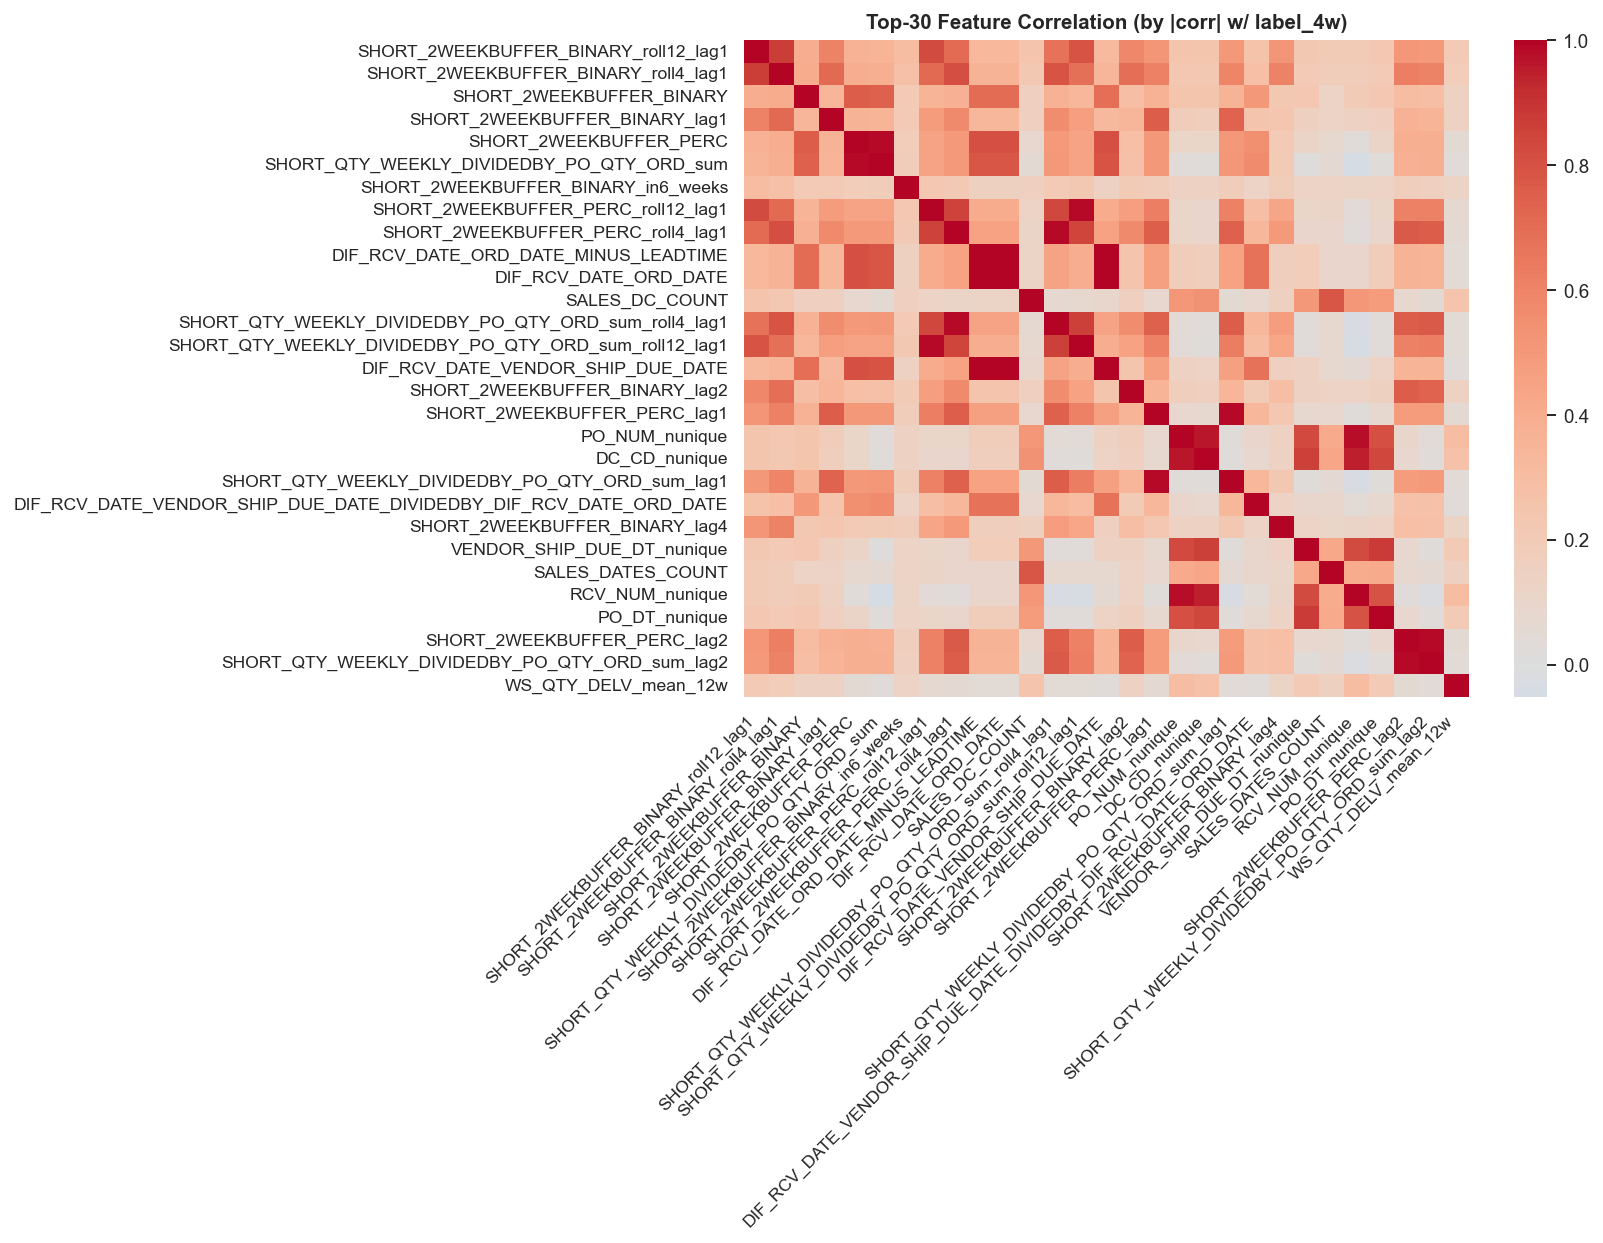

In [ ]:
# ==============================================================================
# EDA: Correlation Heatmap (Top-30 numeric features by |corr| with label_4w)
# ==============================================================================
sample = df_panel.sample(n=min(50000, len(df_panel)), random_state=42)

num_cols = sample.select_dtypes(include=[np.number]).columns.tolist()
if "label_4w" not in num_cols:
    raise ValueError("label_4w not found in df_panel. Check Section 3 output.")

corr = sample[num_cols].corr()

top = corr["label_4w"].abs().sort_values(ascending=False).head(30).index
top = [c for c in top if c != "label_4w"]

corr_subset = corr.loc[top, top]

plt.figure(figsize=(12, 9))
sns.heatmap(corr_subset, cmap="coolwarm", center=0)
plt.title("Top-30 Feature Correlation (by |corr| w/ label_4w)")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# SECTION 4: DATA PREPARATION FOR MODELING
# ==============================================================================
logger = logging.getLogger(__name__)
logger.info("Executing Section 4 (Data Preparation)...")

class DataPreparator:
    """
    Prepares feature-engineered panel for machine learning modeling.

    Key Responsibilities:
        - Temporal split (train/val/test)
        - Leakage-safe feature selection (t only uses t or earlier info)
        - Feature matrix construction with categorical handling
        - Constant-feature removal (train-only)
        - Class imbalance report
    """

    def __init__(self, target_horizon: int = 4, random_state: int = 42, drop_raw_sales: bool = True):
        """
        Args:
            target_horizon: Prediction horizon in weeks (default=4)
            random_state: Random seed
            drop_raw_sales: Whether to drop raw sales features (keep rolling only)
        """
        self.target_horizon = target_horizon
        self.target_col = f"label_{target_horizon}w"
        self.random_state = random_state
        self.drop_raw_sales = drop_raw_sales
        self.feature_cols = None
        self.categorical_cols = None
        self.numerical_cols = None
        self.constant_cols = None

    # ------------------------------------------------------------------
    # Temporal Split
    # ------------------------------------------------------------------
    def temporal_split(self, df_panel, train_frac=0.70, val_frac=0.15):
        logger.info("Step 4.1: Temporal train/validation/test split")

        df = df_panel.copy()
        df["date_monday"] = pd.to_datetime(df["date_monday"], errors="coerce")

        if self.target_col not in df.columns:
            raise ValueError(f"Target column {self.target_col} not found. Check Section 3 output.")

        before = len(df)
        df = df.dropna(subset=[self.target_col]).copy()
        dropped = before - len(df)
        logger.info(f"  Dropped rows with missing {self.target_col}: {dropped:,}")

        dates = np.sort(df["date_monday"].unique())
        if len(dates) < 10:
            raise ValueError(f"Not enough unique weeks to split: {len(dates)}")

        n = len(dates)
        train_end_idx = int(np.floor(train_frac * n)) - 1
        val_end_idx = int(np.floor((train_frac + val_frac) * n)) - 1
        train_end_idx = max(train_end_idx, 0)
        val_end_idx = max(val_end_idx, train_end_idx + 1)

        train_end_date = dates[train_end_idx]
        val_end_date = dates[val_end_idx]

        train_df = df[df["date_monday"] <= train_end_date].copy()
        val_df = df[(df["date_monday"] > train_end_date) & (df["date_monday"] <= val_end_date)].copy()
        test_df = df[df["date_monday"] > val_end_date].copy()

        logger.info(f"  Training:   {train_df['date_monday'].min().date()} to {train_df['date_monday'].max().date()} ({len(train_df):,} rows)")
        logger.info(f"  Validation: {val_df['date_monday'].min().date()} to {val_df['date_monday'].max().date()} ({len(val_df):,} rows)")
        logger.info(f"  Test:       {test_df['date_monday'].min().date()} to {test_df['date_monday'].max().date()} ({len(test_df):,} rows)")

        return train_df, val_df, test_df

    # ------------------------------------------------------------------
    # Feature Selection (Leakage Safe)
    # ------------------------------------------------------------------
    def identify_features(self, df_panel):
        logger.info("Step 4.2: Feature matrix identification (leakage-safe)")

        # Always remove IDs + labels
        exclude_cols = [
            "ITEM_NUM_CLEAN", "DIN_KEY", "date_monday",
            "FINAL_MOLECULE", "ATC_LEVEL3", "EN_FORM"
        ]
        exclude_cols += [c for c in df_panel.columns if c.startswith("label_")]

        # Leakage control for shortage-derived features
        # Keep only lagged shortage features, drop current-week
        def is_shortage_leaky(col):
            if "SHORT_" in col or "OMIT_BINARY" in col or "in6_weeks" in col:
                if "lag" in col:
                    return False
                return True
            return False

        exclude_cols += [c for c in df_panel.columns if is_shortage_leaky(c)]

        # Drop raw operational signals if configured
        if self.drop_raw_sales:
            raw_sales = [
                "QTY_ORD", "QTY_DELV", "QTY_MCS", "QTY_MCK",
                "QTY_NOT_DELV", "QTY_ISSUE_OTHER",
                "PO_QTY_ORD_sum", "RCV_QTY_ADJUSTED_sum",
                "WS_QTY_ORD", "WS_QTY_DELV", "WS_QTY_MCS", "WS_QTY_MCK"
            ]
            exclude_cols += [c for c in raw_sales if c in df_panel.columns]

        feature_cols = [c for c in df_panel.columns if c not in exclude_cols]

        categorical_cols = []
        numerical_cols = []
        for col in feature_cols:
            if df_panel[col].dtype == "object" or df_panel[col].dtype.name in ("string", "category"):
                categorical_cols.append(col)
            else:
                numerical_cols.append(col)

        self.feature_cols = feature_cols
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols

        logger.info(f"  Total features: {len(feature_cols)}")
        logger.info(f"  Categorical:    {len(categorical_cols)} {categorical_cols}")
        logger.info(f"  Numerical:      {len(numerical_cols)}")

    # ------------------------------------------------------------------
    # Feature Matrices
    # ------------------------------------------------------------------
    def prepare_features(self, train_df, val_df, test_df):
        logger.info("Step 4.3: Extract feature matrices")

        X_train = train_df[self.feature_cols].copy()
        y_train = train_df[self.target_col].copy()
        X_val = val_df[self.feature_cols].copy()
        y_val = val_df[self.target_col].copy()
        X_test = test_df[self.feature_cols].copy()
        y_test = test_df[self.target_col].copy()

        for c in self.categorical_cols:
            X_train[c] = X_train[c].fillna("UNKNOWN")
            X_val[c] = X_val[c].fillna("UNKNOWN")
            X_test[c] = X_test[c].fillna("UNKNOWN")
        for c in self.numerical_cols:
            X_train[c] = X_train[c].fillna(0)
            X_val[c] = X_val[c].fillna(0)
            X_test[c] = X_test[c].fillna(0)

        nunique = X_train.nunique(dropna=False)
        constant_cols = nunique[nunique <= 1].index.tolist()
        if constant_cols:
            X_train = X_train.drop(columns=constant_cols)
            X_val = X_val.drop(columns=constant_cols, errors="ignore")
            X_test = X_test.drop(columns=constant_cols, errors="ignore")
            self.feature_cols = [c for c in self.feature_cols if c not in constant_cols]
            self.categorical_cols = [c for c in self.categorical_cols if c not in constant_cols]
            self.numerical_cols = [c for c in self.numerical_cols if c not in constant_cols]
        self.constant_cols = constant_cols

        logger.info(f"  Dropped constant features: {len(constant_cols)}")

        for split_name, X, y in [("Train", X_train, y_train),
                                 ("Val", X_val, y_val),
                                 ("Test", X_test, y_test)]:
            num = X.select_dtypes(include=["number"])
            num_arr = num.to_numpy(dtype="float64", na_value=np.nan)
            if np.isinf(num_arr).any():
                raise ValueError(f"{split_name} features contain infinite values")
            if not y.isin([0, 1]).all():
                raise ValueError(f"{split_name} target contains non-binary values")

        logger.info(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
        logger.info(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
        logger.info(f"  X_test:  {X_test.shape}, y_test: {y_test.shape}")

        return X_train, y_train, X_val, y_val, X_test, y_test

    # ------------------------------------------------------------------
    # Class Imbalance
    # ------------------------------------------------------------------
    def analyze_imbalance(self, y_train, y_val, y_test):
        logger.info("Step 4.4: Class imbalance analysis")

        def _stats(y):
            n_pos = int((y == 1).sum())
            n_neg = int((y == 0).sum())
            rate = n_pos / len(y) if len(y) > 0 else 0
            return n_pos, n_neg, rate

        n_pos, n_neg, rate = _stats(y_train)
        logger.info(f"  Training:   {n_pos:,} positive ({rate:.4f})")

        n_pos_v, n_neg_v, rate_v = _stats(y_val)
        logger.info(f"  Validation: {n_pos_v:,} positive ({rate_v:.4f})")

        n_pos_t, n_neg_t, rate_t = _stats(y_test)
        logger.info(f"  Test:       {n_pos_t:,} positive ({rate_t:.4f})")

        scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

        return {
            "train": {"n_pos": n_pos, "n_neg": n_neg, "rate": rate},
            "val": {"n_pos": n_pos_v, "n_neg": n_neg_v, "rate": rate_v},
            "test": {"n_pos": n_pos_t, "n_neg": n_neg_t, "rate": rate_t},
            "scale_pos_weight": float(scale_pos_weight)
        }

    def run(self, df_panel):
        print("\n" + "=" * 80)
        print("SECTION 4: DATA PREPARATION FOR MODELING")
        print("=" * 80)

        train_df, val_df, test_df = self.temporal_split(df_panel)
        self.identify_features(df_panel)
        X_train, y_train, X_val, y_val, X_test, y_test = self.prepare_features(train_df, val_df, test_df)
        imbalance_report = self.analyze_imbalance(y_train, y_val, y_test)

        print("\n" + "=" * 80)
        print("SECTION 4 COMPLETE")
        print("=" * 80)
        print(f"Target: {self.target_col}")
        print(f"Features: {len(self.feature_cols)} ({len(self.categorical_cols)} categorical, {len(self.numerical_cols)} numerical)")
        print(f"Dropped constants: {len(self.constant_cols)}")
        print(f"Train samples: {len(X_train):,} (pos rate {imbalance_report['train']['rate']:.4f})")
        print(f"Val samples:   {len(X_val):,} (pos rate {imbalance_report['val']['rate']:.4f})")
        print(f"Test samples:  {len(X_test):,} (pos rate {imbalance_report['test']['rate']:.4f})")
        print("=" * 80)

        return {
            "train_df": train_df, "val_df": val_df, "test_df": test_df,
            "X_train": X_train, "y_train": y_train,
            "X_val": X_val, "y_val": y_val,
            "X_test": X_test, "y_test": y_test,
            "imbalance_report": imbalance_report,
            "feature_cols": self.feature_cols,
            "categorical_cols": self.categorical_cols,
            "numerical_cols": self.numerical_cols,
            "constant_cols": self.constant_cols
        }


preparator = DataPreparator(target_horizon=4, random_state=42, drop_raw_sales=True)
prepared_data = preparator.run(df_panel)

2026-02-19 23:18:57,929 - [INFO] - Executing Section 4 (Data Preparation)...

SECTION 4: DATA PREPARATION FOR MODELING
2026-02-19 23:18:57,931 - [INFO] - Step 4.1: Temporal train/validation/test split
2026-02-19 23:18:58,415 - [INFO] -   Dropped rows with missing label_4w: 37,788
2026-02-19 23:18:58,549 - [INFO] -   Training:   2023-07-03 to 2023-10-09 (141,705 rows)
2026-02-19 23:18:58,551 - [INFO] -   Validation: 2023-10-16 to 2023-10-30 (28,341 rows)
2026-02-19 23:18:58,552 - [INFO] -   Test:       2023-11-06 to 2023-11-27 (37,788 rows)
2026-02-19 23:18:58,562 - [INFO] - Step 4.2: Feature matrix identification (leakage-safe)
2026-02-19 23:18:58,563 - [INFO] -   Total features: 100
2026-02-19 23:18:58,563 - [INFO] -   Categorical:    8 ['ATC_LEVEL1', 'item_class_group', 'REFRG_IND', 'DATED_ITEM_IND', 'INJECTABLE_ITM_CD', 'CNTRL_DRUG_CD', 'SPEC_HNDL_CD', 'BO_TRSF_CD']
2026-02-19 23:18:58,564 - [INFO] -   Numerical:      92
2026-02-19 23:18:58,564 - [INFO] - Step 4.3: Extract feature m

date_monday
2023-08-14   0.2540
2023-08-21   0.2576
2023-08-28   0.2199
2023-09-04   0.2190
2023-09-11   0.2243
2023-09-18   0.2247
2023-09-25   0.2085
2023-10-02   0.2043
2023-10-09   0.2028
2023-10-16   0.2018
2023-10-23   0.2163
2023-10-30   0.2381
2023-11-06   0.2490
2023-11-13   0.2547
2023-11-20   0.2732
2023-11-27   0.2490
2023-12-04      NaN
2023-12-11      NaN
2023-12-18      NaN
2023-12-25      NaN
Name: label_4w, dtype: float64


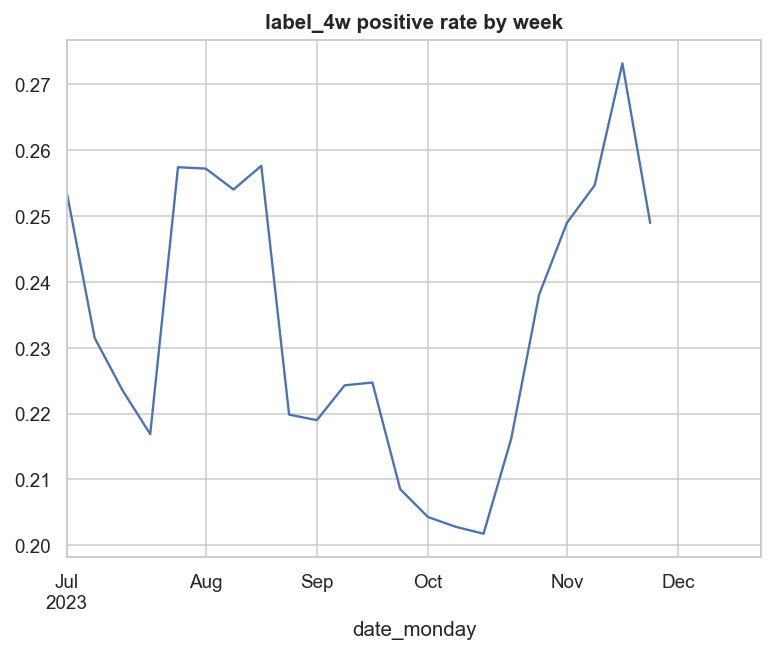

In [ ]:
tmp = df_panel.groupby("date_monday")["label_4w"].mean()
print(tmp.tail(20))
tmp.plot(title="label_4w positive rate by week")
plt.show()


In [ ]:
# ==============================================================================
# SECTION 4.5: VALIDATION CHECKS (Aligned to label_4w + lag-safe)
# ==============================================================================
print("\n" + "=" * 80)
print("SECTION 4 VALIDATION CHECKS")
print("=" * 80)

# --- unpack from prepared_data ---
train_df = prepared_data["train_df"]
val_df = prepared_data["val_df"]
test_df = prepared_data["test_df"]
X_train = prepared_data["X_train"]
X_val = prepared_data["X_val"]
X_test = prepared_data["X_test"]
y_train = prepared_data["y_train"]
y_val = prepared_data["y_val"]
y_test = prepared_data["y_test"]
feature_cols = prepared_data["feature_cols"]
categorical_cols = prepared_data["categorical_cols"]
numerical_cols = prepared_data["numerical_cols"]
imbalance_report = prepared_data["imbalance_report"]

validation_passed = True
validation_results = []

def check(condition: bool, test_name: str, details: str = "") -> bool:
    global validation_passed
    status = "PASS" if condition else "FAIL"
    symbol = "✓" if condition else "✗"
    validation_results.append({"test": test_name, "status": status, "details": details})
    print(f"{symbol} {test_name}: {status}")
    if details:
        print(f"  {details}")
    if not condition:
        validation_passed = False
    return condition

def has_inf(df):
    num = df.select_dtypes(include=["number"])
    arr = num.to_numpy(dtype="float64", na_value=np.nan)
    return np.isinf(arr).any()

# -------------------------
# 1) Temporal Integrity
# -------------------------
print("\n" + "-" * 80)
print("1. TEMPORAL INTEGRITY CHECKS")
print("-" * 80)

train_dates = pd.to_datetime(train_df["date_monday"])
val_dates = pd.to_datetime(val_df["date_monday"])
test_dates = pd.to_datetime(test_df["date_monday"])

check(train_dates.max() < val_dates.min(), "No overlap train/val",
      f"Train ends {train_dates.max().date()}, Val starts {val_dates.min().date()}")
check(val_dates.max() < test_dates.min(), "No overlap val/test",
      f"Val ends {val_dates.max().date()}, Test starts {test_dates.min().date()}")

# -------------------------
# 2) Feature Matrix Checks
# -------------------------
print("\n" + "-" * 80)
print("2. FEATURE MATRIX CHECKS")
print("-" * 80)

check(list(X_train.columns) == list(X_val.columns) == list(X_test.columns),
      "Identical feature columns across splits")

check(X_train.isnull().sum().sum() == 0, "No NaN in X_train")
check(X_val.isnull().sum().sum() == 0, "No NaN in X_val")
check(X_test.isnull().sum().sum() == 0, "No NaN in X_test")

check(not has_inf(X_train), "No inf in X_train")
check(not has_inf(X_val), "No inf in X_val")
check(not has_inf(X_test), "No inf in X_test")

# -------------------------
# 3) Target Checks
# -------------------------
print("\n" + "-" * 80)
print("3. TARGET CHECKS")
print("-" * 80)

check(y_train.isin([0, 1]).all(), "y_train binary")
check(y_val.isin([0, 1]).all(), "y_val binary")
check(y_test.isin([0, 1]).all(), "y_test binary")

# -------------------------
# 4) Leakage Checks (allow lag only)
# -------------------------
print("\n" + "-" * 80)
print("4. LEAKAGE CHECKS")
print("-" * 80)

leak_patterns = ["SHORT_", "OMIT_BINARY", "in6_weeks", "label_"]
leak_cols = [c for c in X_train.columns if any(p in c for p in leak_patterns) and ("lag" not in c)]
check(len(leak_cols) == 0, "No label/leakage columns in features",
      f"Found: {leak_cols}")

# -------------------------
# 5) External Signal Checks
# -------------------------
print("\n" + "-" * 80)
print("5. EXTERNAL SIGNAL CHECKS")
print("-" * 80)

external_cols = [c for c in X_train.columns if c in ["COMPOSITE_INDEX"] or "CPI" in c or "FLU" in c or "FLUNET" in c]
if external_cols:
    check(X_train[external_cols].isnull().sum().sum() == 0, "External signal columns have no NaN",
          f"Columns: {external_cols}")
else:
    print("No external signal features detected; skipping.")

# -------------------------
# 6) Feature Categorization
# -------------------------
print("\n" + "-" * 80)
print("6. FEATURE CATEGORIZATION CHECKS")
print("-" * 80)

check(len(categorical_cols) > 0, "Categorical features identified", f"Count: {len(categorical_cols)}")
check(len(numerical_cols) > 0, "Numerical features identified", f"Count: {len(numerical_cols)}")
check(len(categorical_cols) + len(numerical_cols) == len(feature_cols),
      "All features categorized",
      f"Cat={len(categorical_cols)}, Num={len(numerical_cols)}, Total={len(feature_cols)}")

# -------------------------
# SUMMARY
# -------------------------
print("\n" + "=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)

passed_count = sum(1 for r in validation_results if r["status"] == "PASS")
total_count = len(validation_results)

print(f"Passed: {passed_count}/{total_count}")
print(f"Status: {'ALL CHECKS PASSED' if validation_passed else 'SOME CHECKS FAILED'}")

if not validation_passed:
    print("\nFailed checks:")
    for r in validation_results:
        if r["status"] == "FAIL":
            print(f"  - {r['test']}")
            if r["details"]:
                print(f"    {r['details']}")


SECTION 4 VALIDATION CHECKS

--------------------------------------------------------------------------------
1. TEMPORAL INTEGRITY CHECKS
--------------------------------------------------------------------------------
✓ No overlap train/val: PASS
  Train ends 2023-10-09, Val starts 2023-10-16
✓ No overlap val/test: PASS
  Val ends 2023-10-30, Test starts 2023-11-06

--------------------------------------------------------------------------------
2. FEATURE MATRIX CHECKS
--------------------------------------------------------------------------------
✓ Identical feature columns across splits: PASS
✓ No NaN in X_train: PASS
✓ No NaN in X_val: PASS
✓ No NaN in X_test: PASS
✓ No inf in X_train: PASS
✓ No inf in X_val: PASS
✓ No inf in X_test: PASS

--------------------------------------------------------------------------------
3. TARGET CHECKS
--------------------------------------------------------------------------------
✓ y_train binary: PASS
✓ y_val binary: PASS
✓ y_test binary: PA

In [ ]:
# ==============================================================================
# SECTION 5: BASELINE MODELS 
# ==============================================================================
logger = logging.getLogger(__name__)
logger.info("Executing Section 5 (Baseline Models)...")

# --- unpack prepared data ---
X_train = prepared_data["X_train"]
y_train = prepared_data["y_train"]
X_val = prepared_data["X_val"]
y_val = prepared_data["y_val"]
categorical_cols = prepared_data["categorical_cols"]

class ModelEvaluatorSimple:
    def compute_metrics(self, y_true, y_pred, y_prob, model_name):
        metrics = {
            "model_name": model_name,
            "pr_auc": None,
            "roc_auc": None,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        }

        # AUC only valid when both classes exist
        if len(np.unique(y_true)) >= 2:
            precision, recall, _ = precision_recall_curve(y_true, y_prob)
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            metrics["pr_auc"] = auc(recall, precision)
            metrics["roc_auc"] = auc(fpr, tpr)
        return metrics

    def generate_table(self, metrics_list):
        return pd.DataFrame([{
            "Model": m["model_name"],
            "PR-AUC": f"{m['pr_auc']:.4f}" if m["pr_auc"] is not None else "NA",
            "ROC-AUC": f"{m['roc_auc']:.4f}" if m["roc_auc"] is not None else "NA",
            "Precision": f"{m['precision']:.4f}",
            "Recall": f"{m['recall']:.4f}",
            "F1": f"{m['f1']:.4f}",
        } for m in metrics_list])

evaluator = ModelEvaluatorSimple()

class MajorityClassBaseline:
    def __init__(self):
        self.name = "Majority Class"
        self.majority_class = 0
    def fit(self, X, y):
        self.majority_class = int(y.mode()[0])
    def predict_proba(self, X):
        n = len(X)
        proba = np.zeros((n, 2))
        proba[:, self.majority_class] = 1.0
        return proba
    def predict(self, X):
        return np.full(len(X), self.majority_class)

class RandomBaseline:
    def __init__(self):
        self.name = "Random (Stratified)"
        self.positive_rate = 0.5
    def fit(self, X, y):
        self.positive_rate = float(y.mean())
    def predict_proba(self, X):
        n = len(X)
        p = np.full(n, self.positive_rate)
        return np.column_stack([1-p, p])
    def predict(self, X):
        np.random.seed(42)
        return np.random.binomial(1, self.positive_rate, size=len(X))

class LogisticRegressionBaseline:
    def __init__(self):
        self.name = "Logistic Regression"
        self.model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
        self.label_encoders = {}

    def fit(self, X, y):
        X_enc = X.copy()
        for col in X_enc.columns:
            if X_enc[col].dtype == "object" or X_enc[col].dtype.name == "string":
                le = LabelEncoder()
                X_enc[col] = le.fit_transform(X_enc[col].astype(str))
                self.label_encoders[col] = le
        self.model.fit(X_enc, y)

    def predict_proba(self, X):
        X_enc = X.copy()
        for col in X_enc.columns:
            if col in self.label_encoders:
                le = self.label_encoders[col]
                X_enc[col] = X_enc[col].astype(str).map(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )
        return self.model.predict_proba(X_enc)

    def predict(self, X):
        X_enc = X.copy()
        for col in X_enc.columns:
            if col in self.label_encoders:
                le = self.label_encoders[col]
                X_enc[col] = X_enc[col].astype(str).map(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )
        return self.model.predict(X_enc)

print("\n" + "=" * 80)
print("SECTION 5: BASELINE MODELS")
print("=" * 80)

models = [MajorityClassBaseline(), RandomBaseline(), LogisticRegressionBaseline()]
metrics_list = []

for m in models:
    m.fit(X_train, y_train)
    y_prob = m.predict_proba(X_val)[:, 1]
    y_pred = m.predict(X_val)
    metrics = evaluator.compute_metrics(y_val.values, y_pred, y_prob, m.name)
    metrics_list.append(metrics)

    print(f"\n{m.name}")
    print(f"  PR-AUC: {metrics['pr_auc']:.4f}" if metrics["pr_auc"] is not None else "  PR-AUC: NA")
    print(f"  ROC-AUC:{metrics['roc_auc']:.4f}" if metrics["roc_auc"] is not None else "  ROC-AUC: NA")
    print(f"  F1:     {metrics['f1']:.4f}")

print("\nComparison Table:")
print(evaluator.generate_table(metrics_list).to_string(index=False))

2026-02-19 23:18:59,333 - [INFO] - Executing Section 5 (Baseline Models)...

SECTION 5: BASELINE MODELS

Majority Class
  PR-AUC: 0.6093
  ROC-AUC:0.5000
  F1:     0.0000

Random (Stratified)
  PR-AUC: 0.6093
  ROC-AUC:0.5000
  F1:     0.2219

Logistic Regression
  PR-AUC: 0.5125
  ROC-AUC:0.7518
  F1:     0.4958

Comparison Table:
              Model PR-AUC ROC-AUC Precision Recall     F1
     Majority Class 0.6093  0.5000    0.0000 0.0000 0.0000
Random (Stratified) 0.6093  0.5000    0.2167 0.2273 0.2219
Logistic Regression 0.5125  0.7518    0.4053 0.6383 0.4958


In [ ]:
# ==============================================================================
# SECTION 6: TRADITIONAL ML MODELS (TREE-BASED + CATBOOST)
# ==============================================================================
logger = logging.getLogger(__name__)
logger.info("Executing Section 6 (Traditional ML Models)...")

# ------------------------------------------------------------------------------
# Optional Dependencies
# ------------------------------------------------------------------------------
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    logger.warning("LightGBM not available. Install with: pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    logger.warning("CatBoost not available. Install with: pip install catboost")

# ------------------------------------------------------------------------------
# Evaluation Utilities
# ------------------------------------------------------------------------------
class ModelEvaluator:
    """
    Metrics with safe handling of single-class cases,
    threshold tuning on validation set,
    and consistent reporting.
    """
    @staticmethod
    def _safe_pr_auc(y_true, y_prob):
        if len(np.unique(y_true)) < 2:
            return np.nan
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        return auc(recall, precision)

    @staticmethod
    def _safe_roc_auc(y_true, y_prob):
        if len(np.unique(y_true)) < 2:
            return np.nan
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        return auc(fpr, tpr)

    @staticmethod
    def best_threshold_f1(y_true, y_prob):
        precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
        if thresholds is None or len(thresholds) == 0:
            return 0.5
        f1_scores = []
        for p, r in zip(precision[:-1], recall[:-1]):
            if (p + r) == 0:
                f1_scores.append(0.0)
            else:
                f1_scores.append(2 * p * r / (p + r))
        best_idx = int(np.argmax(f1_scores))
        return float(thresholds[best_idx])

    def compute_metrics(self, y_true, y_prob, threshold, model_name):
        y_pred = (y_prob >= threshold).astype(int)

        metrics = {
            "model_name": model_name,
            "threshold": threshold,
            "pr_auc": self._safe_pr_auc(y_true, y_prob),
            "roc_auc": self._safe_roc_auc(y_true, y_prob),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        }

        if len(np.unique(y_true)) == 2:
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        else:
            tn = fp = fn = tp = 0

        metrics["confusion_matrix"] = {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
        metrics["coverage_rate"] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        metrics["false_alarm_rate"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        return metrics

# ------------------------------------------------------------------------------
# Feature Encoder (for tree models except CatBoost)
# ------------------------------------------------------------------------------
class FeatureEncoder:
    """
    Label-encode categorical columns with stable mapping.
    Unseen categories -> -1.
    """
    def __init__(self):
        self.maps = {}

    def fit(self, X, categorical_cols):
        for col in categorical_cols:
            values = pd.Series(X[col].astype(str).fillna("UNKNOWN")).unique()
            self.maps[col] = {v: i for i, v in enumerate(values)}

    def transform(self, X, categorical_cols):
        X_enc = X.copy()
        for col in categorical_cols:
            mapping = self.maps[col]
            X_enc[col] = (
                X_enc[col].astype(str)
                .fillna("UNKNOWN")
                .map(lambda v: mapping.get(v, -1))
                .astype(int)
            )
        return X_enc

# ------------------------------------------------------------------------------
# Model Wrappers
# ------------------------------------------------------------------------------
class XGBoostModel:
    def __init__(self, scale_pos_weight):
        self.name = "XGBoost"
        self.model = xgb.XGBClassifier(
            max_depth=6,
            learning_rate=0.05,
            n_estimators=400,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        )

    def fit(self, X, y, X_val=None, y_val=None):
        if X_val is not None:
            self.model.fit(
                X, y,
                eval_set=[(X_val, y_val)],
                verbose=False
            )
        else:
            self.model.fit(X, y)

    def predict_proba(self, X):
        return self.model.predict_proba(X)[:, 1]

    def get_feature_importance(self, feature_names):
        return pd.DataFrame(
            {"feature": feature_names, "importance": self.model.feature_importances_}
        ).sort_values("importance", ascending=False)

class RandomForestModel:
    def __init__(self):
        self.name = "Random Forest"
        self.model = RandomForestClassifier(
            n_estimators=300,
            max_depth=20,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict_proba(self, X):
        return self.model.predict_proba(X)[:, 1]

    def get_feature_importance(self, feature_names):
        return pd.DataFrame(
            {"feature": feature_names, "importance": self.model.feature_importances_}
        ).sort_values("importance", ascending=False)

class LightGBMModel:
    def __init__(self, scale_pos_weight):
        self.name = "LightGBM"
        self.model = lgb.LGBMClassifier(
            num_leaves=31,
            learning_rate=0.05,
            n_estimators=400,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            class_weight={0: 1.0, 1: scale_pos_weight},
            n_jobs=-1
        )

    def fit(self, X, y, X_val=None, y_val=None):
        if X_val is not None:
            self.model.fit(
                X, y,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )
        else:
            self.model.fit(X, y)

    def predict_proba(self, X):
        return self.model.predict_proba(X)[:, 1]

    def get_feature_importance(self, feature_names):
        return pd.DataFrame(
            {"feature": feature_names, "importance": self.model.feature_importances_}
        ).sort_values("importance", ascending=False)

class CatBoostModel:
    def __init__(self, scale_pos_weight):
        self.name = "CatBoost"
        self.model = CatBoostClassifier(
            depth=8,
            learning_rate=0.05,
            iterations=500,
            loss_function="Logloss",
            eval_metric="PRAUC",
            random_seed=42,
            class_weights=[1.0, scale_pos_weight],
            verbose=False,
            od_type="Iter",
            od_wait=50
        )

    def fit(self, X, y, X_val=None, y_val=None, cat_features=None):
        if X_val is not None:
            self.model.fit(
                X, y,
                eval_set=(X_val, y_val),
                cat_features=cat_features,
                verbose=False,
                use_best_model=True
            )
        else:
            self.model.fit(X, y, cat_features=cat_features, verbose=False)

    def predict_proba(self, X):
        return self.model.predict_proba(X)[:, 1]

    def get_feature_importance(self, feature_names):
        imp = self.model.get_feature_importance()
        return pd.DataFrame({"feature": feature_names, "importance": imp}).sort_values("importance", ascending=False)

# ------------------------------------------------------------------------------
# EXECUTION
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("SECTION 6: TRADITIONAL ML MODELS (TREE-BASED + CATBOOST)")
print("=" * 80)

X_train = prepared_data["X_train"]
y_train = prepared_data["y_train"]
X_val = prepared_data["X_val"]
y_val = prepared_data["y_val"]
X_test = prepared_data["X_test"]
y_test = prepared_data["y_test"]
categorical_cols = prepared_data["categorical_cols"]
imbalance_report = prepared_data["imbalance_report"]

scale_pos_weight = imbalance_report["scale_pos_weight"]

if len(X_train) == 0 or len(X_val) == 0:
    raise ValueError("Empty train/val split detected. Check Section 4 output.")

# Encode for tree-based models
encoder = FeatureEncoder()
encoder.fit(X_train, categorical_cols)
X_train_enc = encoder.transform(X_train, categorical_cols)
X_val_enc = encoder.transform(X_val, categorical_cols)
X_test_enc = encoder.transform(X_test, categorical_cols)

# Raw for CatBoost (string categorical)
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()
for col in categorical_cols:
    X_train_cb[col] = X_train_cb[col].astype(str).fillna("UNKNOWN")
    X_val_cb[col] = X_val_cb[col].astype(str).fillna("UNKNOWN")
    X_test_cb[col] = X_test_cb[col].astype(str).fillna("UNKNOWN")

cat_features_idx = [X_train_cb.columns.get_loc(c) for c in categorical_cols if c in X_train_cb.columns]

models = []
if XGBOOST_AVAILABLE:
    models.append(XGBoostModel(scale_pos_weight))
models.append(RandomForestModel())
if LIGHTGBM_AVAILABLE:
    models.append(LightGBMModel(scale_pos_weight))
if CATBOOST_AVAILABLE:
    models.append(CatBoostModel(scale_pos_weight))

evaluator = ModelEvaluator()
metrics_val = []
metrics_test = []

print("\nStep 6.1: Training + Validation (threshold tuned on val)")
for model in models:
    print(f"\nTraining: {model.name}")
    start = time.time()

    if model.name == "CatBoost":
        model.fit(X_train_cb, y_train, X_val_cb, y_val, cat_features=cat_features_idx)
        y_val_prob = model.predict_proba(X_val_cb)
    elif model.name in ["XGBoost", "LightGBM"]:
        model.fit(X_train_enc, y_train, X_val_enc, y_val)
        y_val_prob = model.predict_proba(X_val_enc)
    else:
        model.fit(X_train_enc, y_train)
        y_val_prob = model.predict_proba(X_val_enc)

    elapsed = time.time() - start

    best_th = evaluator.best_threshold_f1(y_val.values, y_val_prob)

    m_val = evaluator.compute_metrics(y_val.values, y_val_prob, best_th, model.name)
    m_val["train_time_sec"] = float(elapsed)
    metrics_val.append(m_val)

    print(f"  Train time: {elapsed:.1f}s")
    print(f"  Best threshold (val F1): {best_th:.4f}")
    print(f"  PR-AUC:     {m_val['pr_auc']:.4f}")
    print(f"  ROC-AUC:    {m_val['roc_auc']:.4f}")
    print(f"  Precision:  {m_val['precision']:.4f}")
    print(f"  Recall:     {m_val['recall']:.4f}")
    print(f"  F1:         {m_val['f1']:.4f}")

    if model.name == "CatBoost":
        y_test_prob = model.predict_proba(X_test_cb)
    elif model.name in ["XGBoost", "LightGBM"]:
        y_test_prob = model.predict_proba(X_test_enc)
    else:
        y_test_prob = model.predict_proba(X_test_enc)

    m_test = evaluator.compute_metrics(y_test.values, y_test_prob, best_th, model.name)
    metrics_test.append(m_test)

print("\nStep 6.2: Summary Tables")
df_val = pd.DataFrame(metrics_val)
df_test = pd.DataFrame(metrics_test)

print("\nValidation Metrics")
print(df_val[["model_name", "threshold", "pr_auc", "roc_auc", "precision", "recall", "f1"]].to_string(index=False))

print("\nTest Metrics (threshold fixed from val)")
print(df_test[["model_name", "threshold", "pr_auc", "roc_auc", "precision", "recall", "f1"]].to_string(index=False))

print("\nStep 6.3: Feature Importance (Top 20)")
for model in models:
    if hasattr(model, "get_feature_importance"):
        if model.name == "CatBoost":
            imp = model.get_feature_importance(X_train_cb.columns)
        else:
            imp = model.get_feature_importance(X_train_enc.columns)
        print(f"\n{model.name} - Top 20 Features")
        print(imp.head(20).to_string(index=False))

print("\n" + "=" * 80)
print("SECTION 6 COMPLETE")
print("=" * 80)

2026-02-19 23:26:48,667 - [INFO] - Executing Section 6 (Traditional ML Models)...

SECTION 6: TRADITIONAL ML MODELS (TREE-BASED + CATBOOST)

Step 6.1: Training + Validation (threshold tuned on val)

Training: XGBoost
  Train time: 6.0s
  Best threshold (val F1): 0.4954
  PR-AUC:     0.6413
  ROC-AUC:    0.8317
  Precision:  0.5302
  Recall:     0.6428
  F1:         0.5811

Training: Random Forest
  Train time: 25.0s
  Best threshold (val F1): 0.3352
  PR-AUC:     0.6590
  ROC-AUC:    0.8478
  Precision:  0.5598
  Recall:     0.6655
  F1:         0.6081

Training: LightGBM
[LightGBM] [Info] Number of positive: 32643, number of negative: 109062
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13752
[LightGBM] [Info] Number of data points in the train set: 141705, number of used feature

In [ ]:
# ==============================================================================
# SECTION 7: HYPERPARAMETER TUNING WITH OPTUNA (XGB / LGB / RF / CATBOOST)
# ==============================================================================
logger = logging.getLogger(__name__)
logger.info("Executing Section 7 (Hyperparameter Tuning)...")

# --- unpack data ---
X_train = prepared_data["X_train"]
y_train = prepared_data["y_train"]
X_val = prepared_data["X_val"]
y_val = prepared_data["y_val"]
categorical_cols = prepared_data["categorical_cols"]
imbalance_report = prepared_data["imbalance_report"]

scale_pos_weight = imbalance_report["scale_pos_weight"]

# ------------------------------------------------------------------------------
# Feature Encoder (for tree models except CatBoost)
# ------------------------------------------------------------------------------
class FeatureEncoder:
    """
    Label-encode categorical columns with stable mapping.
    Unseen categories -> -1.
    """
    def __init__(self):
        self.maps = {}

    def fit(self, X, categorical_cols):
        for col in categorical_cols:
            values = pd.Series(X[col].astype(str).fillna("UNKNOWN")).unique()
            self.maps[col] = {v: i for i, v in enumerate(values)}

    def transform(self, X, categorical_cols):
        X_enc = X.copy()
        for col in categorical_cols:
            mapping = self.maps[col]
            X_enc[col] = (
                X_enc[col].astype(str)
                .fillna("UNKNOWN")
                .map(lambda v: mapping.get(v, -1))
                .astype(int)
            )
        return X_enc

# --- encode for tree models ---
encoder = FeatureEncoder()
encoder.fit(X_train, categorical_cols)
X_train_encoded = encoder.transform(X_train, categorical_cols)
X_val_encoded = encoder.transform(X_val, categorical_cols)

# --- raw for catboost ---
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
for col in categorical_cols:
    X_train_cb[col] = X_train_cb[col].astype(str).fillna("UNKNOWN")
    X_val_cb[col] = X_val_cb[col].astype(str).fillna("UNKNOWN")

cat_features_idx = [X_train_cb.columns.get_loc(c) for c in categorical_cols if c in X_train_cb.columns]

# ------------------------------------------------------------------------------
# Optuna Optimizer
# ------------------------------------------------------------------------------
class OptunaOptimizer:
    def __init__(self, model_type, n_trials=20, random_state=42):
        self.model_type = model_type
        self.n_trials = n_trials
        self.random_state = random_state

    @staticmethod
    def _safe_pr_auc(y_true, y_prob):
        if len(np.unique(y_true)) < 2:
            return 0.0
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        return auc(recall, precision)

    def optimize(self):
        sampler = TPESampler(seed=self.random_state)
        study = optuna.create_study(direction="maximize", sampler=sampler)

        if self.model_type == "xgboost":
            def objective(trial):
                params = {
                    "max_depth": trial.suggest_int("max_depth", 3, 8),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                    "n_estimators": trial.suggest_int("n_estimators", 50, 300),
                    "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                    "scale_pos_weight": scale_pos_weight,
                    "eval_metric": "aucpr",
                    "random_state": 42,
                    "n_jobs": -1
                }
                model = xgb.XGBClassifier(**params)
                model.fit(X_train_encoded, y_train, eval_set=[(X_val_encoded, y_val)], verbose=False)
                y_prob = model.predict_proba(X_val_encoded)[:, 1]
                return self._safe_pr_auc(y_val, y_prob)

        elif self.model_type == "lightgbm":
            def objective(trial):
                params = {
                    "num_leaves": trial.suggest_int("num_leaves", 20, 100),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                    "n_estimators": trial.suggest_int("n_estimators", 50, 300),
                    "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                    "class_weight": {0: 1.0, 1: scale_pos_weight},
                    "random_state": 42,
                    "n_jobs": -1,
                    "verbose": -1
                }
                model = lgb.LGBMClassifier(**params)
                model.fit(X_train_encoded, y_train, eval_set=[(X_val_encoded, y_val)],
                          callbacks=[lgb.early_stopping(15, verbose=False)])
                y_prob = model.predict_proba(X_val_encoded)[:, 1]
                return self._safe_pr_auc(y_val, y_prob)

        elif self.model_type == "randomforest":
            def objective(trial):
                params = {
                    "n_estimators": trial.suggest_int("n_estimators", 50, 200),
                    "max_depth": trial.suggest_int("max_depth", 10, 25),
                    "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
                    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
                    "class_weight": "balanced",
                    "random_state": 42,
                    "n_jobs": -1
                }
                model = RandomForestClassifier(**params)
                model.fit(X_train_encoded, y_train)
                y_prob = model.predict_proba(X_val_encoded)[:, 1]
                return self._safe_pr_auc(y_val, y_prob)

        elif self.model_type == "catboost":
            def objective(trial):
                params = {
                    "depth": trial.suggest_int("depth", 6, 10),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                    "iterations": trial.suggest_int("iterations", 200, 600),
                    "loss_function": "Logloss",
                    "eval_metric": "PRAUC",
                    "random_seed": 42,
                    "verbose": False,
                    "class_weights": [1.0, scale_pos_weight]
                }
                model = CatBoostClassifier(**params)
                model.fit(X_train_cb, y_train, eval_set=(X_val_cb, y_val),
                          cat_features=cat_features_idx, verbose=False)
                y_prob = model.predict_proba(X_val_cb)[:, 1]
                return self._safe_pr_auc(y_val, y_prob)

        else:
            raise ValueError(f"Unknown model_type: {self.model_type}")

        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        return study.best_params, study.best_value

# ------------------------------------------------------------------------------
# Train Tuned Model
# ------------------------------------------------------------------------------
def train_tuned_model(model_type, best_params):
    if model_type == "xgboost":
        best_params.update({
            "scale_pos_weight": scale_pos_weight,
            "eval_metric": "aucpr",
            "random_state": 42,
            "n_jobs": -1
        })
        model = xgb.XGBClassifier(**best_params)
        model.fit(X_train_encoded, y_train, eval_set=[(X_val_encoded, y_val)], verbose=False)

    elif model_type == "lightgbm":
        best_params.update({
            "class_weight": {0: 1.0, 1: scale_pos_weight},
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1
        })
        model = lgb.LGBMClassifier(**best_params)
        model.fit(X_train_encoded, y_train, eval_set=[(X_val_encoded, y_val)],
                  callbacks=[lgb.early_stopping(15, verbose=False)])

    elif model_type == "randomforest":
        best_params.update({
            "class_weight": "balanced",
            "random_state": 42,
            "n_jobs": -1
        })
        model = RandomForestClassifier(**best_params)
        model.fit(X_train_encoded, y_train)

    elif model_type == "catboost":
        best_params.update({
            "loss_function": "Logloss",
            "eval_metric": "PRAUC",
            "random_seed": 42,
            "verbose": False,
            "class_weights": [1.0, scale_pos_weight]
        })
        model = CatBoostClassifier(**best_params)
        model.fit(X_train_cb, y_train, eval_set=(X_val_cb, y_val),
                  cat_features=cat_features_idx, verbose=False)

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    return model

# ------------------------------------------------------------------------------
# EXECUTION
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("SECTION 7: HYPERPARAMETER TUNING")
print("=" * 80)

configs = [
    ("xgboost", 20),
    ("lightgbm", 20),
    ("randomforest", 5),
    ("catboost", 15)
]

tuned_models = {}
tuning_results = {}

# output dir
out_dir = Config.OUTPUT_DIR / "models" / "baselines"
out_dir.mkdir(parents=True, exist_ok=True)

for model_type, trials in configs:
    if model_type == "lightgbm" and not LIGHTGBM_AVAILABLE:
        print("\nLightGBM not available, skipping.")
        continue
    if model_type == "catboost" and not CATBOOST_AVAILABLE:
        print("\nCatBoost not available, skipping.")
        continue

    print(f"\nOptimizing {model_type} ({trials} trials)")
    optimizer = OptunaOptimizer(model_type, n_trials=trials)
    best_params, best_score = optimizer.optimize()

    print(f"  Best PR-AUC: {best_score:.4f}")
    print("  Best params:")
    for k, v in best_params.items():
        print(f"    {k}: {v}")

    print("  Training tuned model...")
    tuned_model = train_tuned_model(model_type, best_params)

    tuned_models[model_type] = tuned_model
    tuning_results[model_type] = {
        "best_params": best_params,
        "best_score": best_score
    }

    with open(out_dir / f"{model_type}_tuned_params.json", "w") as f:
        json.dump(best_params, f, indent=2)

globals()["tuned_models"] = tuned_models

print("\n" + "=" * 80)
print("SECTION 7 COMPLETE")
print("=" * 80)
print("Tuned models:", list(tuned_models.keys()))

2026-02-19 23:28:14,238 - [INFO] - Executing Section 7 (Hyperparameter Tuning)...


[I 2026-02-19 23:28:15,063] A new study created in memory with name: no-name-a5e5d436-4efb-4a1a-b3be-e05ebefa9ce8



SECTION 7: HYPERPARAMETER TUNING

Optimizing xgboost (20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-19 23:28:18,338] Trial 0 finished with value: 0.6306746953438807 and parameters: {'max_depth': 5, 'learning_rate': 0.17254716573280354, 'n_estimators': 233, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.6306746953438807.
[I 2026-02-19 23:28:21,606] Trial 1 finished with value: 0.6039396489820782 and parameters: {'max_depth': 3, 'learning_rate': 0.011900590783184251, 'n_estimators': 267, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184182}. Best is trial 0 with value: 0.6306746953438807.
[I 2026-02-19 23:28:24,707] Trial 2 finished with value: 0.6220947542538252 and parameters: {'max_depth': 3, 'learning_rate': 0.1827602783178572, 'n_estimators': 258, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402}. Best is trial 0 with value: 0.6306746953438807.
[I 2026-02-19 23:28:27,246] Trial 3 finished with value: 0.615039252963202 and parameters: {'max_depth': 4, 'learning_rate': 0.024

...

[I 2026-02-19 23:31:14,677] Trial 0 finished with value: 0.657816594210773 and parameters: {'n_estimators': 106, 'max_depth': 25, 'min_samples_split': 12, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.657816594210773.
[I 2026-02-19 23:31:19,277] Trial 1 finished with value: 0.6307832808367722 and parameters: {'n_estimators': 73, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.657816594210773.
[I 2026-02-19 23:31:30,958] Trial 2 finished with value: 0.6513161976564894 and parameters: {'n_estimators': 140, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.657816594210773.
[I 2026-02-19 23:31:43,632] Trial 3 finished with value: 0.6335322634220028 and parameters: {'n_estimators': 175, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.657816594210773.
[I 2026-02-19 23:31:51,914] Trial 4 finished with value: 0.6510006674412065 and parameters: {'n_e

[I 2026-02-19 23:32:01,290] A new study created in memory with name: no-name-1b3806a2-a063-4ab0-9db8-3254bb2f7730



Optimizing catboost (15 trials)


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-02-19 23:32:46,160] Trial 0 finished with value: 0.6406579457757209 and parameters: {'depth': 7, 'learning_rate': 0.17254716573280354, 'iterations': 493}. Best is trial 0 with value: 0.6406579457757209.
[I 2026-02-19 23:33:12,938] Trial 1 finished with value: 0.6190540828879648 and parameters: {'depth': 8, 'learning_rate': 0.015958237752949748, 'iterations': 262}. Best is trial 0 with value: 0.6406579457757209.
[I 2026-02-19 23:33:48,153] Trial 2 finished with value: 0.6375439961342155 and parameters: {'depth': 6, 'learning_rate': 0.13394334706750485, 'iterations': 441}. Best is trial 0 with value: 0.6406579457757209.
[I 2026-02-19 23:34:58,867] Trial 3 finished with value: 0.6295001709496579 and parameters: {'depth': 9, 'learning_rate': 0.010636066512540286, 'iterations': 588}. Best is trial 0 with value: 0.6406579457757209.
[I 2026-02-19 23:35:44,197] Trial 4 finished with value: 0.6296588721692093 and parameters: {'depth': 10, 'learning_rate': 0.018891200276189398, 'iteratio

In [ ]:
# ==============================================================================
# SECTION 8: THRESHOLD OPTIMIZATION (TUNED MODELS)
# ==============================================================================
logger = logging.getLogger(__name__)
logger.info("Executing Section 8 (Threshold Optimization)...")

# ------------------------------------------------------------------------------
# Feature Encoder (same logic as Section 7)
# ------------------------------------------------------------------------------
class FeatureEncoder:
    """
    Label-encode categorical columns with stable mapping.
    Unseen categories -> -1.
    """
    def __init__(self):
        self.maps = {}

    def fit(self, X, categorical_cols):
        for col in categorical_cols:
            values = pd.Series(X[col].astype(str).fillna("UNKNOWN")).unique()
            self.maps[col] = {v: i for i, v in enumerate(values)}

    def transform(self, X, categorical_cols):
        X_enc = X.copy()
        for col in categorical_cols:
            mapping = self.maps[col]
            X_enc[col] = (
                X_enc[col].astype(str)
                .fillna("UNKNOWN")
                .map(lambda v: mapping.get(v, -1))
                .astype(int)
            )
        return X_enc

# ------------------------------------------------------------------------------
# Threshold Optimizer
# ------------------------------------------------------------------------------
class ThresholdOptimizer:
    def __init__(self, output_dir: Path):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def find_optimal_threshold(self, y_true, y_prob, strategy="f1", min_precision=0.20, min_recall=0.60):
        precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
        if thresholds is None or len(thresholds) == 0:
            thr = 0.5
            y_pred = (y_prob >= thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            return {
                "threshold": float(thr),
                "precision": float(precision_score(y_true, y_pred, zero_division=0)),
                "recall": float(recall_score(y_true, y_pred, zero_division=0)),
                "f1": float(f1_score(y_true, y_pred, zero_division=0)),
                "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
                "strategy": strategy
            }

        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

        if strategy == "f1":
            best_idx = int(np.argmax(f1_scores))
        elif strategy == "recall_constrained":
            valid = precision >= min_precision
            best_idx = np.where(valid)[0][int(np.argmax(recall[valid]))] if valid.sum() else int(np.argmax(f1_scores))
        elif strategy == "precision_constrained":
            valid = recall >= min_recall
            best_idx = np.where(valid)[0][int(np.argmax(precision[valid]))] if valid.sum() else int(np.argmax(f1_scores))
        else:
            raise ValueError("Unknown strategy")

        thr = thresholds[min(best_idx, len(thresholds) - 1)]
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        return {
            "threshold": float(thr),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "strategy": strategy
        }

    def scan_thresholds(self, y_true, y_prob, thresholds):
        rows = []
        for t in thresholds:
            y_pred = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            rows.append({
                "Threshold": t,
                "Precision": precision_score(y_true, y_pred, zero_division=0),
                "Recall": recall_score(y_true, y_pred, zero_division=0),
                "F1": f1_score(y_true, y_pred, zero_division=0),
                "TP": tp, "FP": fp, "FN": fn, "TN": tn
            })
        return pd.DataFrame(rows)

# ------------------------------------------------------------------------------
# EXECUTION
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("SECTION 8: THRESHOLD OPTIMIZATION (TUNED MODELS)")
print("=" * 80)

if "tuned_models" not in globals() or not tuned_models:
    raise RuntimeError("tuned_models not found. Run Section 7 first.")

# --- unpack data ---
X_train = prepared_data["X_train"]
y_train = prepared_data["y_train"]
X_val = prepared_data["X_val"]
y_val = prepared_data["y_val"]
categorical_cols = prepared_data["categorical_cols"]

# --- encode (if not already in scope) ---
encoder = FeatureEncoder()
encoder.fit(X_train, categorical_cols)
X_val_encoded = encoder.transform(X_val, categorical_cols)

# --- raw for catboost ---
X_val_cb = X_val.copy()
for col in categorical_cols:
    X_val_cb[col] = X_val_cb[col].astype(str).fillna("UNKNOWN")

# --- output dir ---
out_dir = Config.OUTPUT_DIR / "models" / "baselines"
threshold_optimizer = ThresholdOptimizer(output_dir=out_dir)

strategies = [
    ("f1", "Maximize F1", {}),
    ("recall_constrained", "Max Recall (Precision ≥ 0.20)", {"min_precision": 0.20}),
    ("precision_constrained", "Max Precision (Recall ≥ 0.60)", {"min_recall": 0.60})
]

all_threshold_results = []

for model_type, model in tuned_models.items():
    model_name = model_type.upper()
    print(f"\n{'=' * 80}")
    print(f"Optimizing Thresholds: {model_name}")
    print(f"{'=' * 80}")

    if model_type == "catboost":
        y_val_prob = model.predict_proba(X_val_cb)[:, 1]
    else:
        y_val_prob = model.predict_proba(X_val_encoded)[:, 1]

    scan_thresholds = [round(x, 2) for x in np.linspace(0.05, 0.95, 19)]
    scan_df = threshold_optimizer.scan_thresholds(y_val.values, y_val_prob, scan_thresholds)
    print(scan_df.to_string(index=False))

    scan_df.to_csv(out_dir / f"{model_type}_threshold_scan.csv", index=False)

    results = {}
    for strat_name, strat_desc, strat_params in strategies:
        print(f"\nStrategy: {strat_desc}")
        res = threshold_optimizer.find_optimal_threshold(
            y_true=y_val.values,
            y_prob=y_val_prob,
            strategy=strat_name,
            **strat_params
        )
        results[strat_name] = res

        print(f"  Threshold: {res['threshold']:.4f}")
        print(f"  Precision: {res['precision']:.4f}")
        print(f"  Recall:    {res['recall']:.4f}")
        print(f"  F1:        {res['f1']:.4f}")
        print(f"  TP={res['tp']:,} FP={res['fp']:,} FN={res['fn']:,} TN={res['tn']:,}")

    with open(out_dir / f"{model_type}_threshold_results.json", "w") as f:
        json.dump(results, f, indent=2)

    for strat_name, res in results.items():
        all_threshold_results.append({
            "Model": model_name,
            "Strategy": strat_name,
            "Threshold": res["threshold"],
            "Precision": res["precision"],
            "Recall": res["recall"],
            "F1": res["f1"],
            "TP": res["tp"],
            "FP": res["fp"]
        })

print("\n" + "=" * 80)
print("SECTION 8 SUMMARY")
print("=" * 80)

summary_df = pd.DataFrame(all_threshold_results)
print(summary_df.to_string(index=False))
summary_df.to_csv(out_dir / "threshold_optimization_summary.csv", index=False)

print("\n" + "=" * 80)
print("SECTION 8 COMPLETE")
print("=" * 80)

2026-02-19 23:43:21,175 - [INFO] - Executing Section 8 (Threshold Optimization)...

SECTION 8: THRESHOLD OPTIMIZATION (TUNED MODELS)

Optimizing Thresholds: XGBOOST
 Threshold  Precision  Recall     F1   TP    FP   FN    TN
    0.0500     0.2529  0.9858 0.4025 6110 18049   88  4094
    0.1000     0.2911  0.9637 0.4471 5973 14549  225  7594
    0.1500     0.3262  0.9280 0.4828 5752 11879  446 10264
    0.2000     0.3600  0.8856 0.5119 5489  9758  709 12385
    0.2500     0.3951  0.8454 0.5386 5240  8021  958 14122
    0.3000     0.4340  0.8053 0.5641 4991  6508 1207 15635
    0.3500     0.4683  0.7549 0.5780 4679  5312 1519 16831
    0.4000     0.5035  0.7031 0.5868 4358  4298 1840 17845
    0.4500     0.5399  0.6544 0.5916 4056  3457 2142 18686
    0.5000     0.5763  0.6047 0.5901 3748  2756 2450 19387
    0.5500     0.6111  0.5563 0.5824 3448  2194 2750 19949
    0.6000     0.6459  0.5015 0.5646 3108  1704 3090 20439
    0.6500     0.6802  0.4474 0.5398 2773  1304 3425 20839
    0.700

2026-02-20 02:51:35,653 - [INFO] - Executing Section 9 (Model Selection & Interpretability)...

SECTION 9: MODEL SELECTION & INTERPRETABILITY

[Model Selection] Best model: LIGHTGBM
[Model Selection] PR-AUC = 0.6540

[Threshold Tuning] Using Section 8 result (F1 strategy)...
  Best threshold (F1): 0.4622
  Precision: 0.5291, Recall: 0.6815, F1: 0.5957
  Confusion: TP=4224 FP=3760 FN=1974 TN=18383

[Feature Importance] Top 20 Features
                                                                                          feature  importance
                                                                               leadtime_wavg_item        1684
                                                                            vendor_top_share_item        1364
                                                                             vendor_top_share_din        1269
                                                                                leadtime_wavg_din        1236
            

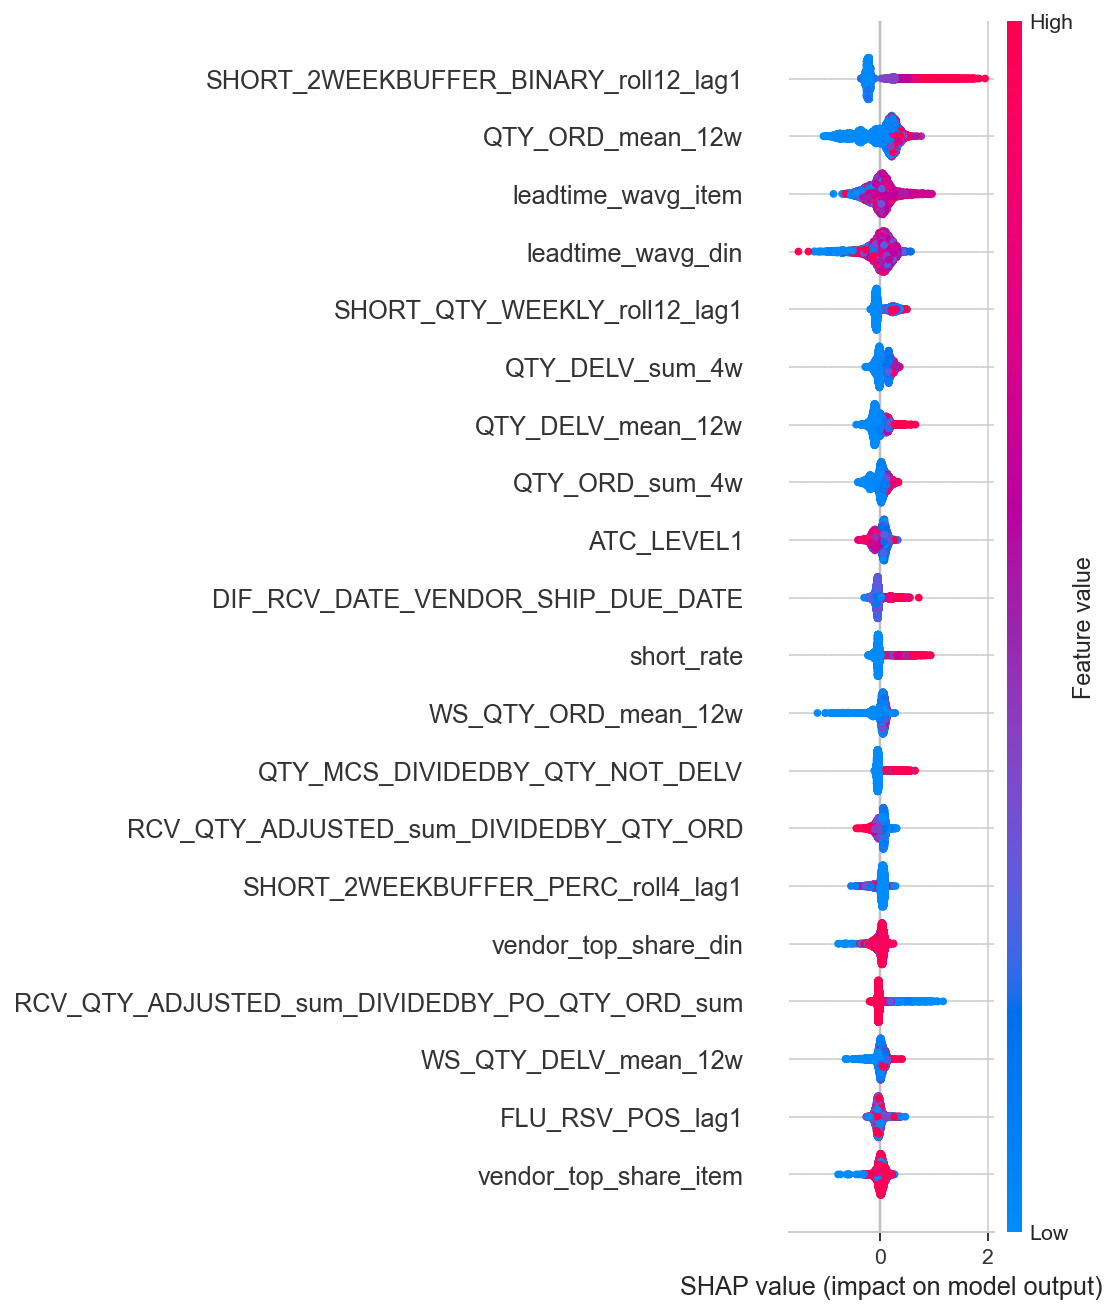

In [24]:
# ==============================================================================
# SECTION 9: MODEL SELECTION & INTERPRETABILITY
# ==============================================================================
logger = logging.getLogger(__name__)
logger.info("Executing Section 9 (Model Selection & Interpretability)...")

print("\n" + "=" * 80)
print("SECTION 9: MODEL SELECTION & INTERPRETABILITY")
print("=" * 80)

# ==============================================================================
# 9.1 Select Best Model (PR-AUC + Recall tie-break)
# ==============================================================================
if "tuning_results" not in globals() or not tuning_results:
    raise RuntimeError("tuning_results not found. Run Section 7 first.")
if "tuned_models" not in globals() or not tuned_models:
    raise RuntimeError("tuned_models not found. Run Section 7 first.")

# Primary selection by PR-AUC
best_model_type = max(tuning_results, key=lambda k: tuning_results[k]["best_score"])
best_pr_auc = tuning_results[best_model_type]["best_score"]

# Load Section 8 thresholds
threshold_dir = Config.OUTPUT_DIR / "models" / "baselines"

def load_threshold_result(model_type: str):
    path = threshold_dir / f"{model_type}_threshold_results.json"
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

threshold_results = {mt: load_threshold_result(mt) for mt in tuned_models.keys()}

def get_f1_recall_thr(model_type: str):
    r = threshold_results.get(model_type)
    if not r or "f1" not in r:
        return None, None, None
    return r["f1"]["f1"], r["f1"]["recall"], r["f1"]["threshold"]

best_f1, best_recall, best_thr = get_f1_recall_thr(best_model_type)

# Tie-break: if F1 diff <= 0.05, choose higher Recall
if best_f1 is not None:
    for mt in tuned_models.keys():
        if mt == best_model_type:
            continue
        f1, recall, thr = get_f1_recall_thr(mt)
        if f1 is None:
            continue
        if abs(f1 - best_f1) <= 0.05 and recall > best_recall:
            best_model_type = mt
            best_f1, best_recall, best_thr = f1, recall, thr

best_model = tuned_models[best_model_type]
best_pr_auc = tuning_results[best_model_type]["best_score"]

print(f"\n[Model Selection] Best model: {best_model_type.upper()}")
print(f"[Model Selection] PR-AUC = {best_pr_auc:.4f}")

# ==============================================================================
# 9.2 Prepare Validation Data
# ==============================================================================
X_train = prepared_data["X_train"]
y_train = prepared_data["y_train"]
X_val = prepared_data["X_val"]
y_val = prepared_data["y_val"]
categorical_cols = prepared_data["categorical_cols"]

if "encoder" not in globals():
    encoder = FeatureEncoder()
    encoder.fit(X_train, categorical_cols)

X_val_encoded = encoder.transform(X_val, categorical_cols)

X_val_cb = X_val.copy()
for col in categorical_cols:
    if col in X_val_cb.columns:
        X_val_cb[col] = X_val_cb[col].astype(str).fillna("UNKNOWN")

if best_model_type == "catboost":
    X_eval = X_val_cb
else:
    X_eval = X_val_encoded

# ==============================================================================
# 9.3 Threshold (use Section 8 result)
# ==============================================================================
print("\n[Threshold Tuning] Using Section 8 result (F1 strategy)...")

if best_thr is None:
    # fallback if Section 8 missing
    y_prob = best_model.predict_proba(X_eval)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)
    best_f1_tmp = -1
    best_thr = 0.5
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        if f1 > best_f1_tmp:
            best_f1_tmp, best_thr = f1, t

y_prob = best_model.predict_proba(X_eval)[:, 1]
y_pred = (y_prob >= best_thr).astype(int)

precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)

print(f"  Best threshold (F1): {best_thr:.4f}")
print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

tn, fp, fn, tp = confusion_matrix(y_val, y_pred, labels=[0, 1]).ravel()
print(f"  Confusion: TP={tp} FP={fp} FN={fn} TN={tn}")

# ==============================================================================
# 9.4 Feature Importance (Model-native)
# ==============================================================================
print("\n[Feature Importance] Top 20 Features")
feature_names = X_eval.columns

if hasattr(best_model, "feature_importances_"):
    imp = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)
    print(imp.head(20).to_string(index=False))
elif best_model_type == "catboost":
    imp = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.get_feature_importance()
    }).sort_values("importance", ascending=False)
    print(imp.head(20).to_string(index=False))
else:
    print("  (No native feature importance available for this model type)")

# ==============================================================================
# 9.5 SHAP (Optional)
# ==============================================================================
print("\n[SHAP] Global explanation (optional)...")

try:
    import shap
    sample = X_eval.sample(n=min(5000, len(X_eval)), random_state=42)

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(sample)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, sample, show=False, max_display=20)
    plt.tight_layout()
    out_path = Config.OUTPUT_DIR / "section9_shap_summary.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"  ✓ SHAP summary saved: {out_path}")
except Exception as e:
    print(f"  SHAP skipped: {str(e)[:80]}")

# ==============================================================================
# 9.6 Final Summary + Export to globals
# ==============================================================================
print("\n" + "=" * 80)
print("SECTION 9 SUMMARY")
print("=" * 80)
print(f"Final Model:       {best_model_type.upper()}")
print(f"PR-AUC (Section7): {best_pr_auc:.4f}")
print(f"Threshold (F1):    {best_thr:.4f}")
print(f"Precision/Recall:  {precision:.4f} / {recall:.4f}")
print("=" * 80)

globals()["FINAL_MODEL_NAME"] = best_model_type
globals()["FINAL_THRESHOLD"] = float(best_thr)

In [26]:
# ==============================================================================
# SECTION 10: DASHBOARD PIPELINE (MySQL) - FINAL (ITEM + MOLECULE)
# ==============================================================================
logger = logging.getLogger(__name__)
logger.info("Executing Section 10 (Dashboard Pipeline)...")

print("\n" + "=" * 80)
print("SECTION 10: DASHBOARD PIPELINE")
print("=" * 80)

# ==============================================================================
# 1) CONFIG
# ==============================================================================
DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_USER = "root"
DB_PASSWORD = "chenyuyang1"
DB_NAME = "drugshortage"

MODEL_NAME = None                 # None -> use FINAL_MODEL_NAME from Section 9
TARGET_COL = "label_4w"
THRESHOLD = None                  # None -> use FINAL_THRESHOLD from Section 9

DISPLAY_RULE = "predicted"        # predicted | actual | all

# Risk bucket (PowerBI x-axis)
RISK_BUCKET_LOW = 0.33
RISK_BUCKET_MED = 0.66

ENABLE_REASONS = True
REASON_TOPK = 3
REASON_SCOPE = "predicted_only"   # predicted_only | all
REASON_WEEK_MODE = "last_n_weeks" # latest_only | all_new | last_n_weeks
REASON_LAST_N = 4
REASON_MAX_ROWS = 2000

HISTORY_WEEKS = 52                # Keep last 52 weeks only

print(f"Using model: {MODEL_NAME if MODEL_NAME else 'AUTO (Section9)'}")
print(f"Target label: {TARGET_COL}")
print(f"Threshold: {THRESHOLD if THRESHOLD is not None else 'AUTO (Section9)'}")
print(f"Display rule: {DISPLAY_RULE}")
print(f"Risk buckets: low<{RISK_BUCKET_LOW}, medium<{RISK_BUCKET_MED}, high>=medium")
print(f"Reasons enabled: {ENABLE_REASONS} | TopK: {REASON_TOPK} | Scope: {REASON_SCOPE}")
print(f"Reason mode: {REASON_WEEK_MODE} (last_n={REASON_LAST_N})")
print(f"History window: last {HISTORY_WEEKS} weeks")
print("=" * 80)

# ==============================================================================
# 2) SAFETY CHECKS
# ==============================================================================
required_globals = ["df_panel", "tuned_models", "tuning_results", "encoder", "categorical_cols", "X_train"]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(f"Missing required globals: {missing}")

df_panel = df_panel.copy()
df_panel["date_monday"] = pd.to_datetime(df_panel["date_monday"], errors="coerce")

# prefer df_item_scope for dimensions if exists
if "df_item_scope" in globals() and df_item_scope is not None and not df_item_scope.empty:
    df_item_dim = df_item_scope.copy()
else:
    df_item_dim = df_panel.copy()

# ==============================================================================
# 3) MYSQL ENGINE
# ==============================================================================
db_pass = quote_plus(DB_PASSWORD)
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{db_pass}@{DB_HOST}:{DB_PORT}/{DB_NAME}?charset=utf8mb4"
)
print("[INFO] MySQL engine created.")

# ==============================================================================
# 4) ENSURE TABLES + AUTO MIGRATION
# ==============================================================================
def ensure_columns(conn, table, col_defs):
    existing = conn.execute(text("""
        SELECT COLUMN_NAME
        FROM INFORMATION_SCHEMA.COLUMNS
        WHERE TABLE_SCHEMA = :db AND TABLE_NAME = :tbl
    """), {"db": DB_NAME, "tbl": table}).fetchall()
    existing_cols = {r[0] for r in existing}

    for col, ddl in col_defs:
        if col not in existing_cols:
            conn.execute(text(f"ALTER TABLE {table} ADD COLUMN {ddl}"))
            print(f"[INFO] Added column {col} to {table}")

def ensure_tables():
    with engine.begin() as conn:
        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS model_registry (
            model_id VARCHAR(64) PRIMARY KEY
        )"""))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS run_registry (
            run_id VARCHAR(64) PRIMARY KEY
        )"""))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS dim_time (
            date_monday DATE PRIMARY KEY,
            year INT,
            month INT,
            week INT,
            quarter INT,
            yearweek INT
        )"""))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS dim_molecule (
            FINAL_MOLECULE VARCHAR(255) PRIMARY KEY,
            ATC_LEVEL1 VARCHAR(8),
            ATC_LEVEL3 VARCHAR(16)
        )"""))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS dim_item (
            ITEM_NUM_CLEAN BIGINT PRIMARY KEY,
            DIN_KEY CHAR(8),
            FINAL_MOLECULE VARCHAR(255),
            ATC_LEVEL1 VARCHAR(8),
            ATC_LEVEL3 VARCHAR(16),
            item_class_group VARCHAR(64),
            EN_FORM VARCHAR(64),
            ITEM_EN_DESC VARCHAR(255),
            SHORT_EN_DESC VARCHAR(255)
        )"""))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS fact_risk_score (
            run_id VARCHAR(64),
            model_id VARCHAR(64),
            ITEM_NUM_CLEAN BIGINT,
            FINAL_MOLECULE VARCHAR(255),
            date_monday DATE,
            risk_score FLOAT,
            risk_bucket VARCHAR(16),
            risk_score_display FLOAT,
            predicted_shortage TINYINT,
            actual_shortage TINYINT,
            actual_available TINYINT,
            PRIMARY KEY (run_id, ITEM_NUM_CLEAN, date_monday)
        )"""))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS fact_risk_reason (
            run_id VARCHAR(64),
            ITEM_NUM_CLEAN BIGINT,
            FINAL_MOLECULE VARCHAR(255),
            date_monday DATE,
            rank_ INT,
            feature_name VARCHAR(128),
            contribution FLOAT,
            feature_value FLOAT,
            PRIMARY KEY (run_id, ITEM_NUM_CLEAN, date_monday, rank_)
        )"""))

        ensure_columns(conn, "model_registry", [
            ("model_name", "model_name VARCHAR(64)"),
            ("pr_auc", "pr_auc FLOAT"),
            ("created_at", "created_at DATETIME"),
            ("notes", "notes VARCHAR(255)")
        ])

        ensure_columns(conn, "run_registry", [
            ("model_id", "model_id VARCHAR(64)"),
            ("target_col", "target_col VARCHAR(32)"),
            ("threshold", "threshold FLOAT"),
            ("display_rule", "display_rule VARCHAR(32)"),
            ("run_ts", "run_ts DATETIME"),
            ("data_start", "data_start DATE"),
            ("data_end", "data_end DATE"),
            ("n_rows", "n_rows INT"),
            ("is_incremental", "is_incremental TINYINT")
        ])

        ensure_columns(conn, "dim_item", [
            ("ITEM_EN_DESC", "ITEM_EN_DESC VARCHAR(255)"),
            ("SHORT_EN_DESC", "SHORT_EN_DESC VARCHAR(255)")
        ])

ensure_tables()
print("[INFO] Tables ensured (created if missing).")

# ==============================================================================
# 5) INCREMENTAL EXPORT + HISTORY WINDOW
# ==============================================================================
with engine.begin() as conn:
    last_date = conn.execute(text("SELECT MAX(date_monday) FROM fact_risk_score")).scalar()

if last_date is None:
    is_incremental = 0
    print("[INFO] No existing risk data found. Running FULL export.")
    df_export = df_panel.copy()
else:
    is_incremental = 1
    print(f"[INFO] Last exported date: {last_date}")
    df_export = df_panel[df_panel["date_monday"] > pd.to_datetime(last_date)].copy()

if df_export.empty:
    print("[INFO] No new weeks to export. Exiting pipeline.")
    raise SystemExit

cutoff = df_export["date_monday"].max() - pd.Timedelta(weeks=HISTORY_WEEKS - 1)
df_export = df_export[df_export["date_monday"] >= cutoff].copy()
print(f"[INFO] Applied history window: >= {cutoff.date()} ({HISTORY_WEEKS} weeks)")
print(f"[INFO] Weeks to export: {df_export['date_monday'].nunique()}")

with engine.begin() as conn:
    conn.execute(text("DELETE FROM fact_risk_score WHERE date_monday < :cutoff"), {"cutoff": cutoff})
    conn.execute(text("DELETE FROM fact_risk_reason WHERE date_monday < :cutoff"), {"cutoff": cutoff})
print("[INFO] Old rows outside history window removed.")

# ==============================================================================
# 6) MODEL SELECTION (reuse Section 9 result)
# ==============================================================================
if "FINAL_MODEL_NAME" in globals():
    best_model_name = FINAL_MODEL_NAME
elif MODEL_NAME is None:
    best_model_name = max(tuning_results, key=lambda k: tuning_results[k]["best_score"])
else:
    best_model_name = MODEL_NAME

model = tuned_models[best_model_name]
pr_auc = tuning_results[best_model_name]["best_score"]
model_id = f"{best_model_name}_{pd.Timestamp.now():%Y%m%d_%H%M}"
run_id = str(uuid.uuid4())

print(f"[INFO] Selected model: {best_model_name} | PR-AUC={pr_auc:.4f}")
print(f"[INFO] model_id={model_id}, run_id={run_id}")

# Threshold from Section 9
if THRESHOLD is None and "FINAL_THRESHOLD" in globals():
    THRESHOLD = FINAL_THRESHOLD
elif THRESHOLD is None:
    THRESHOLD = 0.5
print(f"[INFO] Using threshold: {THRESHOLD:.4f}")

# ==============================================================================
# 7) DIMENSIONS 
# ==============================================================================
df_time = df_export[["date_monday"]].drop_duplicates().copy()
df_time["year"] = df_time["date_monday"].dt.year
df_time["month"] = df_time["date_monday"].dt.month
df_time["week"] = df_time["date_monday"].dt.isocalendar().week.astype(int)
df_time["quarter"] = df_time["date_monday"].dt.quarter
df_time["yearweek"] = df_time["date_monday"].dt.year * 100 + df_time["week"]
df_time.to_sql("dim_time", engine, if_exists="replace", index=False)
print(f"[INFO] dim_time saved. Rows: {len(df_time):,}")

# Molecule dimension
df_molecule = df_item_dim[["FINAL_MOLECULE", "ATC_LEVEL1", "ATC_LEVEL3"]].drop_duplicates()
df_molecule.to_sql("dim_molecule", engine, if_exists="replace", index=False)
print(f"[INFO] dim_molecule saved. Rows: {len(df_molecule):,}")

# Item dimension
item_cols = [
    "ITEM_NUM_CLEAN", "DIN_KEY", "FINAL_MOLECULE",
    "ATC_LEVEL1", "ATC_LEVEL3",
    "item_class_group", "EN_FORM",
    "ITEM_EN_DESC", "SHORT_EN_DESC"
]
item_cols = [c for c in item_cols if c in df_item_dim.columns]
df_item_dim_out = df_item_dim[item_cols].drop_duplicates("ITEM_NUM_CLEAN")
df_item_dim_out.to_sql("dim_item", engine, if_exists="replace", index=False)
print(f"[INFO] dim_item saved. Rows: {len(df_item_dim_out):,}")

# ==============================================================================
# 8) MODEL REGISTRY
# ==============================================================================
pd.DataFrame([{
    "model_id": model_id,
    "model_name": best_model_name,
    "pr_auc": float(pr_auc),
    "created_at": pd.Timestamp.now(),
    "notes": "Selected by PR-AUC + Recall tie-break"
}]).to_sql("model_registry", engine, if_exists="append", index=False)
print(f"[INFO] model_registry saved. model_id={model_id}, PR-AUC={pr_auc:.4f}")

# ==============================================================================
# 9) SCORE EXPORT
# ==============================================================================
feature_cols = list(X_train.columns)
for c in feature_cols:
    if c not in df_export.columns:
        df_export[c] = 0

X_all = df_export[feature_cols].copy()

t0 = time.time()
if best_model_name == "catboost":
    X_all_cb = X_all.copy()
    for c in categorical_cols:
        if c in X_all_cb.columns:
            X_all_cb[c] = X_all_cb[c].astype(str).fillna("UNKNOWN")
    y_prob = model.predict_proba(X_all_cb)[:, 1]
else:
    X_all_encoded = encoder.transform(X_all, categorical_cols)
    y_prob = model.predict_proba(X_all_encoded)[:, 1]
print(f"[INFO] scoring completed in {time.time()-t0:.1f}s")

df_score = df_export[["ITEM_NUM_CLEAN", "FINAL_MOLECULE", "date_monday"]].copy()
df_score["risk_score"] = y_prob

# risk bucket for PowerBI
df_score["risk_bucket"] = np.select(
    [
        df_score["risk_score"] < RISK_BUCKET_LOW,
        df_score["risk_score"] < RISK_BUCKET_MED
    ],
    ["LOW", "MEDIUM"],
    default="HIGH"
)

df_score["predicted_shortage"] = (df_score["risk_score"] >= THRESHOLD).astype(int)

# actual shortage: leave NULL when not available (latest weeks)
if TARGET_COL in df_export.columns:
    actual_raw = df_export[TARGET_COL]
    df_score["actual_shortage"] = actual_raw.astype("float")
    df_score["actual_available"] = actual_raw.notna().astype(int)
else:
    df_score["actual_shortage"] = np.nan
    df_score["actual_available"] = 0

if DISPLAY_RULE == "predicted":
    df_score["risk_score_display"] = np.where(df_score["predicted_shortage"] == 1, df_score["risk_score"], np.nan)
elif DISPLAY_RULE == "actual":
    df_score["risk_score_display"] = np.where(df_score["actual_shortage"] == 1, df_score["risk_score"], np.nan)
else:
    df_score["risk_score_display"] = df_score["risk_score"]

df_score["run_id"] = run_id
df_score["model_id"] = model_id

t0 = time.time()
df_score.to_sql(
    "fact_risk_score",
    engine,
    if_exists="append",
    index=False,
    chunksize=50000,
    method="multi"
)
print(f"[INFO] fact_risk_score appended. Rows: {len(df_score):,} | time={time.time()-t0:.1f}s")

# ==============================================================================
# 10) RUN REGISTRY
# ==============================================================================
pd.DataFrame([{
    "run_id": run_id,
    "model_id": model_id,
    "target_col": TARGET_COL,
    "threshold": THRESHOLD,
    "display_rule": DISPLAY_RULE,
    "run_ts": pd.Timestamp.now(),
    "data_start": df_export["date_monday"].min(),
    "data_end": df_export["date_monday"].max(),
    "n_rows": len(df_export),
    "is_incremental": is_incremental
}]).to_sql("run_registry", engine, if_exists="append", index=False)
print(f"[INFO] run_registry saved. run_id={run_id}")

# ==============================================================================
# 11) SHAP REASONS (RECENT WEEKS ONLY)
# ==============================================================================
if ENABLE_REASONS:
    try:
        import shap
        print("[INFO] SHAP available. Computing reasons...")

        if REASON_WEEK_MODE == "latest_only":
            reason_week = df_score["date_monday"].max()
            mask = df_score["date_monday"] == reason_week
        elif REASON_WEEK_MODE == "last_n_weeks":
            max_week = df_score["date_monday"].max()
            min_week = max_week - pd.Timedelta(weeks=REASON_LAST_N - 1)
            mask = (df_score["date_monday"] >= min_week) & (df_score["date_monday"] <= max_week)
        else:
            mask = df_score.index == df_score.index  # all rows

        if REASON_SCOPE == "predicted_only":
            mask &= (df_score["predicted_shortage"] == 1)

        idx = df_score[mask].index
        print(f"[INFO] Rows selected for SHAP: {len(idx):,}")

        if REASON_MAX_ROWS is not None and len(idx) > REASON_MAX_ROWS:
            idx = idx[:REASON_MAX_ROWS]
            print(f"[INFO] SHAP capped to {REASON_MAX_ROWS} rows.")

        if len(idx) > 0:
            if best_model_name == "catboost":
                X_explain = X_all_cb.iloc[idx]
                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(X_explain)
            else:
                X_explain = X_all_encoded.iloc[idx]
                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(X_explain)

            if isinstance(shap_values, list):
                shap_values = shap_values[1]

            reason_rows = []
            for i, row_idx in enumerate(idx):
                vals = shap_values[i]
                top_idx = np.argsort(np.abs(vals))[-REASON_TOPK:][::-1]
                for rank_pos, j in enumerate(top_idx, start=1):
                    try:
                        fv = float(X_all.iloc[row_idx, j])
                    except Exception:
                        fv = None
                    reason_rows.append({
                        "run_id": run_id,
                        "ITEM_NUM_CLEAN": df_score.loc[row_idx, "ITEM_NUM_CLEAN"],
                        "FINAL_MOLECULE": df_score.loc[row_idx, "FINAL_MOLECULE"],
                        "date_monday": df_score.loc[row_idx, "date_monday"],
                        "rank_": rank_pos,
                        "feature_name": feature_cols[j],
                        "contribution": float(vals[j]),
                        "feature_value": fv
                    })

            df_reason = pd.DataFrame(reason_rows)
            if not df_reason.empty:
                df_reason.to_sql(
                    "fact_risk_reason",
                    engine,
                    if_exists="append",
                    index=False,
                    chunksize=50000,
                    method="multi"
                )
                print(f"[INFO] fact_risk_reason appended. Rows: {len(df_reason):,}")
            else:
                print("[INFO] No SHAP reasons generated (empty selection).")
        else:
            print("[INFO] No rows selected for SHAP. Skipping.")
    except Exception as e:
        print(f"[WARN] SHAP failed: {e}")

print("=" * 80)
print("SECTION 10 COMPLETE")
print("=" * 80)
print(f"Model ID: {model_id}")
print(f"Run ID:   {run_id}")
print("Tables: dim_time, dim_molecule, dim_item, model_registry, run_registry, fact_risk_score, fact_risk_reason")

2026-02-20 03:06:18,410 - [INFO] - Executing Section 10 (Dashboard Pipeline)...

SECTION 10: DASHBOARD PIPELINE
Using model: AUTO (Section9)
Target label: label_4w
Threshold: AUTO (Section9)
Display rule: predicted
Risk buckets: low<0.33, medium<0.66, high>=medium
Reasons enabled: True | TopK: 3 | Scope: predicted_only
Reason mode: last_n_weeks (last_n=4)
History window: last 52 weeks
[INFO] MySQL engine created.
[INFO] Added column model_name to model_registry
[INFO] Added column pr_auc to model_registry
[INFO] Added column created_at to model_registry
[INFO] Added column notes to model_registry
[INFO] Added column model_id to run_registry
[INFO] Added column target_col to run_registry
[INFO] Added column threshold to run_registry
[INFO] Added column display_rule to run_registry
[INFO] Added column run_ts to run_registry
[INFO] Added column data_start to run_registry
[INFO] Added column data_end to run_registry
[INFO] Added column n_rows to run_registry
[INFO] Added column is_incremen